# 可调耦合器仿真计算（标准化流程）
可调耦合器仿真计算标准化流程如下：
1. 设计所需可调耦合器初始版图（如需要，将JSON设计参数文件导入）
2. 利用HFSS Q3D仿真出电容矩阵并将其导出为csv文件，同时保存设计参数为JSON文件
3. 利用quasi-lump方法消去多余节点，计算谐振腔与比特，谐振腔与可调耦合器的耦合强度
4. 计算可调耦合器与比特的频率以及非谐量（如果频率和非谐不符合预期，则返回1修改参数）
5. 通过全哈密顿量方法（固定ng）计算系统能级
6. 改变磁通，计算g1，g2，g12以及有效耦合强度随磁通和频率的改变并绘制变化图
7. 计算zz耦合随磁通和频率的改变并绘制变化图

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import qiskit_metal as metal
from qiskit_metal import designs
from qiskit_metal import MetalGUI, Dict
# import pyEPR as epr
import math
# from qiskit_metal.qlibrary.qubits.transmon_cross_fl import TransmonCrossFL
# from qiskit_metal.qlibrary.couplers.tunable_coupler_01 import TunableCoupler01
# from qiskit_metal.qlibrary.couplers.tunable_coupler_02 import TunableCoupler02
from qiskit_metal.qlibrary.user_components.my_qcomponent import *
from qiskit_metal.qlibrary.user_components.hfss_simulation import *
from qiskit_metal.qlibrary.couplers.tunable_coupler_01 import TunableCoupler01
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.user_components.save_load import *
from qiskit_metal.qlibrary.user_components.writer import *
from qiskit_metal.qlibrary.user_components.reader import *
from qiskit_metal.analyses.quantization.lumped_capacitive import load_q3d_capacitance_matrix
from qiskit_metal.analyses.quantization.lom_core_analysis import CompositeSystem, Cell, Subsystem, QuantumSystemRegistry
from qiskit_metal.qlibrary.user_components.layout import two_qubit_layout
from qiskit_metal.qlibrary.user_components.hfss_autosimulation import hfss_grad
from scqubits import HilbertSpace,ParameterSweep
from scipy.constants import speed_of_light as c_light
from IPython.display import display
import numpy as np
import pandas as pd
# import orjson 

03:48PM 56s INFO [__init__]: TransmonBuilder with system_type TRANSMON registered to QuantumSystemRegistry
03:48PM 56s INFO [__init__]: TunableTransmonBuilder with system_type TunableTRANSMON registered to QuantumSystemRegistry
03:48PM 56s INFO [__init__]: FluxoniumBuilder with system_type FLUXONIUM registered to QuantumSystemRegistry
03:48PM 56s INFO [__init__]: TLResonatorBuilder with system_type TL_RESONATOR registered to QuantumSystemRegistry
03:48PM 56s INFO [__init__]: LumpedResonatorBuilder with system_type LUMPED_RESONATOR registered to QuantumSystemRegistry


In [22]:
def calculate_qubit_resonator_coupling(
    ta_mat, qubit1, qubit2, coupler, ground, connector,
    ind_qubit1, ind_qubit2, ind_coupler,
    f_res=7.3,
    cj_qubit1=0.0, cj_qubit2=0.0, cj_coupler=0.0,
    evals_count=30,
):
    """
    2.2 耦合强度计算: 计算比特-谐振腔耦合强度 g

    Parameters
    ----------
    ta_mat : DataFrame
        Q3D 仿真得到的电容矩阵
    qubit1, qubit2, coupler : str
        比特1、比特2、耦合器节点名称
    ground : str
        接地节点名称 (将被重命名为 'ground_main_plane')
    connector : str
        谐振腔连接节点名称 (将被重命名为 'readout_alice')
    ind_qubit1, ind_qubit2, ind_coupler : float
        结电感 (nH)
    f_res : float
        谐振腔频率 (GHz), 默认 7.3
    cj_qubit1, cj_qubit2, cj_coupler : float
        结电容 (fF), 默认 0.0
    evals_count : int
        计算的本征值数量

    Returns
    -------
    dict : 包含 'g_MHz', 'hamiltonian_results', 'cg', 'composite_sys',
           'hilbertspace', 'chi_df'
    """
    opt = dict(
        node_rename={connector: 'readout_alice', ground: 'ground_main_plane'},
        cap_mat=ta_mat,
        ind_dict={
            (qubit1, 'ground_main_plane'): ind_qubit1,
            (qubit2, 'ground_main_plane'): ind_qubit2,
            (coupler, 'ground_main_plane'): ind_coupler,
        },
        jj_dict={
            (qubit1, 'ground_main_plane'): 'jj1',
            (qubit2, 'ground_main_plane'): 'jj2',
            (coupler, 'ground_main_plane'): 'jjc',
        },
        cj_dict={
            (qubit1, 'ground_main_plane'): cj_qubit1,
            (qubit2, 'ground_main_plane'): cj_qubit2,
            (coupler, 'ground_main_plane'): cj_coupler,
        },
    )
    cell = Cell(opt)

    transmon = Subsystem(name='transmon_alice', sys_type='TRANSMON', nodes=['jj1'])

    q_opts_res = dict(f_res=f_res, Z0=50, vp=0.404314 * c_light)
    resonator = Subsystem(
        name='readout_alice', sys_type='TL_RESONATOR',
        nodes=['readout_alice'], q_opts=q_opts_res,
    )

    comp_sys = CompositeSystem(
        subsystems=[transmon, resonator],
        cells=[cell],
        grd_node='ground_main_plane',
        nodes_force_keep=['readout_alice'],
    )

    cg = comp_sys.circuitGraph()
    print(cg)

    hs = comp_sys.create_hilbertspace()
    print(hs)
    hs = comp_sys.add_interaction()

    ham_results = comp_sys.hamiltonian_results(hs, evals_count=evals_count)

    f1_hz = ham_results['fQ_in_Ghz']['transmon_alice'] * 1e9
    f2_hz = ham_results['fQ_in_Ghz']['readout_alice'] * 1e9
    C = 1 / (8 * f2_hz * 50)
    g = -cg.C_k[0][1] * math.sqrt(f1_hz * f2_hz / (cg.C_k[0][0] * C * 1e15)) / 2 * 1e-6

    print(f"g = {g} MHz")
    chi_df = ham_results['chi_in_MHz'].to_dataframe()
    # display(chi_df)

    return dict(
        g_MHz=g,
        hamiltonian_results=ham_results,
        cg=cg,
        composite_sys=comp_sys,
        hilbertspace=hs,
        chi_df=chi_df,
    )


def full_hamiltonian_analysis(
    ta_mat, qubit1, qubit2, coupler, ground,
    ind_qubit1, ind_qubit2, ind_coupler,
    flux_vals=None,
    q_opts_alice=None,
    q_opts_bob=None,
    q_opts_charlie=None,
    cj_qubit1=0.0, cj_qubit2=0.0, cj_coupler=0.0,
    evals_count=30,
    num_cpus=10,
    run_sweep=True,
    run_geff=True,
):
    """
    3. 全哈密顿量量子化计算
    包含频率和非谐量计算 (3.1)、能级图绘制 (3.2)、zz耦合和有效耦合计算 (3.2)

    Parameters
    ----------
    ta_mat : DataFrame
        Q3D 仿真得到的电容矩阵
    qubit1, qubit2, coupler, ground : str
        节点名称
    ind_qubit1, ind_qubit2, ind_coupler : float
        结电感 (nH)
    flux_vals : array-like, optional
        磁通扫描值, 默认 np.linspace(0, 1.0, 1001)
    q_opts_alice : dict, optional
        transmon_alice 量子系统参数
    q_opts_bob : dict, optional
        transmon_bob (coupler) 量子系统参数
    q_opts_charlie : dict, optional
        transmon_charlie 量子系统参数
    cj_qubit1, cj_qubit2, cj_coupler : float
        结电容 (fF)
    evals_count : int
        本征值数量
    num_cpus : int
        并行计算 CPU 数
    run_sweep : bool
        是否运行 ParameterSweep (能级图)
    run_geff : bool
        是否计算有效耦合和 ZZ 耦合

    Returns
    -------
    dict : 包含 'hilbertspace', 'hamiltonian_results', 'cg', 'composite_sys',
           'cell', 'transmon_alice', 'transmon_bob', 'transmon_charlie',
           'f_a', 'f_b', 'f_c', 'chi_df', 'flux_vals',
           'sweep' (if run_sweep), 'g_list', 'fc_list' (if run_geff)
    """
    if flux_vals is None:
        flux_vals = np.linspace(0, 1.0, 1001)

    if q_opts_alice is None:
        q_opts_alice = dict(ng=0, ncut=10, truncated_dim=6)
    if q_opts_bob is None:
        q_opts_bob = dict(flux=0, d=0, ng=0, ncut=10, truncated_dim=4)
    if q_opts_charlie is None:
        q_opts_charlie = dict(ng=0, ncut=10, truncated_dim=6)

    # ---- 3.1 频率和非谐量 ----
    opt = dict(
        node_rename={ground: 'ground_main_plane'},
        cap_mat=ta_mat,
        ind_dict={
            (qubit1, 'ground_main_plane'): ind_qubit1,
            (qubit2, 'ground_main_plane'): ind_qubit2,
            (coupler, 'ground_main_plane'): ind_coupler,
        },
        jj_dict={
            (qubit1, 'ground_main_plane'): 'jj1',
            (qubit2, 'ground_main_plane'): 'jj2',
            (coupler, 'ground_main_plane'): 'jjc',
        },
        cj_dict={
            (qubit1, 'ground_main_plane'): cj_qubit1,
            (qubit2, 'ground_main_plane'): cj_qubit2,
            (coupler, 'ground_main_plane'): cj_coupler,
        },
    )
    cell = Cell(opt)

    transmon_alice = Subsystem(
        name='transmon_alice', sys_type='TRANSMON',
        nodes=['jj1'], q_opts=q_opts_alice,
    )
    transmon_bob = Subsystem(
        name='transmon_bob', sys_type='TunableTRANSMON',
        nodes=['jjc'], q_opts=q_opts_bob,
    )
    transmon_charlie = Subsystem(
        name='transmon_charlie', sys_type='TRANSMON',
        nodes=['jj2'], q_opts=q_opts_charlie,
    )

    comp_sys = CompositeSystem(
        subsystems=[transmon_alice, transmon_bob, transmon_charlie],
        cells=[cell],
        grd_node='ground_main_plane',
    )

    cg = comp_sys.circuitGraph()
    hs = comp_sys.create_hilbertspace()
    print(cg, hs)

    hs = comp_sys.add_interaction()
    hs.hamiltonian()

    ham_results = comp_sys.hamiltonian_results(hs, evals_count=evals_count)
    chi_df = ham_results['chi_in_MHz'].to_dataframe()

    f_a = round(ham_results['fQ_in_Ghz']['transmon_alice'], 2)
    f_c = round(ham_results['fQ_in_Ghz']['transmon_bob'], 2)
    f_b = round(ham_results['fQ_in_Ghz']['transmon_charlie'], 2)

    print(f"f_alice = {f_a} GHz, f_bob(coupler) = {f_c} GHz, f_charlie = {f_b} GHz")
    # display(chi_df)

    result = dict(
        hilbertspace=hs,
        hamiltonian_results=ham_results,
        cg=cg,
        composite_sys=comp_sys,
        cell=cell,
        transmon_alice=transmon_alice,
        transmon_bob=transmon_bob,
        transmon_charlie=transmon_charlie,
        f_a=f_a, f_b=f_b, f_c=f_c,
        chi_df=chi_df,
        flux_vals=flux_vals,
    )

    # ---- 3.2 能级图 (ParameterSweep) ----
    if run_sweep:
        pname = 'flux'
        paramvals_by_name = {pname: flux_vals}

        def update_hilbertspace(param_sweep, flux):
            param_sweep.hilbertspace[1].flux = flux

        subsys_update_info = {pname: [transmon_bob.quantum_system]}

        sweep = ParameterSweep(
            hilbertspace=hs,
            paramvals_by_name=paramvals_by_name,
            update_hilbertspace=update_hilbertspace,
            evals_count=10,
            subsys_update_info=subsys_update_info,
            num_cpus=num_cpus,
            deepcopy=True,
        )
        result['sweep'] = sweep

    # ---- 3.2 ZZ 耦合和有效耦合 ----
    if run_geff:
        sub1_dim = hs.subsystem_dims[0]
        sub2_dim = hs.subsystem_dims[1]
        total_dim = sub1_dim * sub2_dim
        g_list = []
        fc_list = []
        f1 = ham_results['fQ_in_Ghz']['transmon_alice']
        f2 = ham_results['fQ_in_Ghz']['transmon_charlie']

        for param_val in flux_vals:
            q_bob = dict(
                flux=param_val,
                d=q_opts_bob.get('d', 0),
                ng=q_opts_bob.get('ng', 0),
                ncut=q_opts_bob.get('ncut', 10),
                truncated_dim=q_opts_bob.get('truncated_dim', 4),
            )
            tunable_bob = Subsystem(
                name='tunabletransmon_bob', sys_type='TunableTRANSMON',
                nodes=['jjc'], q_opts=q_bob,
            )
            coupler_sys = CompositeSystem(
                subsystems=[transmon_alice, tunable_bob, transmon_charlie],
                cells=[cell],
                grd_node='ground_main_plane',
            )
            coupler_hs = coupler_sys.add_interaction()
            H = coupler_hs.hamiltonian()
            g1 = np.abs(np.real(H[total_dim][0][sub1_dim]))
            g2 = np.abs(np.real(H[sub1_dim][0][1]))
            g12 = np.abs(np.real(H[total_dim][0][1]))
            coupler_ham = coupler_sys.hamiltonian_results(coupler_hs, evals_count=evals_count)
            fc = coupler_ham['fQ_in_Ghz']['tunabletransmon_bob']
            delta1 = f1 - fc
            delta2 = f2 - fc
            sigma1 = f1 + fc
            sigma2 = f2 + fc
            g_eff = g12 + (g1 * g2 * (1/delta1 + 1/delta2 - 1/sigma1 - 1/sigma2) / 2) * 1e-3
            g_list.append(g_eff)
            fc_list.append(fc)

        result['g_list'] = g_list
        result['fc_list'] = fc_list

    return result

## 1.仿真版图设计
设计可调耦合器双比特仿真版图。
### 1.1 初始化版图设计
设计双比特分版图并对其几何参数进行初始化

In [3]:
jj_dict = {'xmon_round1':'FakeJunction_01','xmon_round2':'FakeJunction_01','xmon_round3':'FakeJunction_01_r','xmon_round4':'FakeJunction_01_r',
           'tunable_coupler1':'FakeJunction_02_r','tunable_coupler2':'FakeJunction_02',}  
design,gui= two_qubit_layout(jj_dict)

 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\shiboken2\files.dir\shibokensupport\feature.py: 139
08:50AM 10s WARNING [check_lengths]: For path table, component=z1_part2, key=trace has short segments that could cause issues with fillet. Values in (2-3)  are index(es) in shapely geometry.
08:50AM 10s WARNING [check_lengths]: For path table, component=z1_part2, key=cut has short segments that could cause issues with fillet. Values in (2-3)  are index(es) in shapely geometry.


In [43]:
# parameter_file_path = f'data/20qubit/tunable_coupler_v101.json'
jj_dict=None
parameter_file_path = f'data/20qubit/20bits_coupler_V2.01_fixed.json'
design,gui = twenty_qubits_tunable_coupler_layout_v1(parameter_file_path=parameter_file_path,jj_dict=jj_dict,airbridege=True,version='0.00')
# design,gui = twenty_qubits_tunable_coupler_layout_v1(parameter_file_path=parameter_file_path,jj_dict=jj_dict,airbridege=True,version='1.00')

 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\shiboken2\files.dir\shibokensupport\feature.py: 139


In [16]:
import json

def change_dict_keys(data):
    """
    递归遍历JSON数据，删除所有以'xmon'开头的键中的pos_x和pos_y
    """
    if isinstance(data, dict):
        for key in list(data.keys()):
            if key.startswith('xmon') and isinstance(data[key], dict):
                data[key].pop('pos_x', None)
                data[key].pop('pos_y', None)
                # print(key)
                if key !='xmon_round5' and key !='xmon_round10' and key !='xmon_round15':
                    data[key]['connection_pads']['bus_02']['claw_length']='145um'
                    data[key]['cross_length']='150um'
            if key.startswith('tunable_coupler') and isinstance(data[key], dict):
                data[key].pop('pos_x', None)
                data[key].pop('pos_y', None)
                # if key !='tunable_coupler4' and key !='tunable_coupler9' and key !='tunable_coupler14':
                #     data[key]['c_height']='80um'                   
 
    return data

# 从文件读取JSON
def process_json_file(input_file, output_file):
    """
    从文件读取JSON，处理后写入新文件
    """
    # 读取JSON文件
    with open(input_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # 处理数据
    processed_data = change_dict_keys(data)
    
    # 写入处理后的JSON到新文件
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(processed_data, f, indent=2, ensure_ascii=False)
    
    print(f"处理完成，结果已保存到 {output_file}")

In [17]:
input_path = f'data/20qubit/20bits_coupler_V2.01.json'
output_file_path = f'data/20qubit/20bits_coupler_V2.01_fixed.json'
process_json_file(input_path,output_file_path)

处理完成，结果已保存到 data/20qubit/20bits_coupler_V2.01_fixed.json


### 1.2 导入设计参数文件（可选）
如果需要查看或者修改之前仿真的参数，将保存的JSON设计参数文件导入版图中

In [4]:
parameter_import(design,convert_keys_to_int(load_json( f'data/tunable_coupler_option{500}.json')))
# parameter_import(design,load_json( f'data/tunable_coupler_option{451}.json'))
gui.rebuild()
gui.autoscale()

In [5]:
jj_path = './resources/Fake_Junctions.GDS'
cheese_view = {1: False, 2: False, 3: False, 4: False, }
#设置输出文件选项
a_gds = writer_planar(design,jj_path,negative_mask=[1,2,3],cheese_view=cheese_view)
a_gds.export_to_gds('20_tunable_coupler_v3.gds')

09:09AM 20s WARNING [_qgeometry_to_gds]: Unexpected shapely object geometry.The variable qgeometry_element is <class 'numpy.float64'>, method can currently handle Polygon and FlexPath.
09:09AM 20s WARNING [_qgeometry_to_gds]: Unexpected shapely object geometry.The variable qgeometry_element is <class 'numpy.float64'>, method can currently handle Polygon and FlexPath.
09:09AM 21s WARNING [_add_negative_extension_to_jj]: From the "junction" table, the cell named "my_other_junction",  is not in file: ./resources/Fake_Junctions.GDS. The cell was not used.
09:09AM 21s WARNING [_add_negative_extension_to_jj]: From the "junction" table, the cell named "my_other_junction",  is not in file: ./resources/Fake_Junctions.GDS. The cell was not used.
09:09AM 21s WARNING [_add_negative_extension_to_jj]: From the "junction" table, the cell named "my_other_junction",  is not in file: ./resources/Fake_Junctions.GDS. The cell was not used.
09:09AM 21s WARNING [_add_negative_extension_to_jj]: From the "jun

1

## 2.电磁仿真和耦合强度计算

### 2.1 电容矩阵仿真
利用HFSS Q3D仿真得到比特和可调耦合器组成的电容矩阵，将电容矩阵保存为csv文件，同时保存设计参数为JSON文件

In [44]:
name='q3d_20tunable_coupler_test'
# render_comp = []
render_comp = ['xmon_round1','xmon_round2','tunable_coupler1',]
# render_comp = ['xmon_round3','xmon_round4','tunable_coupler2',]
c1 = q3d_simulation(design,render_qcomps=render_comp,name=name)

INFO 11:52AM [connect_project]: Connecting to Ansys Desktop API...
INFO 11:52AM [load_ansys_project]: 	Opened Ansys App
INFO 11:52AM [load_ansys_project]: 	Opened Ansys Desktop v2022.1.0
INFO 11:52AM [load_ansys_project]: 	Opened Ansys Project
	Folder:    E:/Users/ls/Documents/Ansoft/
	Project:   Project50
INFO 11:52AM [connect_design]: No active design found (or error getting active design).
INFO 11:52AM [connect]: 	 Connected to project "Project50". No design detected
INFO 11:52AM [connect_design]: 	Opened active design
	Design:    q3d_20tunable_coupler_test_q3d [Solution type: Q3D]
WARNING 11:52AM [connect_setup]: 	No design setup detected.
WARNING 11:52AM [connect_setup]: 	Creating Q3D default setup.
INFO 11:52AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 11:52AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 11:52AM [analyze]: Analyzing setup Setup


com_error: (-2147352567, '发生意外。', (0, None, None, None, 0, -2147024349), None)

In [5]:
import os

test_num = 201
folder_name = 'data/20qubit'
components_list= ['xmon_round1','xmon_round2','xmon_round3','xmon_round4','tunable_coupler1','tunable_coupler2',
                  'meander1','meander2','meander3','meander4','meander5','meander6',
                  'TQ1','TQ2','TQ3','TQ4','TQ5','TQ6']
# Check if the folder exists
if not os.path.exists(folder_name):
    # Create the folder if it does not exist
    os.makedirs(folder_name)
    print(f"Folder '{folder_name}' created.")    

cm = c1.sim.capacitance_matrix
path_cm = f'data/20qubit/tunable_coupler_capacitance_matrix{test_num}.csv'
path_json = f'data/20qubit/tunable_coupler_option{test_num}.json'
# 
cm.to_csv(path_cm, index=True)                                                                         
print(f"tunable_coupler_capacitance_matrix{test_num}.csv created.")

# 
# save_json(design,path_json,component_id_list=components_list)
# print(f"tunable_coupler_options{test_num}.json created.")
cm


tunable_coupler_capacitance_matrix201.csv created.


,bus_01_connector_arm_xmon_round1,bus_02_connector_arm_xmon_round1,bus_02_connector_arm_xmon_round2,coupler_tunable_coupler1,cross_xmon_round1,cross_xmon_round2
bus_01_connector_arm_xmon_round1,394.60402,-69.34990,-69.35300,-47.96281,-74.77637,-74.77463
bus_02_connector_arm_xmon_round1,-69.34990,75.18115,-0.02445,-0.10572,-5.26474,-0.07201
bus_02_connector_arm_xmon_round2,-69.35300,-0.02445,75.18373,-0.10569,-0.07205,-5.26494
coupler_tunable_coupler1,-47.96281,-0.10572,-0.10569,55.13521,-3.18913,-3.18932
cross_xmon_round1,-74.77637,-5.26474,-0.07205,-3.18913,84.72736,-0.25801
cross_xmon_round2,-74.77463,-0.07201,-5.26494,-3.18932,-0.25801,84.72557


In [35]:
# path_cm = f'data/tunable_coupler_capacitance_matrix{501}.csv'
path_cm = f'data/20qubit/tunable_coupler_capacitance_matrix{201}_c36.csv'
ta_mat = pd.read_csv(path_cm, index_col=0)
ta_mat

,bus_01_connector_arm_xmon_round1,bus_02_connector_arm_xmon_round1,bus_02_connector_arm_xmon_round2,coupler_tunable_coupler1,cross_xmon_round1,cross_xmon_round2
bus_01_connector_arm_xmon_round1,394.60402,-69.34990,-69.35300,-47.96281,-74.77637,-74.77463
bus_02_connector_arm_xmon_round1,-69.34990,75.18115,-0.02445,-0.10572,-5.26474,-0.07201
bus_02_connector_arm_xmon_round2,-69.35300,-0.02445,75.18373,-0.10569,-0.07205,-5.26494
coupler_tunable_coupler1,-47.96281,-0.10572,-0.10569,55.13521,-3.18913,-3.18932
cross_xmon_round1,-74.77637,-5.26474,-0.07205,-3.18913,84.72736,-0.25801
cross_xmon_round2,-74.77463,-0.07201,-5.26494,-3.18932,-0.25801,84.72557


### 2.2 耦合强度计算
利用IBM的quasi-lump方法消去不需要的节点，如果是比特和谐振腔耦合，则保留比特和谐振腔节点；如果是可调耦合器和谐振腔的耦合，则保留可调耦合器和谐振腔的节点。
利用如下公式计算耦合强度g：
$$
g = C_{c}\sqrt{\omega_{1}\omega_{2}}/2\sqrt{(C_{1}+C_{c})(C_{2}+C_{c})}
$$

In [23]:
qubit1='cross_xmon_round1'
qubit2='cross_xmon_round2'
coupler='coupler_tunable_coupler1'
# ground='flux_line_tunable_coupler1'
ground='bus_01_connector_arm_xmon_round1'
connector='bus_02_connector_arm_xmon_round1'
# connector='bus_02_connector_arm_xmon_round2'

qr_result = calculate_qubit_resonator_coupling(
    ta_mat, qubit1, qubit2, coupler, ground, connector,
    ind_qubit1=13.3, ind_qubit2=12.7, ind_coupler=8.8,
    f_res=7.3,
)
# qr_result['chi_df']

 e:\users\ls\documents\github\qiskit-metal\qiskit_metal\analyses\quantization\lom_core_analysis.py: 170
 e:\users\ls\documents\github\qiskit-metal\qiskit_metal\analyses\quantization\lom_core_analysis.py: 170


node_jj_basis:
-------------

['jj1', 'readout_alice', 'bus_02_connector_arm_xmon_round2', 'jjc', 'jj2']

nodes_keep:
-------------

['jj1', 'readout_alice', 'jjc', 'jj2']


L_inv_k (reduced inverse inductance matrix):
-------------

                    jj1  readout_alice       jjc      jj2
jj1            0.075188            0.0  0.000000  0.00000
readout_alice  0.000000            0.0  0.000000  0.00000
jjc            0.000000            0.0  0.113636  0.00000
jj2            0.000000            0.0  0.000000  0.07874

C_k (reduced capacitance matrix):
-------------

                     jj1  readout_alice        jjc        jj2
jj1            84.727291      -5.264763  -3.189231  -0.263055
readout_alice  -5.264763      75.181142  -0.105754  -0.073722
jjc            -3.189231      -0.105754  55.135061  -3.196721
jj2            -0.263055      -0.073722  -3.196721  84.356879


HilbertSpace:  subsystems
-------------------------

Transmon------------| [Transmon_2025]
                    | E

In [18]:
print(f"g = {qr_result['g_MHz']} MHz")
print(f"C_k[0][1] = {qr_result['cg'].C_k[0][1]}")

g = 88.70389325097533 MHz
C_k[0][1] = -5.264763430900541


## 3.全哈密顿量量子化计算

### 3.1 频率和非谐量
利用quasi-lump消去不必要节点后计算比特和可调耦合器的频率，同时计算EJ和EC，如不符合预期，返回步骤1修改参数反复迭代

In [39]:
flux_vals = np.linspace(0, 1.0, 1001)

ham_result = full_hamiltonian_analysis(
    ta_mat, qubit1, qubit2, coupler, ground,
    ind_qubit1=13.3, ind_qubit2=12.7, ind_coupler=8.8,
    flux_vals=flux_vals,
    run_sweep=False,
    run_geff=False,
)

hilbertspace = ham_result['hilbertspace']
# hamiltonian_results = ham_result['hamiltonian_results']
# cell_1 = ham_result['cell']
# transmon_alice = ham_result['transmon_alice']
# transmon_bob = ham_result['transmon_bob']
# transmon_charlie = ham_result['transmon_charlie']
# cg = ham_result['cg']
# f_a = ham_result['f_a']
# f_b = ham_result['f_b']
# f_c = ham_result['f_c']
# composite_sys = ham_result['composite_sys']


node_jj_basis:
-------------

['jj1', 'jjc', 'jj2', 'bus_02_connector_arm_xmon_round1', 'bus_02_connector_arm_xmon_round2']

nodes_keep:
-------------

['jj1', 'jjc', 'jj2']


L_inv_k (reduced inverse inductance matrix):
-------------

          jj1       jjc      jj2
jj1  0.075188  0.000000  0.00000
jjc  0.000000  0.113636  0.00000
jj2  0.000000  0.000000  0.07874

C_k (reduced capacitance matrix):
-------------

           jj1        jjc        jj2
jj1  84.358612  -3.196637  -0.268218
jjc  -3.196637  55.134913  -3.196825
jj2  -0.268218  -3.196825  84.356806

 HilbertSpace:  subsystems
-------------------------

Transmon------------| [Transmon_2031]
                    | EJ: 12290.33930878054
                    | EC: 230.1299510526545
                    | ng: 0
                    | ncut: 10
                    | truncated_dim: 6
                    |
                    | dim: 21


TunableTransmon-----| [TunableTransmon_1012]
                    | EJmax: 18575.1719098615
          

,transmon_alice,transmon_bob,transmon_charlie
transmon_alice,-260.443736,-3.900822,0.233381
transmon_bob,-3.900822,-399.274604,-4.584460
transmon_charlie,0.233381,-4.584460,-259.717188


### 3.2 能级图绘制
将变量设置为磁通（也可设置为其他量，如ng等），改变磁通绘制不同磁通下的态能量
着重注意zz耦合开关的区域，判断遇到的免交叉会不会影响绝热过程

In [17]:
sweep = ham_result['sweep']

Parallel compute bare eigensys for subsystem Transmon_9 [num_cpus=10]

Parallel compute bare eigensys for subsystem TunableTransmon_2 [num_cpus=10]

Parallel compute bare eigensys for subsystem Transmon_10 [num_cpus=10]

Parallel compute dressed eigensys [num_cpus=10]

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\Phi_{ext}/\\Phi_0$', ylabel='energy [GHz]'>)

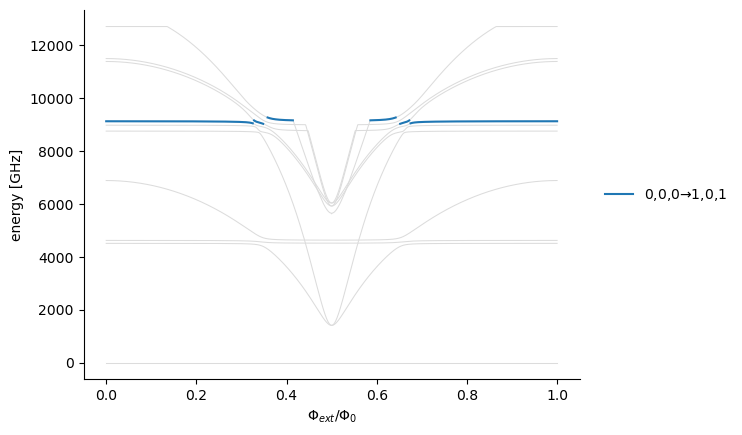

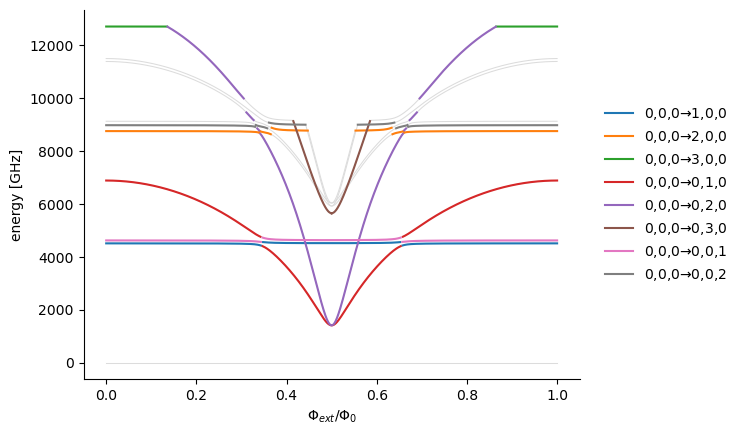

In [78]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
sweep.plot_transitions(initial=(0,0,0),final=(1,0,1))
# sweep["evals"].plot()
sweep.plot_transitions()


### 3.2 zz耦合和有效耦合的计算
有效耦合通过以下公式计算：
$$
g = g_{12}+\frac{g_{1}g_{2}}{\Delta}
$$
其中，$\Delta=(\frac{1}{\Delta_{1}}+\frac{1}{\Delta_{2}})/2$ 
$g_{12}$,$g_{1}$,$g_{2}$通过哈密顿量得到

ZZ耦合通过以下公式计算：
$$
\zeta_{zz}=\omega_{101}-(\omega_{100}+\omega_{001})
$$

有效耦合主要关注关断点，看是否能关断
ZZ耦合主要关注开关比，在大失谐的情况下无法完全关断ZZ耦合，但是最好将ZZ耦合最小强度抑制在20kHz附近
在解决比特非谐量附近会出现最大点，最大的强度最好高于15MHz以加快CZ门的操作

In [20]:
g_list = ham_result['g_list']
fc_list = ham_result['fc_list']
print(f"g_eff and fc calculated for {len(flux_vals)} flux points")


system frequencies in GHz:
--------------------------
{'transmon_alice': 4.505013295441957, 'tunabletransmon_bob': 6.880868590364418, 'transmon_charlie': 4.616087527379779}

Chi matrices in MHz
--------------------------
                     transmon_alice  tunabletransmon_bob  transmon_charlie
transmon_alice          -260.443736            -3.900822          0.233381
tunabletransmon_bob       -3.900822          -399.274604         -4.584460
transmon_charlie           0.233381            -4.584460       -259.717188

system frequencies in GHz:
--------------------------
{'transmon_alice': 4.50501326289554, 'tunabletransmon_bob': 6.880850747170014, 'transmon_charlie': 4.6160874849344475}

Chi matrices in MHz
--------------------------
                     transmon_alice  tunabletransmon_bob  transmon_charlie
transmon_alice          -260.443720            -3.900875          0.233377
tunabletransmon_bob       -3.900875          -399.274704         -4.584523
transmon_charlie           0.23

In [14]:
# g12,g1,g2,f1,f2
# g_array = np.array(g_list)
# min_index = np.argmin(np.abs(g_array))
# fc_list[min_index]
# list(zz),list(fc)
# sweep.transitions(final=(0,0,0))[1][0]
import pandas as pd

df = pd.DataFrame({'zz': zz, 'fc': fc_list,'zz101':sweep.transitions(final=(1,0,1))[1][0],'zz100':sweep.transitions(final=(1,0,0))[1][0],'zz001':sweep.transitions(final=(0,0,1))[1][0]})
df.to_csv(f'data/20qubit/tunable_coupler_zz.csv', index=False)

In [ ]:
# import numpy as np
# from scipy.linalg import eigh
# import matplotlib.pyplot as plt
# 
# # ================================================================
# # Method 1: 直接对角化 + 本征矢量重叠追踪
# # 完全绕过 scqubits 的 ParameterSweep 态标记机制
# # ================================================================
# 
# n_flux = len(flux_vals)
# dim = hilbertspace.dimension  # 4*4*4 = 64
# print(f"Hilbert space dimension: {dim}, flux points: {n_flux}")
# 
# # Step 1: 在每个磁通点对角化哈密顿量
# all_evals = np.zeros((n_flux, dim))
# all_evecs = np.zeros((n_flux, dim, dim), dtype=complex)
# 
# for i, flux in enumerate(flux_vals):
#     hilbertspace[1].flux = flux  # index 1 = tunable coupler (bob)
#     H_mat = hilbertspace.hamiltonian().full()  # Qobj -> numpy, 单位 MHz
#     evals, evecs = eigh(H_mat)  # eigh 返回升序排列的本征值
#     all_evals[i] = evals
#     all_evecs[i] = evecs  # 列为本征矢量
#     if i % 200 == 0:
#         print(f"  Progress: {i}/{n_flux}")
# 
# print("Diagonalization complete.")
# 
# # Step 2: 在 flux=0 处标记初始态（coupler ~8 GHz，远离 qubit，标记可靠）
# hilbertspace[1].flux = flux_vals[0]
# hilbertspace.generate_lookup()
# 
# idx_000 = hilbertspace.dressed_index((0, 0, 0))
# idx_100 = hilbertspace.dressed_index((1, 0, 0))
# idx_001 = hilbertspace.dressed_index((0, 0, 1))
# idx_101 = hilbertspace.dressed_index((1, 0, 1))
# print(f"Initial dressed indices: |000⟩={idx_000}, |100⟩={idx_100}, |001⟩={idx_001}, |101⟩={idx_101}")
# 
# # 验证：检查初始能量是否合理
# E0 = all_evals[0]
# print(f"ω_100 = {(E0[idx_100]-E0[idx_000])/1000:.4f} GHz (expect ~{f_a})")
# print(f"ω_001 = {(E0[idx_001]-E0[idx_000])/1000:.4f} GHz (expect ~{f_b})")
# 
# # Step 3: 用匈牙利算法同时追踪多个态（防止碰撞）
# from scipy.optimize import linear_sum_assignment
# 
# def track_multi_by_overlap(all_evecs, start_indices):
#     """
#     同时追踪多个态，用匈牙利算法做最优一对一分配。
#     保证不同追踪永远不会占同一个本征态。
#     
#     Parameters:
#         all_evecs: shape (n_flux, dim, dim), 列为本征矢量
#         start_indices: list of int, 初始 dressed index
#     Returns:
#         tracks: shape (n_states, n_flux), 每行是一个态的追踪 index
#     """
#     n_flux = all_evecs.shape[0]
#     dim = all_evecs.shape[1]
#     n_states = len(start_indices)
#     tracks = np.zeros((n_states, n_flux), dtype=int)
#     tracks[:, 0] = start_indices
#     
#     for i in range(1, n_flux):
#         # 构建重叠矩阵: overlap[s, j] = |⟨prev_s | current_j⟩|²
#         prev_evecs = all_evecs[i-1][:, tracks[:, i-1]]  # (dim, n_states)
#         curr_evecs = all_evecs[i]                        # (dim, dim)
#         overlap_matrix = np.abs(curr_evecs.conj().T @ prev_evecs)**2  # (dim, n_states)
#         
#         # 用匈牙利算法: 最小化 cost = 1 - overlap
#         cost = 1.0 - overlap_matrix.T  # (n_states, dim)
#         row_ind, col_ind = linear_sum_assignment(cost)
#         tracks[:, i] = col_ind
#     
#     return tracks
# 
# print("Tracking states by eigenvector overlap (Hungarian algorithm)...")
# start_indices = [idx_000, idx_100, idx_001, idx_101]
# tracks = track_multi_by_overlap(all_evecs, start_indices)
# t000, t100, t001, t101 = tracks[0], tracks[1], tracks[2], tracks[3]
# 
# # 诊断：检查追踪 index 是否有突变
# print(f"t000 range: {t000.min()}-{t000.max()}, jumps: {np.sum(np.abs(np.diff(t000)) > 0)}")
# print(f"t100 range: {t100.min()}-{t100.max()}, jumps: {np.sum(np.abs(np.diff(t100)) > 0)}")
# print(f"t001 range: {t001.min()}-{t001.max()}, jumps: {np.sum(np.abs(np.diff(t001)) > 0)}")
# print(f"t101 range: {t101.min()}-{t101.max()}, jumps: {np.sum(np.abs(np.diff(t101)) > 0)}")
# 
# # Step 4: 提取能量并计算 ZZ
# E000 = np.array([all_evals[i, t000[i]] for i in range(n_flux)])
# E100 = np.array([all_evals[i, t100[i]] for i in range(n_flux)])
# E001 = np.array([all_evals[i, t001[i]] for i in range(n_flux)])
# E101 = np.array([all_evals[i, t101[i]] for i in range(n_flux)])
# 
# # ZZ = E_101 - E_100 - E_001 + E_000  (scqubits 内部单位: MHz)
# zz_exact_MHz = E101 - E100 - E001 + E000  # 已经是 MHz
# 
# omega_100 = (E100 - E000) / 1000  # MHz -> GHz
# omega_001 = (E001 - E000) / 1000  # MHz -> GHz
# omega_101 = (E101 - E000) / 1000  # MHz -> GHz

In [ ]:
# # ================================================================
# # 验证：绘制追踪的跃迁频率，检查连续性
# # ================================================================
# plt.style.use('default')  # 强制白色背景
# fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='white')
# 
# # 跃迁频率 vs flux
# axes[0,0].plot(flux_vals, omega_100, '.', markersize=1.5, color='#1f77b4', label='ω_100 (alice)')
# axes[0,0].plot(flux_vals, omega_001, '.', markersize=1.5, color='#ff7f0e', label='ω_001 (charlie)')
# axes[0,0].set_xlabel('flux')
# axes[0,0].set_ylabel('Frequency (GHz)')
# axes[0,0].set_title('Qubit transitions vs flux')
# axes[0,0].legend()
# 
# axes[0,1].plot(flux_vals, omega_101, '.', markersize=1.5, color='#d62728')
# axes[0,1].set_xlabel('flux')
# axes[0,1].set_ylabel('Frequency (GHz)')
# axes[0,1].set_title('ω_101 vs flux')
# 
# # ZZ vs flux
# axes[0,2].plot(flux_vals, zz_exact_MHz, '.', markersize=1.5, color='#2ca02c')
# axes[0,2].set_xlabel('flux')
# axes[0,2].set_ylabel('ZZ (MHz)')
# axes[0,2].set_title('ZZ vs flux')
# 
# # ZZ vs fc
# axes[1,0].plot(fc_list, np.abs(zz_exact_MHz), '.', markersize=1.5, color='#1f77b4')
# axes[1,0].set_xlabel('fc (GHz)')
# axes[1,0].set_ylabel('ZZ (MHz)')
# axes[1,0].set_title('ZZ vs fc (full range)')
# # axes[1,0].set_ylim(0, 200)
# 
# axes[1,1].plot(fc_list, np.abs(zz_exact_MHz), '.', markersize=1.5, color='#9467bd')
# axes[1,1].set_xlabel('fc (GHz)')
# axes[1,1].set_ylabel('ZZ (MHz)')
# axes[1,1].set_xlim(3, 6)
# axes[1,1].set_title('ZZ vs fc (zoomed)')
# axes[1,1].set_ylim(0, 200)
# 
# axes[1,2].plot(fc_list, np.abs(zz_exact_MHz), '.', markersize=1.5, color='#e377c2')
# axes[1,2].set_xlabel('fc (GHz)')
# axes[1,2].set_ylabel('|ZZ| (MHz)')
# axes[1,2].set_xlim(5.5, 6.5)
# axes[1,2].set_ylim(0, 0.1)
# axes[1,2].set_title('|ZZ| vs fc (near zero-crossing)')
# 
# plt.tight_layout()
# plt.show()

Hilbert space dim: 144, flux points: 1001
Diagonalizing...
  0/1001
  200/1001
  400/1001
  600/1001
  800/1001
  1000/1001
Done.
  |000⟩ → dressed index 0
  |100⟩ → dressed index 1
  |001⟩ → dressed index 2
  |101⟩ → dressed index 6
  |200⟩ → dressed index 4
  |002⟩ → dressed index 5
  |110⟩ → dressed index 7
  |011⟩ → dressed index 8
Tracking states (Hungarian)...
Done.

避免交叉分析 (非绝热 CZ 门关键参数)

裸态能量估计:
  E(|101⟩) ≈ f_a + f_charlie = 4.51 + 4.62 GHz
  E(|200⟩) ≈ 2*f_a + α_a
  E(|002⟩) ≈ 2*f_charlie + α_charlie

--- |101⟩ - |200⟩ 避免交叉 ---
  交叉点: flux = 0.3370, fc = 4.799 GHz
  最小间隙: 246.91 MHz (at fc = 4.799 GHz)
  耦合强度 g = gap/2 = 123.45 MHz

--- |101⟩ - |002⟩ 避免交叉 ---
  交叉点: flux = 0.3310, fc = 4.858 GHz
  最小间隙: 86.81 MHz (at fc = 4.858 GHz)
  耦合强度 g = gap/2 = 43.41 MHz

非绝热 CZ 门参数

--- CZ via |101⟩-|200⟩ ---
  耦合 g = 123.45 MHz
  门时间 (理想) = 4.1 ns
  门时间 (实际) = 5.1 ns
  T1=20μs, T2=10μs → 退相干误差 0.078%, 保真度上限 99.92%
  T1=30μs, T2=20μs → 退相干误差 0.040%, 保真度上限 99.96%
  T1=50μs, T2=30μs → 退

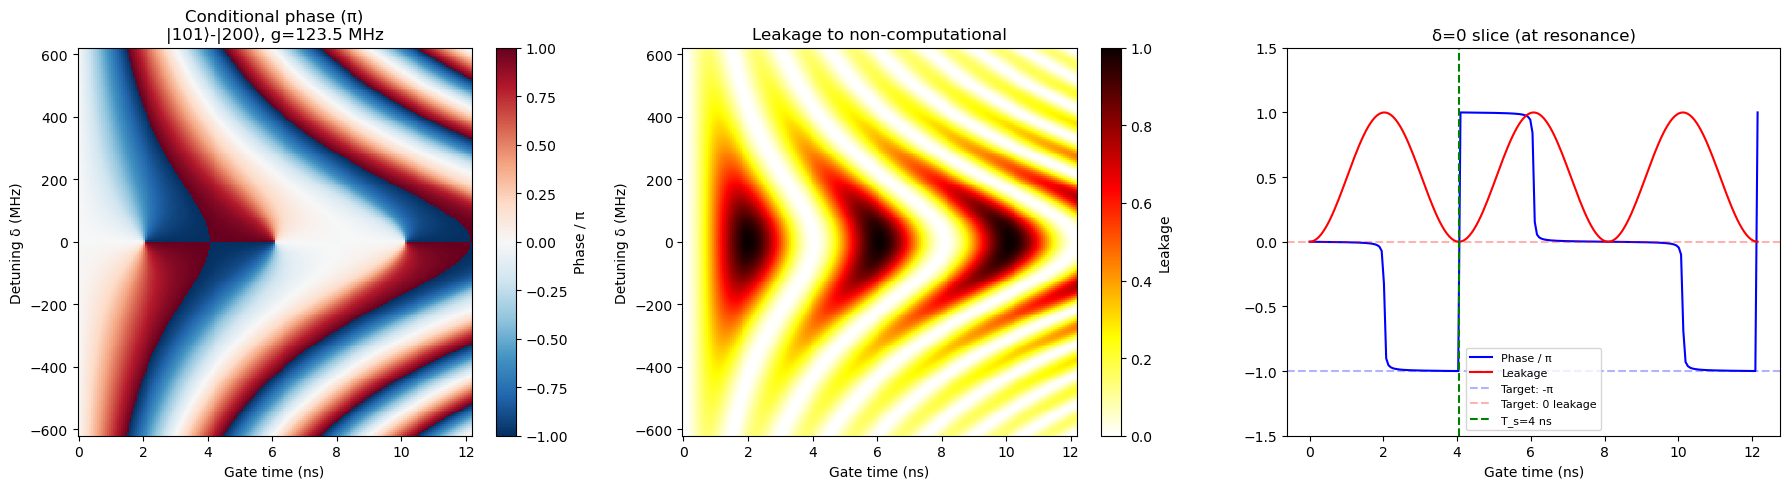

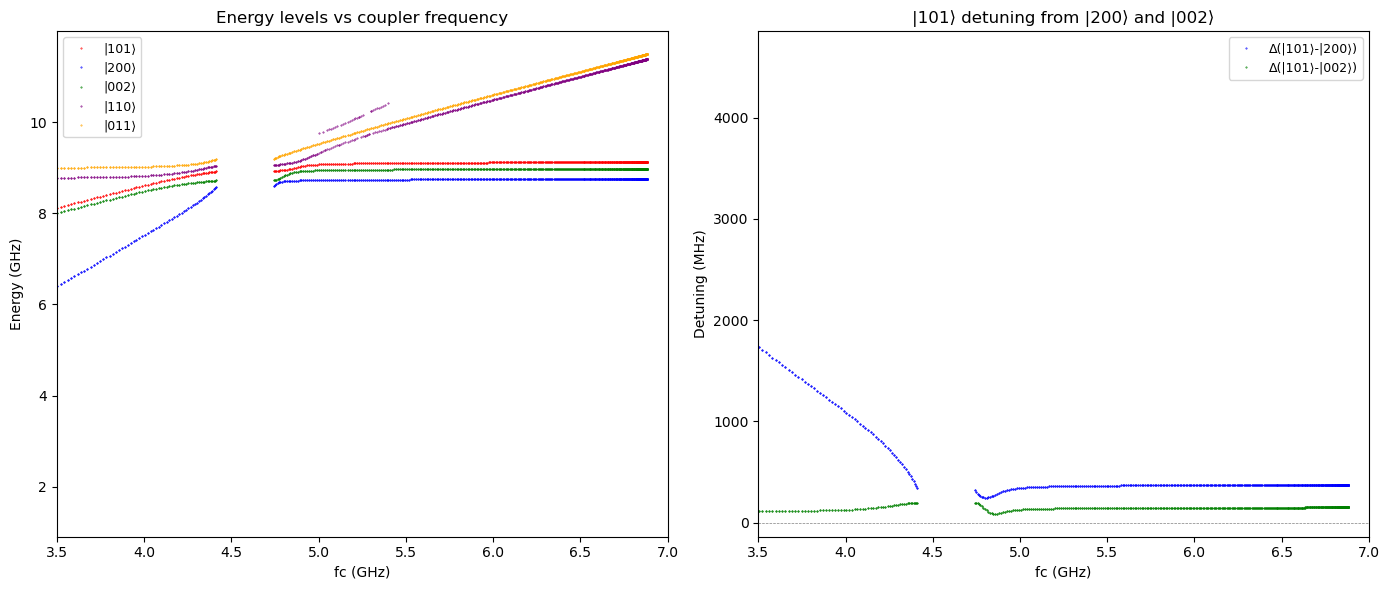


总结: 非绝热 CZ 门设计要点

1. 避免交叉间隙 (gap) → 决定门时间: T ≈ 1.25/(2g) = 625/g ns
2. 间隙越大 → 门越快 → 退相干误差越小 → 保真度越高
3. 实用要求: gap > 10 MHz (门时间 < 60 ns) 
4. CZ 操作: 将 coupler 磁通快速调到避免交叉点,
   等待 T_s = 1/(2g) 后快速调回 (方波脉冲)
5. 实际需要优化脉冲形状以减小泄漏 (< 0.2%)


In [80]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.linalg import eigh, expm
# from scipy.optimize import linear_sum_assignment
# 
# # ============================================================
# # 非绝热 CZ 门分析
# # ============================================================
# # 需要已有变量: hilbertspace, flux_vals, fc_list, f_a, f_b
# # 会重新做精确对角化和态追踪
# 
# plt.style.use('default')
# 
# # ========== 1. 精确对角化（复用或重新计算）==========
# n_flux = len(flux_vals)
# dim = hilbertspace.dimension
# print(f"Hilbert space dim: {dim}, flux points: {n_flux}")
# 
# all_evals = np.zeros((n_flux, dim))
# all_evecs = np.zeros((n_flux, dim, dim), dtype=complex)
# 
# print("Diagonalizing...")
# for i, flux in enumerate(flux_vals):
#     hilbertspace[1].flux = flux
#     H_mat = hilbertspace.hamiltonian().full()  # MHz
#     evals, evecs = eigh(H_mat)
#     all_evals[i] = evals
#     all_evecs[i] = evecs
#     if i % 200 == 0:
#         print(f"  {i}/{n_flux}")
# print("Done.")
# 
# # ========== 2. 标记初始态（包括 |200⟩ 和 |002⟩）==========
# hilbertspace[1].flux = flux_vals[0]
# hilbertspace.generate_lookup()
# 
# state_map = {
#     '000': (0,0,0), '100': (1,0,0), '001': (0,0,1),
#     '101': (1,0,1), '200': (2,0,0), '002': (0,0,2),
#     '110': (1,1,0), '011': (0,1,1),
# }
# idx = {}
# for name, bare in state_map.items():
#     try:
#         idx[name] = hilbertspace.dressed_index(bare)
#         print(f"  |{name}⟩ → dressed index {idx[name]}")
#     except:
#         print(f"  |{name}⟩ → FAILED (state not found)")
#         idx[name] = None
# 
# # ========== 3. 匈牙利算法同时追踪所有态 ==========
# valid_names = [n for n in state_map if idx[n] is not None]
# start_indices = [idx[n] for n in valid_names]
# 
# def track_multi(all_evecs, start_indices):
#     n_flux, dim, _ = all_evecs.shape
#     n_s = len(start_indices)
#     tracks = np.zeros((n_s, n_flux), dtype=int)
#     tracks[:, 0] = start_indices
#     for i in range(1, n_flux):
#         prev = all_evecs[i-1][:, tracks[:, i-1]]
#         curr = all_evecs[i]
#         olap = np.abs(curr.conj().T @ prev)**2
#         cost = 1.0 - olap.T
#         _, col = linear_sum_assignment(cost)
#         tracks[:, i] = col
#     return tracks
# 
# print("Tracking states (Hungarian)...")
# tracks = track_multi(all_evecs, start_indices)
# print("Done.")
# 
# # 提取能量 (MHz)
# E = {}
# for s, name in enumerate(valid_names):
#     E[name] = np.array([all_evals[i, tracks[s, i]] for i in range(n_flux)])
# 
# # 跃迁频率 (相对基态, MHz)
# omega = {name: E[name] - E['000'] for name in valid_names}
# 
# # ========== 4. 分析避免交叉 ==========
# print("\n" + "="*60)
# print("避免交叉分析 (非绝热 CZ 门关键参数)")
# print("="*60)
# 
# # 裸态能量估计
# print(f"\n裸态能量估计:")
# print(f"  E(|101⟩) ≈ f_a + f_charlie = {f_a} + {f_b} GHz")
# print(f"  E(|200⟩) ≈ 2*f_a + α_a")
# print(f"  E(|002⟩) ≈ 2*f_charlie + α_charlie")
# 
# for target in ['200', '002']:
#     if target not in valid_names or '101' not in valid_names:
#         continue
#     
#     delta = omega['101'] - omega[target]  # MHz
#     gap_curve = np.abs(omega['101'] - omega[target])
#     
#     # 找避免交叉：失谐最小点
#     idx_cross = np.argmin(np.abs(delta))
#     
#     # 在交叉点附近找最小间隙
#     w = min(80, n_flux // 10)
#     lo, hi = max(0, idx_cross - w), min(n_flux, idx_cross + w)
#     local_gap = gap_curve[lo:hi]
#     idx_min_local = np.argmin(local_gap)
#     idx_gap = lo + idx_min_local
#     gap = local_gap[idx_min_local]  # MHz
#     
#     fc_cross = fc_list[idx_cross] if idx_cross < len(fc_list) else float('nan')
#     fc_gap = fc_list[idx_gap] if idx_gap < len(fc_list) else float('nan')
#     
#     print(f"\n--- |101⟩ - |{target}⟩ 避免交叉 ---")
#     print(f"  交叉点: flux = {flux_vals[idx_cross]:.4f}, fc = {fc_cross:.3f} GHz")
#     print(f"  最小间隙: {gap:.2f} MHz (at fc = {fc_gap:.3f} GHz)")
#     print(f"  耦合强度 g = gap/2 = {gap/2:.2f} MHz")
# 
# # ========== 5. 非绝热 CZ 门参数计算 ==========
# print("\n" + "="*60)
# print("非绝热 CZ 门参数")
# print("="*60)
# 
# # 选择更接近的避免交叉作为 CZ 工作点
# for target in ['200', '002']:
#     if target not in valid_names or '101' not in valid_names:
#         continue
#     
#     delta = omega['101'] - omega[target]
#     gap_curve = np.abs(delta)
#     idx_cross = np.argmin(np.abs(delta))
#     w = min(80, n_flux // 10)
#     lo, hi = max(0, idx_cross - w), min(n_flux, idx_cross + w)
#     gap = np.min(gap_curve[lo:hi])
#     g_coupling = gap / 2  # MHz
#     
#     if g_coupling < 0.1:
#         print(f"\n|101⟩-|{target}⟩: 间隙太小 ({gap:.2f} MHz)，追踪可能不准")
#         continue
#     
#     # 门时间
#     T_s = 1000 / (2 * g_coupling)  # ns  (T_s = 1/(2g), g in GHz)
#     T_ideal = T_s                   # 理想无限带宽
#     T_realistic = 1.25 * T_s        # 实际 ~300 MHz 带宽 (Li et al. 2019)
#     
#     print(f"\n--- CZ via |101⟩-|{target}⟩ ---")
#     print(f"  耦合 g = {g_coupling:.2f} MHz")
#     print(f"  门时间 (理想) = {T_ideal:.1f} ns")
#     print(f"  门时间 (实际) = {T_realistic:.1f} ns")
#     
#     # 退相干限制保真度 (Li et al. 2019 公式)
#     for T1_us, T2_us in [(20, 10), (30, 20), (50, 30), (80, 50)]:
#         T1, T2 = T1_us * 1000, T2_us * 1000  # ns
#         Tphi = 1 / (1/T2 - 1/(2*T1)) if T2 < 2*T1 else 1e9  # ns
#         r_dec = T_realistic / T1 + 1.38 * T_realistic / Tphi
#         F = (1 - r_dec) * 100
#         print(f"  T1={T1_us}μs, T2={T2_us}μs → 退相干误差 {r_dec*100:.3f}%, 保真度上限 {F:.2f}%")
# 
# # ========== 6. Chevron 图 (条件相位 + 泄漏 vs 失谐 & 时间) ==========
# print("\n生成 Chevron 图...")
# 
# # 选择 |101⟩-|002⟩ 或 |101⟩-|200⟩（取间隙更大的）
# best_target = None
# best_gap = 0
# for target in ['200', '002']:
#     if target not in valid_names:
#         continue
#     delta = omega['101'] - omega[target]
#     idx_c = np.argmin(np.abs(delta))
#     w = min(80, n_flux // 10)
#     lo, hi = max(0, idx_c - w), min(n_flux, idx_c + w)
#     g = np.min(np.abs(omega['101'][lo:hi] - omega[target][lo:hi])) / 2
#     if g > best_gap:
#         best_gap = g
#         best_target = target
# 
# if best_target and best_gap > 0.1:
#     g_cz = best_gap  # MHz
#     print(f"CZ 工作点: |101⟩-|{best_target}⟩, g = {g_cz:.2f} MHz")
#     
#     # Chevron: 扫描失谐 δ 和门时间 t
#     delta_arr = np.linspace(-5 * g_cz, 5 * g_cz, 200)  # MHz
#     t_arr = np.linspace(0, 3000 / (2 * g_cz), 200)  # ns
#     
#     cond_phase = np.zeros((len(delta_arr), len(t_arr)))
#     leakage = np.zeros((len(delta_arr), len(t_arr)))
#     
#     for i, delta in enumerate(delta_arr):
#         for j, t in enumerate(t_arr):
#             d_GHz = delta * 1e-3
#             g_GHz = g_cz * 1e-3
#             H2 = np.array([[d_GHz/2, g_GHz], [g_GHz, -d_GHz/2]])
#             U = expm(-1j * 2 * np.pi * H2 * t)
#             psi = U @ np.array([1.0, 0.0])
#             cond_phase[i, j] = np.angle(psi[0]) / np.pi  # 单位: π
#             leakage[i, j] = np.abs(psi[1])**2
#     
#     fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')
#     
#     # Chevron: 条件相位
#     im0 = axes[0].pcolormesh(t_arr, delta_arr, cond_phase, 
#                               cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
#     axes[0].set_xlabel('Gate time (ns)')
#     axes[0].set_ylabel('Detuning δ (MHz)')
#     axes[0].set_title(f'Conditional phase (π)\n|101⟩-|{best_target}⟩, g={g_cz:.1f} MHz')
#     plt.colorbar(im0, ax=axes[0], label='Phase / π')
#     
#     # Chevron: 泄漏
#     im1 = axes[1].pcolormesh(t_arr, delta_arr, leakage,
#                               cmap='hot_r', vmin=0, vmax=1, shading='auto')
#     axes[1].set_xlabel('Gate time (ns)')
#     axes[1].set_ylabel('Detuning δ (MHz)')
#     axes[1].set_title('Leakage to non-computational')
#     plt.colorbar(im1, ax=axes[1], label='Leakage')
#     
#     # δ=0 切面 (理想 CZ 点)
#     idx_d0 = len(delta_arr) // 2
#     axes[2].plot(t_arr, cond_phase[idx_d0, :], label='Phase / π', color='blue')
#     axes[2].plot(t_arr, leakage[idx_d0, :], label='Leakage', color='red')
#     axes[2].axhline(y=-1, color='blue', linestyle='--', alpha=0.3, label='Target: -π')
#     axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.3, label='Target: 0 leakage')
#     T_cz = 1000 / (2 * g_cz)
#     axes[2].axvline(x=T_cz, color='green', linestyle='--', label=f'T_s={T_cz:.0f} ns')
#     axes[2].set_xlabel('Gate time (ns)')
#     axes[2].set_title(f'δ=0 slice (at resonance)')
#     axes[2].legend(fontsize=8)
#     axes[2].set_ylim(-1.5, 1.5)
#     
#     plt.tight_layout()
#     plt.show()
# 
# # ========== 7. 能级图 ==========
# fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
# 
# # 能级 vs fc
# ax = axes[0]
# for name, color in [('101','red'), ('200','blue'), ('002','green'), 
#                      ('110','purple'), ('011','orange')]:
#     if name in valid_names:
#         ax.plot(fc_list, omega[name]/1000, '.', markersize=0.8, label=f'|{name}⟩', color=color)
# ax.set_xlabel('fc (GHz)')
# ax.set_ylabel('Energy (GHz)')
# ax.set_title('Energy levels vs coupler frequency')
# ax.legend(fontsize=9)
# ax.set_xlim(3.5, 7)
# 
# # 失谐 vs fc
# ax = axes[1]
# for target, color, ls in [('200','blue','-'), ('002','green','-')]:
#     if target in valid_names and '101' in valid_names:
#         ax.plot(fc_list, omega['101'] - omega[target], '.', markersize=0.8, 
#                 label=f'Δ(|101⟩-|{target}⟩)', color=color)
# ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
# ax.set_xlabel('fc (GHz)')
# ax.set_ylabel('Detuning (MHz)')
# ax.set_title('|101⟩ detuning from |200⟩ and |002⟩')
# ax.legend(fontsize=9)
# ax.set_xlim(3.5, 7)
# 
# plt.tight_layout()
# plt.show()
# 
# print("\n" + "="*60)
# print("总结: 非绝热 CZ 门设计要点")
# print("="*60)
# print("""
# 1. 避免交叉间隙 (gap) → 决定门时间: T ≈ 1.25/(2g) = 625/g ns
# 2. 间隙越大 → 门越快 → 退相干误差越小 → 保真度越高
# 3. 实用要求: gap > 10 MHz (门时间 < 60 ns) 
# 4. CZ 操作: 将 coupler 磁通快速调到避免交叉点,
#    等待 T_s = 1/(2g) 后快速调回 (方波脉冲)
# 5. 实际需要优化脉冲形状以减小泄漏 (< 0.2%)
# """)

In [89]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.linalg import eigh, expm
# from scipy.interpolate import interp1d
# from scipy.optimize import linear_sum_assignment
# 
# plt.style.use('default')
# 
# 
# def adiabatic_cz_analysis(hilbertspace, flux_vals, fc_list,
#                           T1_us=30, T2_us=20,
#                           T_range=(20, 500), n_fc=40, n_T=100,
#                           pulse_type='cosine', flat_frac=0.5,
#                           n_evo=20000, plot=True):
#     """
#     绝热 CZ 门完整分析 (自包含: 对角化 + 态追踪 + 门分析)。
# 
#     Parameters
#     ----------
#     hilbertspace : scqubits.HilbertSpace
#         三体系统 (alice, coupler, charlie)
#     flux_vals : array
#         磁通扫描数组
#     fc_list : array-like
#         每个磁通点对应的 coupler 频率 (GHz)
#     T1_us, T2_us : float
#         退相干时间 (μs), 默认 30, 20
#     T_range : tuple
#         门时间搜索范围 (ns), 默认 (20, 500)
#     n_fc, n_T : int
#         fc_cz 和 T 的扫描网格大小
#     pulse_type : str
#         'cosine' 或 'flattop'
#     flat_frac : float
#         平顶比例 (仅 flattop 有效)
#     n_evo : int
#         2-level 时间演化步数
#     plot : bool
#         是否绘图
# 
#     Returns
#     -------
#     result : dict
#     """
#     fc_list = np.array(fc_list)
#     n_flux = len(flux_vals)
# 
#     # ============================================================
#     # Step 1: 精确对角化
#     # ============================================================
#     dim = hilbertspace.dimension
#     print(f"[1/7] 精确对角化... (dim={dim}, {n_flux} flux points)")
# 
#     all_evals = np.zeros((n_flux, dim))
#     all_evecs = np.zeros((n_flux, dim, dim), dtype=complex)
# 
#     for i, flux in enumerate(flux_vals):
#         hilbertspace[1].flux = flux
#         H = hilbertspace.hamiltonian().full()  # MHz
#         evals, evecs = eigh(H)
#         all_evals[i] = evals
#         all_evecs[i] = evecs
#         if (i + 1) % 200 == 0:
#             print(f"  {i+1}/{n_flux}")
#     print("  Done.")
# 
#     # ============================================================
#     # Step 2: 标记初始态
#     # ============================================================
#     print("[2/7] 标记初始态...")
#     hilbertspace[1].flux = flux_vals[0]
#     hilbertspace.generate_lookup()
# 
#     state_map = {
#         '000': (0,0,0), '100': (1,0,0), '001': (0,0,1),
#         '101': (1,0,1), '200': (2,0,0), '002': (0,0,2),
#     }
#     idx = {}
#     valid = []
#     for name, bare in state_map.items():
#         try:
#             idx[name] = hilbertspace.dressed_index(bare)
#             valid.append(name)
#             print(f"  |{name}⟩ → dressed {idx[name]}")
#         except Exception:
#             print(f"  |{name}⟩ → 未找到 (truncated_dim 太小?)")
# 
#     required = ['000', '100', '001', '101']
#     for s in required:
#         if s not in valid:
#             raise RuntimeError(f"|{s}⟩ 未找到, 请增大 truncated_dim")
# 
#     # ============================================================
#     # Step 3: 匈牙利算法态追踪
#     # ============================================================
#     print("[3/7] 态追踪 (匈牙利算法)...")
#     start = [idx[n] for n in valid]
# 
#     tracks = np.zeros((len(valid), n_flux), dtype=int)
#     tracks[:, 0] = start
#     for i in range(1, n_flux):
#         prev = all_evecs[i-1][:, tracks[:, i-1]]
#         curr = all_evecs[i]
#         olap = np.abs(curr.conj().T @ prev)**2
#         _, col = linear_sum_assignment(1.0 - olap.T)
#         tracks[:, i] = col
#     print("  Done.")
# 
#     # 提取能量 (MHz)
#     E = {}
#     for s, name in enumerate(valid):
#         E[name] = np.array([all_evals[i, tracks[s, i]]
#                             for i in range(n_flux)])
#     omega = {name: E[name] - E['000'] for name in valid}
# 
#     # 验证
#     print(f"  ω_alice  = {omega['100'][0]/1000:.4f} GHz")
#     print(f"  ω_charlie = {omega['001'][0]/1000:.4f} GHz")
# 
#     # ============================================================
#     # Step 4: ZZ 耦合 & 避免交叉
#     # ============================================================
#     print("[4/7] 分析避免交叉...")
#     zz_MHz = E['101'] - E['100'] - E['001'] + E['000']
# 
#     ac = {}
#     for tgt in ['002', '200']:
#         if tgt not in valid:
#             continue
#         d = omega['101'] - omega[tgt]
#         ic = np.argmin(np.abs(d))
#         w = min(80, n_flux // 10)
#         lo, hi = max(0, ic - w), min(n_flux, ic + w)
#         gap = np.min(np.abs(d[lo:hi]))
#         ac[tgt] = dict(delta=d, idx=ic, gap=gap, g=gap/2,
#                        fc=fc_list[ic])
#         print(f"  |101⟩-|{tgt}⟩: gap={gap:.1f} MHz, "
#               f"g={gap/2:.1f} MHz, fc={fc_list[ic]:.3f} GHz")
# 
#     leak_ch = '002' if '002' in ac else ('200' if '200' in ac else None)
#     if leak_ch is None:
#         raise RuntimeError("需要 |002⟩ 或 |200⟩, 请增大 truncated_dim")
# 
#     delta_MHz = ac[leak_ch]['delta']
#     g_ac = ac[leak_ch]['g']
#     fc_cross = ac[leak_ch]['fc']
#     fc_idle = fc_list[0]
# 
#     # ZZ 关键数值
#     zz_idle = zz_MHz[0]
#     zz_peak = zz_MHz[np.argmax(np.abs(zz_MHz))]
#     fc_at_peak = fc_list[np.argmax(np.abs(zz_MHz))]
#     # print(f"\n  ZZ 概览:")
#     # print(f"    idle (fc={fc_idle:.3f} GHz):  ZZ = {zz_idle:.4f} MHz")
#     # print(f"    峰值 (fc={fc_at_peak:.3f} GHz): ZZ = {zz_peak:.2f} MHz  "
#     #       f"(|ZZ|_max = {np.max(np.abs(zz_MHz)):.2f} MHz)")
#     # print(f"    泄漏通道: |101⟩-|{leak_ch}⟩, g = {g_ac:.1f} MHz")
#     # print(f"    idle fc = {fc_idle:.3f} GHz, 交叉 fc = {fc_cross:.3f} GHz")
# 
#     # 插值函数
#     si = np.argsort(fc_list)
#     fc_s, zz_s, delta_s = fc_list[si], zz_MHz[si], delta_MHz[si]
#     _, ui = np.unique(fc_s, return_index=True)
#     fc_s, zz_s, delta_s = fc_s[ui], zz_s[ui], delta_s[ui]
# 
#     zz_of_fc = interp1d(fc_s, zz_s, kind='linear',
#                         fill_value='extrapolate')
#     delta_of_fc = interp1d(fc_s, delta_s, kind='linear',
#                            fill_value='extrapolate')
# 
#     # ============================================================
#     # 内部工具函数
#     # ============================================================
#     def _pulse(t, T, fc0, fc1):
#         if pulse_type == 'flattop':
#             tr = (1 - flat_frac) * T / 2
#             env = np.where(
#                 t < tr, (1 - np.cos(np.pi * t / tr)) / 2,
#                 np.where(t > T - tr,
#                          (1 - np.cos(np.pi * (T-t) / tr)) / 2, 1.0))
#         else:
#             env = (1 - np.cos(2 * np.pi * t / T)) / 2
#         return fc0 + (fc1 - fc0) * env
# 
#     def _metrics(T, fc1, T1=T1_us, T2=T2_us, n=5000):
#         tt = np.linspace(0, T, n+1)
#         fc_t = _pulse(tt, T, fc_idle, fc1)
#         zz_t = zz_of_fc(fc_t)
#         delta_t = delta_of_fc(fc_t)
# 
#         integral = np.trapz(zz_t, tt)
#         phi_pi = 2 * np.pi * integral * 1e-3 / np.pi
# 
#         dddt = np.gradient(delta_t, tt)
#         i_min = np.argmin(np.abs(delta_t))
#         ww = max(1, n // 50)
#         v_max = np.max(np.abs(
#             dddt[max(0, i_min-ww):min(len(dddt), i_min+ww)]))
#         g_G, v_G = g_ac * 1e-3, v_max * 1e-3
#         P_LZ = np.exp(-2*np.pi * g_G**2 / v_G) \
#             if v_G > 1e-15 else 0.0
#         P_leak = min(2 * P_LZ, 1.0)
# 
#         T1n, T2n = T1*1000, T2*1000
#         Tphi = 1/(1/T2n - 1/(2*T1n)) if T2n < 2*T1n else 1e12
#         r_dec = T/T1n + 1.38*T/Tphi
# 
#         phase_err = abs(abs(phi_pi) - round(abs(phi_pi)))
#         F = (1-P_leak) * (1-r_dec) * np.cos(phase_err*np.pi/2)**2
# 
#         return dict(T=T, fc1=fc1, phi_pi=phi_pi, P_LZ=P_LZ,
#                     P_leak=P_leak, r_dec=r_dec, phase_err=phase_err,
#                     F=F, v_max=v_max,
#                     tt=tt, fc_t=fc_t, zz_t=zz_t, delta_t=delta_t)
# 
#     # ============================================================
#     # Step 5: 参数空间扫描
#     # ============================================================
#     print(f"[5/7] 扫描参数空间 ({pulse_type})...")
#     fc_lo = max(fc_cross - 0.3, fc_s[0] + 0.05)
#     fc_hi = min(fc_idle - 0.5, fc_cross + 1.5)
#     fc_cz_arr = np.linspace(fc_hi, fc_lo, n_fc)
#     T_arr = np.linspace(T_range[0], T_range[1], n_T).astype(int)
# 
#     phase_map = np.zeros((n_fc, n_T))
#     leak_map = np.zeros_like(phase_map)
#     fid_map = np.zeros_like(phase_map)
# 
#     for i, fc1 in enumerate(fc_cz_arr):
#         for j, T in enumerate(T_arr):
#             r = _metrics(T, fc1)
#             phase_map[i,j] = r['phi_pi']
#             leak_map[i,j] = r['P_leak']
#             fid_map[i,j] = r['F']
#         if (i+1) % 10 == 0:
#             print(f"  {i+1}/{n_fc}")
#     print("  Done.")
# 
#     # ============================================================
#     # Step 6: 找 CZ 工作点 (φ = ±π)
#     # ============================================================
#     print("[6/7] 寻找 CZ 工作点...")
#     cz_pts = []
#     for i, fc1 in enumerate(fc_cz_arr):
#         ph = phase_map[i, :]
#         for tph in [-1.0, 1.0]:
#             cx = np.where(np.diff(np.sign(ph - tph)))[0]
#             for c in cx:
#                 T_cz = T_arr[c] + (tph - ph[c]) / \
#                     (ph[c+1] - ph[c]) * (T_arr[c+1] - T_arr[c])
#                 if T_cz < T_range[0] or T_cz > T_range[1] + 50:
#                     continue
#                 cz_pts.append(_metrics(T_cz, fc1))
# 
#     best = max(cz_pts, key=lambda x: x['F']) if cz_pts else None
# 
#     if best:
#         zz_at_cz = zz_of_fc(best['fc1'])
#         zz_peak_val = np.max(np.abs(best['zz_t']))
#         print(f"\n{'='*55}")
#         print(f"最优绝热 CZ 工作点 ({pulse_type})")
#         print(f"{'='*55}")
#         print(f"  fc_cz        = {best['fc1']:.3f} GHz")
#         print(f"  T_gate       = {best['T']:.1f} ns")
#         print(f"  ZZ(fc_cz)    = {zz_at_cz:.2f} MHz  (脉冲底部)")
#         print(f"  ZZ_peak(t)   = {zz_peak_val:.2f} MHz  (脉冲过程中最大)")
#         print(f"  ZZ_idle      = {zz_MHz[0]:.4f} MHz")
#         print(f"  开关比       = {zz_peak_val / max(abs(zz_MHz[0]), 1e-6):.0f}x")
#         print(f"  条件相位     = {best['phi_pi']:.4f} π")
#         print(f"  LZ 泄漏      = {best['P_leak']:.2e}")
#         print(f"  退相干误差   = {best['r_dec']*100:.3f}%")
#         print(f"  保真度       ≈ {best['F']*100:.2f}%")
#     else:
#         print("  未找到! 尝试增大 T_range")
# 
#     # ============================================================
#     # Step 7: 2-level 精确演化 + 保真度预算
#     # ============================================================
#     evo, budget = None, []
#     if best:
#         print("[7/7] 2-level 精确演化...")
#         dt = best['T'] / n_evo
#         tt_e = np.linspace(0, best['T'], n_evo+1)
#         fc_e = _pulse(tt_e, best['T'], fc_idle, best['fc1'])
#         delta_e = delta_of_fc(fc_e) * 1e-3
#         g_G = g_ac * 1e-3
# 
#         psi = np.array([1.0+0j, 0.0+0j])
#         p101, pleak = [1.0], [0.0]
#         for k in range(n_evo):
#             H = np.array([[delta_e[k]/2, g_G],
#                           [g_G, -delta_e[k]/2]])
#             psi = expm(-1j * 2*np.pi * H * dt) @ psi
#             p101.append(np.abs(psi[0])**2)
#             pleak.append(np.abs(psi[1])**2)
# 
#         evo = dict(tt=tt_e, pop_101=np.array(p101),
#                    pop_leak=np.array(pleak),
#                    final_leak=pleak[-1],
#                    final_phase=np.angle(psi[0]) / np.pi)
#         print(f"  泄漏 = {evo['final_leak']:.2e}, "
#               f"相位 = {evo['final_phase']:.4f} π")
# 
#         # 保真度预算
#         for T1, T2 in [(20,10),(30,20),(50,30),(80,50),(100,80)]:
#             r = _metrics(best['T'], best['fc1'], T1=T1, T2=T2)
#             budget.append(dict(T1=T1, T2=T2, r_dec=r['r_dec'],
#                                P_leak=r['P_leak'], F=r['F']))
# 
#         print(f"\n  {'T1':>6} {'T2':>6} {'退相干%':>10} "
#               f"{'泄漏%':>10} {'保真度%':>10}")
#         print("  " + "-"*50)
#         for b in budget:
#             print(f"  {b['T1']:>6} {b['T2']:>6} "
#                   f"{b['r_dec']*100:>10.3f} "
#                   f"{b['P_leak']*100:>10.4f} "
#                   f"{b['F']*100:>10.2f}")
# 
#     # ============================================================
#     # 绘图
#     # ============================================================
#     if plot and best:
#         fig, axes = plt.subplots(2, 3, figsize=(18, 10),
#                                  facecolor='white')
# 
#         ax = axes[0,0]
#         ax.plot(fc_list, zz_MHz, '.', ms=1, color='#1f77b4')
#         ax.axhline(0, color='gray', ls='--', lw=0.5)
#         ax.axvline(best['fc1'], color='red', ls='--',
#                    label=f"CZ fc={best['fc1']:.2f}")
#         ax.axvline(fc_cross, color='green', ls=':',
#                    label=f"Crossing fc={fc_cross:.2f}")
#         ax.set_xlabel('fc (GHz)'); ax.set_ylabel('ZZ (MHz)')
#         ax.set_title('ZZ vs fc'); ax.legend(fontsize=8)
# 
#         ax = axes[0,1]
#         im = ax.pcolormesh(T_arr, fc_cz_arr, phase_map,
#                            cmap='RdBu_r', vmin=-3, vmax=3,
#                            shading='auto')
#         ax.contour(T_arr, fc_cz_arr, phase_map,
#                    levels=[-1,1], colors='black', linewidths=1.5)
#         ax.plot(best['T'], best['fc1'], 'r*', ms=15)
#         plt.colorbar(im, ax=ax, label='Phase / π')
#         ax.set_xlabel('T (ns)'); ax.set_ylabel('fc_cz (GHz)')
#         ax.set_title('conditional phase')
# 
#         ax = axes[0,2]
#         im2 = ax.pcolormesh(T_arr, fc_cz_arr,
#                             np.log10(leak_map+1e-20),
#                             cmap='hot_r', vmin=-8, vmax=0,
#                             shading='auto')
#         ax.contour(T_arr, fc_cz_arr, phase_map,
#                    levels=[-1,1], colors='cyan', linewidths=1)
#         ax.plot(best['T'], best['fc1'], 'c*', ms=15)
#         plt.colorbar(im2, ax=ax, label='log₁₀(P_leak)')
#         ax.set_xlabel('T (ns)'); ax.set_ylabel('fc_cz (GHz)')
#         ax.set_title('LZ leak')
# 
#         ax = axes[1,0]; ax2 = ax.twinx()
#         ax.plot(best['tt'], best['fc_t'], '-', color='blue', lw=1.5)
#         ax2.plot(best['tt'], best['zz_t'], '-', color='red',
#                  alpha=0.7)
#         ax.set_xlabel('t (ns)')
#         ax.set_ylabel('fc (GHz)', color='blue')
#         ax2.set_ylabel('ZZ (MHz)', color='red')
#         ax.set_title(f'Pulse T={best["T"]:.0f} ns')
# 
#         ax = axes[1,1]
#         ax.plot(evo['tt'], evo['pop_101'],
#                 label='P(|101⟩)', color='blue')
#         ax.plot(evo['tt'], evo['pop_leak'],
#                 label=f'Leak→|{leak_ch}⟩', color='red')
#         ax.set_xlabel('t (ns)'); ax.set_ylabel('Population')
#         ax.set_title(f'evolution (leak={evo["final_leak"]:.2e})')
#         ax.legend(fontsize=8); ax.set_ylim(-0.05, 1.05)
# 
#         ax = axes[1,2]
#         Ts = np.arange(T_range[0], T_range[1], 3)
#         Fs = [_metrics(T, best['fc1'])['F'] for T in Ts]
#         ax.plot(Ts, np.array(Fs)*100, '-', color='blue')
#         ax.axvline(best['T'], color='red', ls='--',
#                    label=f"best T={best['T']:.0f} ns")
#         ax.set_xlabel('T (ns)'); ax.set_ylabel('Fidelity (%)')
#         ax.set_title('fidelity vs gate time')
#         ax.legend(fontsize=8)
#         ax.set_ylim(80, 100.5); ax.grid(True, alpha=0.3)
# 
#         plt.tight_layout()
#         plt.show()
# 
#     return dict(best=best, cz_pts=cz_pts, evo=evo, budget=budget,
#                 ac=ac, leak_channel=leak_ch,
#                 E=E, omega=omega, zz_MHz=zz_MHz,
#                 zz_of_fc=zz_of_fc, delta_of_fc=delta_of_fc,
#                 phase_map=phase_map, leak_map=leak_map,
#                 fid_map=fid_map, fc_cz_arr=fc_cz_arr, T_arr=T_arr,
#                 _pulse=_pulse, _metrics=_metrics)

[1/7] 精确对角化... (dim=144, 1001 flux points)
  200/1001
  400/1001
  600/1001
  800/1001


 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153


  1000/1001
  Done.
[2/7] 标记初始态...
  |000⟩ → dressed 0
  |100⟩ → dressed 1
  |001⟩ → dressed 2
  |101⟩ → dressed 6
  |200⟩ → dressed 4
  |002⟩ → dressed 5
[3/7] 态追踪 (匈牙利算法)...
  Done.
  ω_alice  = 4.5050 GHz
  ω_charlie = 4.6161 GHz
[4/7] 分析避免交叉...
  |101⟩-|002⟩: gap=86.8 MHz, g=43.4 MHz, fc=4.858 GHz
  |101⟩-|200⟩: gap=246.9 MHz, g=123.5 MHz, fc=4.799 GHz
[5/7] 扫描参数空间 (cosine)...
  10/40
  20/40
  30/40
  40/40
  Done.
[6/7] 寻找 CZ 工作点...

最优绝热 CZ 工作点 (cosine)
  fc_cz        = 4.927 GHz
  T_gate       = 256.8 ns
  ZZ(fc_cz)    = -19.08 MHz  (脉冲底部)
  ZZ_peak(t)   = 19.08 MHz  (脉冲过程中最大)
  ZZ_idle      = 0.2334 MHz
  开关比       = 82x
  条件相位     = -1.0000 π
  LZ 泄漏      = 4.15e-06
  退相干误差   = 2.037%
  保真度       ≈ 97.96%
[7/7] 2-level 精确演化...


 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\1063915482.py: 388
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\1063915482.py: 388
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\1063915482.py: 388


  泄漏 = 1.78e-01, 相位 = -0.7056 π

      T1     T2       退相干%        泄漏%       保真度%
  --------------------------------------------------
      20     10      3.941     0.0004      96.06
      30     20      2.037     0.0004      97.96
      50     30      1.340     0.0004      98.66
      80     50      0.808     0.0004      99.19
     100     80      0.523     0.0004      99.48


 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\1063915482.py: 388
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152


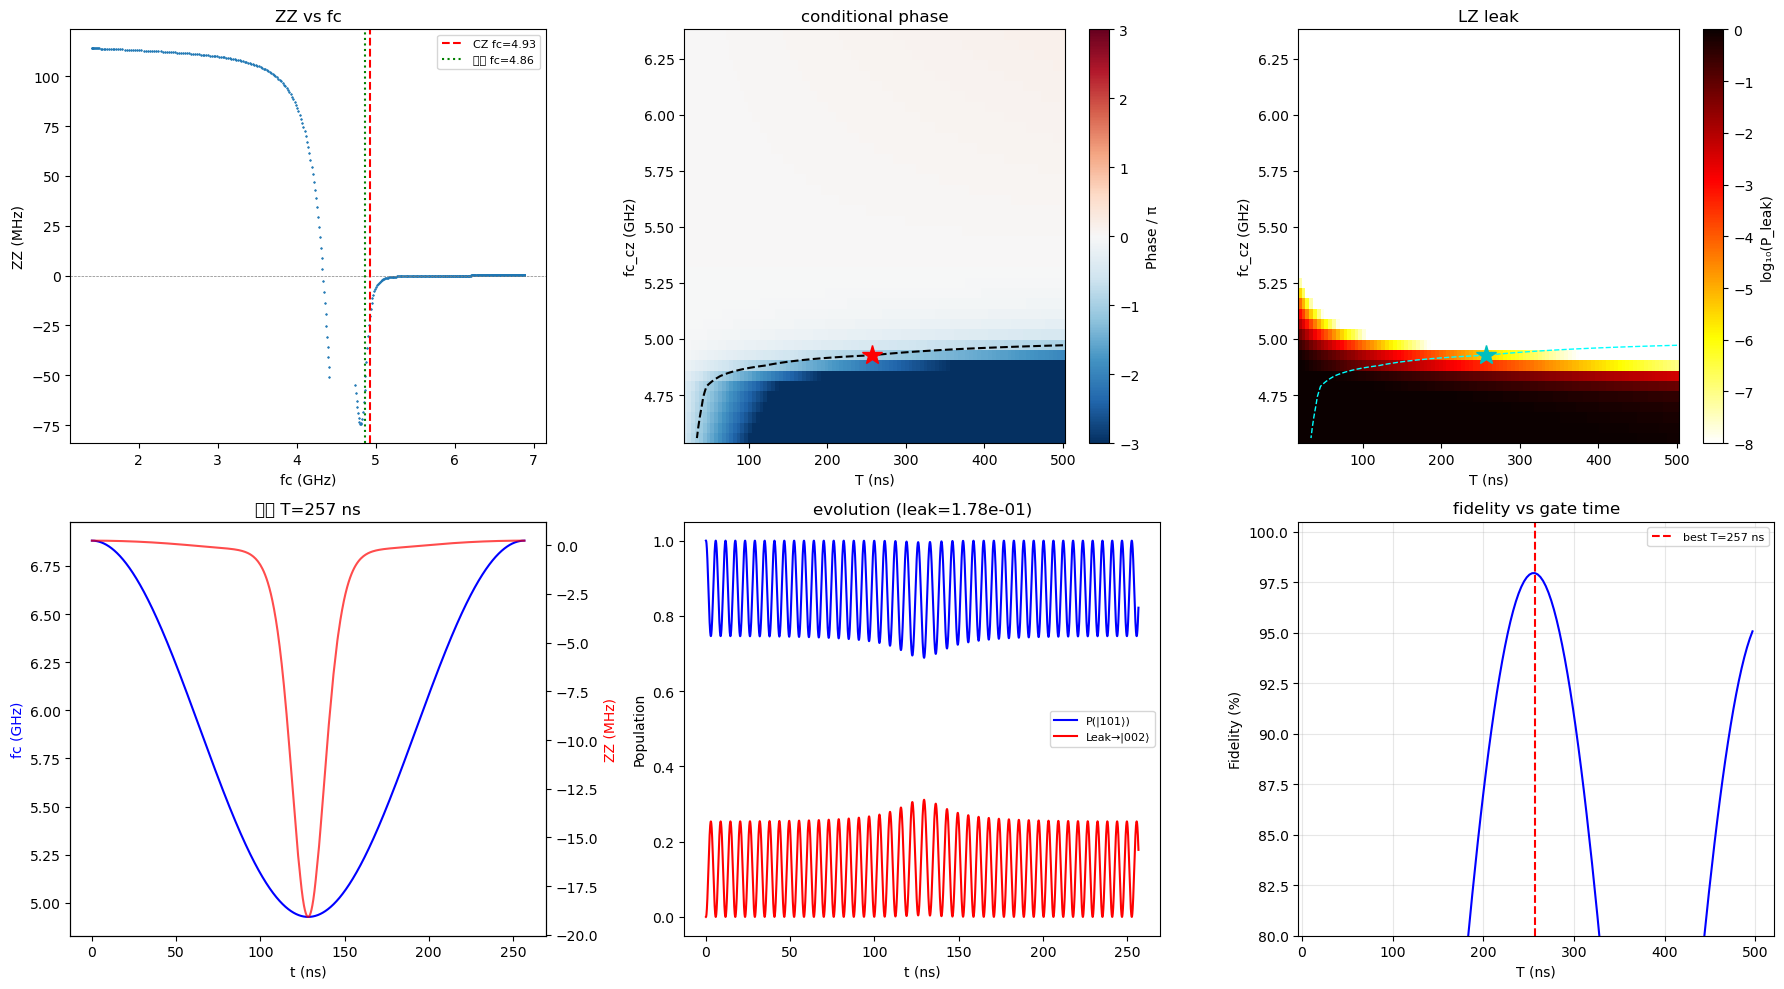

In [90]:
# result = adiabatic_cz_analysis(hilbertspace, flux_vals, fc_list)

In [91]:
# import numpy as np
# import matplotlib.pyplot as plt
# 
# plt.style.use('default')
# 
# 
# def geff_analysis(hilbertspace, flux_vals, fc_list, plot=True):
#     """
#     计算有效耦合强度 g_eff vs coupler 频率，找关断点。
# 
#     方法: Schrieffer-Wolff 二阶微扰，将完整哈密顿量
#     投影到 {|100⟩, |001⟩} 计算子空间。
# 
#     Parameters
#     ----------
#     hilbertspace : scqubits.HilbertSpace
#     flux_vals : array
#     fc_list : array-like
#         每个磁通点的 coupler 频率 (GHz)
#     plot : bool
# 
#     Returns
#     -------
#     dict
#     """
#     fc_list = np.array(fc_list)
#     n_flux = len(flux_vals)
#     dims = hilbertspace.subsystem_dims
#     dim = hilbertspace.dimension
#     d_a, d_b, d_c = dims[0], dims[1], dims[2]
# 
#     # 裸态索引 (QuTiP tensor product: 第一个子系统变化最慢)
#     def bare_idx(na, nb, nc):
#         return na * d_b * d_c + nb * d_c + nc
# 
#     i_000 = bare_idx(0, 0, 0)
#     i_100 = bare_idx(1, 0, 0)  # alice 激发
#     i_010 = bare_idx(0, 1, 0)  # coupler 激发
#     i_001 = bare_idx(0, 0, 1)  # charlie 激发
#     comp = [i_100, i_001]
# 
#     # ---------- 验证索引 ----------
#     hilbertspace[1].flux = flux_vals[0]
#     H0 = np.real(hilbertspace.hamiltonian().full())
#     f1_bare = (H0[i_100, i_100] - H0[i_000, i_000]) / 1000  # GHz
#     f2_bare = (H0[i_001, i_001] - H0[i_000, i_000]) / 1000
#     fc_bare = (H0[i_010, i_010] - H0[i_000, i_000]) / 1000
# 
#     print("验证裸态索引:")
#     print(f"  f_alice   = {f1_bare:.4f} GHz")
#     print(f"  f_charlie = {f2_bare:.4f} GHz")
#     print(f"  f_coupler = {fc_bare:.4f} GHz  (fc_list[0]={fc_list[0]:.4f})")
# 
#     if abs(fc_bare - fc_list[0]) > 1.0:
#         print("  ⚠ 频率不匹配! 可能需要检查子系统顺序")
# 
#     # ---------- 计算 g_eff ----------
#     g_eff_arr = np.zeros(n_flux)      # 总有效耦合 (MHz)
#     g_direct_arr = np.zeros(n_flux)   # 直接耦合 (MHz)
#     g_indirect_arr = np.zeros(n_flux) # coupler 介导 (MHz)
#     g1c_arr = np.zeros(n_flux)        # alice-coupler (MHz)
#     g2c_arr = np.zeros(n_flux)        # charlie-coupler (MHz)
# 
#     print(f"\n计算 g_eff ({n_flux} 个磁通点)...")
#     for i, flux in enumerate(flux_vals):
#         hilbertspace[1].flux = flux
#         H = np.real(hilbertspace.hamiltonian().full())  # MHz
# 
#         # 直接耦合: ⟨100|H|001⟩
#         g_direct = H[i_100, i_001]
# 
#         # alice-coupler 和 charlie-coupler 耦合
#         g1c_arr[i] = H[i_100, i_010]  # ⟨100|H|010⟩
#         g2c_arr[i] = H[i_010, i_001]  # ⟨010|H|001⟩
# 
#         # 二阶微扰 (Schrieffer-Wolff):
#         # g_eff = g_direct + Σ_n ⟨100|H|n⟩⟨n|H|001⟩ / (E_ref - E_n)
#         E_ref = (H[i_100, i_100] + H[i_001, i_001]) / 2
#         g_sw = 0.0
#         for n in range(dim):
#             if n in comp:
#                 continue
#             denom = E_ref - H[n, n]
#             if abs(denom) > 1e-6:
#                 g_sw += H[i_100, n] * H[n, i_001] / denom
# 
#         g_eff_arr[i] = g_direct + g_sw
#         g_direct_arr[i] = g_direct
#         g_indirect_arr[i] = g_sw
# 
#         if (i + 1) % 200 == 0:
#             print(f"  {i+1}/{n_flux}")
#     print("  Done.")
# 
#     # ---------- 找关断点 ----------
#     off_points = []
#     sign_changes = np.where(np.diff(np.sign(g_eff_arr)))[0]
#     for c in sign_changes:
#         fc_off = fc_list[c] + (-g_eff_arr[c]) / \
#             (g_eff_arr[c+1] - g_eff_arr[c]) * \
#             (fc_list[c+1] - fc_list[c])
#         flux_off = flux_vals[c] + (-g_eff_arr[c]) / \
#             (g_eff_arr[c+1] - g_eff_arr[c]) * \
#             (flux_vals[c+1] - flux_vals[c])
#         off_points.append(dict(fc=fc_off, flux=flux_off))
# 
#     # ---------- 打印结果 ----------
#     print(f"\n{'='*55}")
#     print("g_eff 分析结果")
#     print(f"{'='*55}")
#     print(f"  f_alice   = {f1_bare:.4f} GHz")
#     print(f"  f_charlie = {f2_bare:.4f} GHz")
#     print(f"  Δ_qubit   = {(f1_bare - f2_bare)*1000:.1f} MHz")
#     print(f"\n  idle (fc={fc_list[0]:.3f} GHz):")
#     print(f"    g_eff     = {g_eff_arr[0]:.4f} MHz")
#     print(f"    g_direct  = {g_direct_arr[0]:.4f} MHz  (电容直接耦合)")
#     print(f"    g_indirect= {g_indirect_arr[0]:.4f} MHz  (coupler 介导)")
#     print(f"    g_1c      = {g1c_arr[0]:.2f} MHz  (alice-coupler)")
#     print(f"    g_2c      = {g2c_arr[0]:.2f} MHz  (charlie-coupler)")
# 
#     print(f"\n  g_eff 范围: [{np.min(g_eff_arr):.4f}, "
#           f"{np.max(g_eff_arr):.4f}] MHz")
# 
#     if off_points:
#         print(f"\n  关断点 (g_eff = 0):")
#         for j, p in enumerate(off_points):
#             print(f"    #{j+1}: fc = {p['fc']:.4f} GHz, "
#                   f"flux = {p['flux']:.4f}")
#     else:
#         print("\n  ⚠ 未找到关断点 (g_eff 没有过零)")
# 
#     # ---------- 绘图 ----------
#     if plot:
#         fig, axes = plt.subplots(2, 2, figsize=(14, 10),
#                                  facecolor='white')
# 
#         # g_eff vs fc
#         ax = axes[0, 0]
#         ax.plot(fc_list, g_eff_arr, '.', ms=1.5, color='blue')
#         ax.axhline(0, color='gray', ls='--', lw=0.5)
#         for p in off_points:
#             ax.axvline(p['fc'], color='red', ls='--', lw=1,
#                        label=f"Off fc={p['fc']:.3f}")
#         ax.set_xlabel('fc (GHz)')
#         ax.set_ylabel('g_eff (MHz)')
#         ax.set_title('g_eff vs coupler frequency')
#         ax.legend(fontsize=8)
# 
#         # g_eff vs fc (zoom)
#         ax = axes[0, 1]
#         ax.plot(fc_list, g_eff_arr, '.', ms=1.5, color='blue')
#         ax.axhline(0, color='gray', ls='--', lw=0.5)
#         for p in off_points:
#             ax.axvline(p['fc'], color='red', ls='--', lw=1)
#         ylim = max(np.abs(g_eff_arr).max() * 0.3, 0.5)
#         ax.set_ylim(-ylim, ylim)
#         ax.set_xlabel('fc (GHz)')
#         ax.set_ylabel('g_eff (MHz)')
#         ax.set_title('g_eff vs fc (near off-point)')
#         ax.grid(True, alpha=0.3)
# 
#         # g_eff vs flux
#         ax = axes[1, 0]
#         ax.plot(flux_vals, g_eff_arr, '.', ms=1.5, color='blue')
#         ax.axhline(0, color='gray', ls='--', lw=0.5)
#         for p in off_points:
#             ax.axvline(p['flux'], color='red', ls='--', lw=1,
#                        label=f"Off Φ={p['flux']:.3f}")
#         ax.set_xlabel('flux (Φ/Φ₀)')
#         ax.set_ylabel('g_eff (MHz)')
#         ax.set_title('g_eff vs flux')
#         ax.legend(fontsize=8)
# 
#         # Coupling decomposition
#         ax = axes[1, 1]
#         ax.plot(fc_list, g_direct_arr, '.', ms=1, color='green',
#                 label='g_direct (direct)')
#         ax.plot(fc_list, g_indirect_arr, '.', ms=1, color='orange',
#                 label='g_indirect (coupler-mediated)')
#         ax.plot(fc_list, g_eff_arr, '.', ms=1, color='blue',
#                 label='g_eff (total)')
#         ax.axhline(0, color='gray', ls='--', lw=0.5)
#         ax.set_xlabel('fc (GHz)')
#         ax.set_ylabel('g (MHz)')
#         ax.set_title('Coupling decomp: direct + coupler-mediated')
#         ax.legend(fontsize=8)
# 
#         plt.tight_layout()
#         plt.show()
# 
#     return dict(
#         g_eff=g_eff_arr, g_direct=g_direct_arr,
#         g_indirect=g_indirect_arr,
#         g1c=g1c_arr, g2c=g2c_arr,
#         fc=fc_list, flux=flux_vals,
#         off_points=off_points,
#         f1=f1_bare, f2=f2_bare,
#     )

验证裸态索引:
  f_alice   = 4.5138 GHz
  f_charlie = 4.6252 GHz
  f_coupler = 6.8687 GHz  (fc_list[0]=6.8809)

计算 g_eff (1001 个磁通点)...
  200/1001
  400/1001
  600/1001
  800/1001


 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\ls\AppData\Local\Temp\ipykernel_66780\272864243.py: 188
 C:\Users\

  1000/1001
  Done.

g_eff 分析结果
  f_alice   = 4.5138 GHz
  f_charlie = 4.6252 GHz
  Δ_qubit   = -111.5 MHz

  idle (fc=6.881 GHz):
    g_eff     = -3.2283 MHz
    g_direct  = -12.3054 MHz  (电容直接耦合)
    g_indirect= 9.0770 MHz  (coupler 介导)
    g_1c      = 131.00 MHz  (alice-coupler)
    g_2c      = -132.61 MHz  (charlie-coupler)

  g_eff 范围: [-814.9595, 23014.4295] MHz

  关断点 (g_eff = 0):
    #1: fc = 5.9735 GHz, flux = 0.2231
    #2: fc = 4.4049 GHz, flux = 0.3460
    #3: fc = 4.4049 GHz, flux = 0.6540
    #4: fc = 5.9735 GHz, flux = 0.7769


 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\IPython\core\pylabtools.py: 152

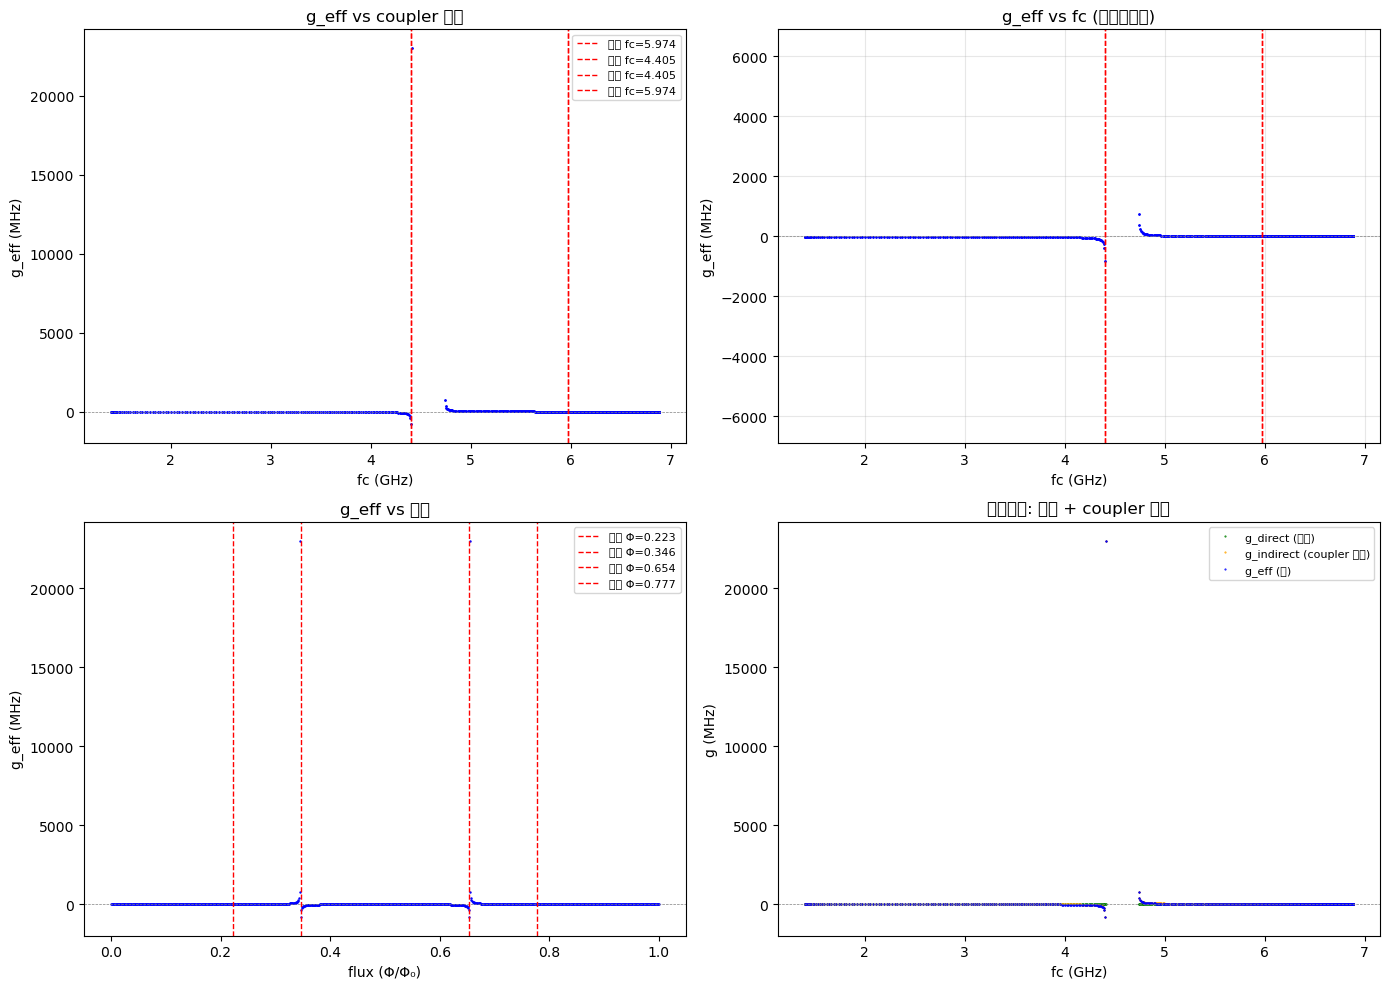

In [92]:
# result = geff_analysis(hilbertspace, flux_vals, fc_list)

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh, expm
from scipy.interpolate import interp1d
from scipy.optimize import linear_sum_assignment
from scipy.signal.windows import dpss
import os, io, sys

plt.style.use('default')


def tunable_coupler_analysis(
    hilbertspace, flux_vals, fc_list=None,
    # 选择分析模块
    run_geff=True,
    run_nonadiabatic=True,
    run_adiabatic=True,
    # 退相干参数
    T1_us=30, T2_us=20,
    # 绝热门参数
    adi_T_range=(20, 500), adi_n_fc=40, adi_n_T=100,
    adi_pulse='cosine', adi_flat_frac=0.5,
    # 非绝热门参数
    na_T_gate=None,       # 非绝热门时间 (ns), None=40ns
    na_ramp_ns=5.0,       # flat-top ramp 时间 (ns)
    na_2d_nf1=40,         # 2D f1 扫描点数
    na_2d_nfc=45,         # 2D fc 扫描点数
    na_2d_f1_range=100,   # f1 共振点 ± 范围 (MHz)
    na_2d_fc_range=300,   # fc QB2 频率 ± 范围 (MHz)
    na_slepian_opt=False, # Slepian 脉冲优化 (NW scan + Nelder-Mead + K=4)
    # 非绝热门快速评估参数
    run_na_quality=True,  # 快速评估: 避免交叉间隙 + 旁观态隔离度
    na_q_nfc=200,         # 快速评估 fc 扫描点数
    # 通用参数
    n_evo=20000, plot=True,
    save_dir=None,
):
    """
    Tunable coupler analysis: g_eff + non-adiabatic CZ + adiabatic CZ.
    Gate fidelity following Sung et al. PRX 2021 / Li et al. npjQI 2019:
    - Evolves all 4 comp. states in excitation-number sectors
    - Builds 4x4 U_P, applies virtual-Z correction
    - F = |Tr(U_CZ† U_P)|²/16, F_avg = (4F+1)/5

    Parameters
    ----------
    hilbertspace : scqubits.HilbertSpace
        Three-body system (alice, coupler, charlie)
    flux_vals : array
        Flux sweep array
    fc_list : array-like or None
        Coupler bare frequency at each flux point (GHz).
        If None, automatically computed from the Hamiltonian.
    na_T_gate : float or None
        Non-adiabatic gate time (ns), None = 40 ns
    na_ramp_ns : float
        Flat-top ramp time in ns (default 5.0)
    na_2d_nf1, na_2d_nfc : int
        Grid size for 2D (f1×fc) scan
    na_2d_f1_range : float
        f1 scan half-range around resonance (MHz)
    na_2d_fc_range : float
        fc scan half-range around QB2 freq (MHz)
    na_slepian_opt : bool
        Slepian pulse optimization (NW scan + Nelder-Mead + K=4)
    run_na_quality : bool
        Quick non-adiabatic CZ quality assessment via sec2 diagonalization.
        Computes avoided crossing gap, spectator isolation, and estimated
        gate time as a function of coupler frequency. Much faster than
        full time evolution.
    na_q_nfc : int
        Number of fc scan points for quality assessment (default 200).
    T1_us, T2_us : float
        Decoherence times (μs)
    adi_T_range : tuple
        绝热门时间搜索范围 (ns)
    adi_n_fc, adi_n_T : int
        绝热门参数扫描网格
    adi_pulse : str
        'cosine' 或 'flattop'
    adi_flat_frac : float
        平顶比例
    n_evo : int
        2-level 演化步数
    plot : bool
        是否绘图
    save_dir : str or None
        保存目录。若不为 None，将 print 输出存为 report.txt，
        图片存为 PNG。

    Returns
    -------
    result : dict
    """
    n_flux = len(flux_vals)
    dims = hilbertspace.subsystem_dims
    dim = hilbertspace.dimension
    d_a, d_b, d_c = dims[0], dims[1], dims[2]

    _bi = lambda na, nb, nc: na*d_b*d_c + nb*d_c + nc
    if fc_list is None:
        print("  Computing fc_list from Hamiltonian...")
        fc_list = np.zeros(n_flux)
        i0 = _bi(0,0,0)
        ic = _bi(0,1,0)
        for i, flux in enumerate(flux_vals):
            hilbertspace[1].flux = flux
            H = np.real(hilbertspace.hamiltonian().full())
            fc_list[i] = (H[ic, ic] - H[i0, i0]) / 1000
        print(f"  Done. fc range: [{fc_list.min():.4f}, "
              f"{fc_list.max():.4f}] GHz")
    else:
        fc_list = np.array(fc_list)

    # ---- 保存设置 ----
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        _log_buf = io.StringIO()
    else:
        _log_buf = None

    def log(msg=""):
        print(msg)
        if _log_buf:
            _log_buf.write(msg + "\n")

    def save_fig(fig, name):
        if save_dir:
            path = os.path.join(save_dir, name)
            fig.savefig(path, dpi=150, bbox_inches='tight',
                        facecolor='white')
            log(f"  [图片已保存: {path}]")

    # ---- 裸态索引 ----
    def bare_idx(na, nb, nc):
        return na * d_b * d_c + nb * d_c + nc

    i_000 = bare_idx(0,0,0)
    i_100 = bare_idx(1,0,0)
    i_010 = bare_idx(0,1,0)
    i_001 = bare_idx(0,0,1)

    result = {}

    # ================================================================
    #  PART A: 有效耦合 g_eff
    # ================================================================
    if run_geff:
        log("=" * 60)
        log("PART A: 有效耦合 g_eff")
        log("=" * 60)

        # 验证索引
        hilbertspace[1].flux = flux_vals[0]
        H0 = np.real(hilbertspace.hamiltonian().full())
        f1_bare = (H0[i_100, i_100] - H0[i_000, i_000]) / 1000
        f2_bare = (H0[i_001, i_001] - H0[i_000, i_000]) / 1000
        fc_bare = (H0[i_010, i_010] - H0[i_000, i_000]) / 1000

        log(f"  f_alice   = {f1_bare:.4f} GHz")
        log(f"  f_charlie = {f2_bare:.4f} GHz")
        log(f"  f_coupler = {fc_bare:.4f} GHz  "
            f"(fc_list[0]={fc_list[0]:.4f})")

        comp = [i_100, i_001]
        g_eff_arr = np.zeros(n_flux)
        g_direct_arr = np.zeros(n_flux)
        g_indirect_arr = np.zeros(n_flux)
        g1c_arr = np.zeros(n_flux)
        g2c_arr = np.zeros(n_flux)

        log(f"\n  计算 g_eff ({n_flux} 点)...")
        for i, flux in enumerate(flux_vals):
            hilbertspace[1].flux = flux
            H = np.real(hilbertspace.hamiltonian().full())
            g_direct = H[i_100, i_001]
            g1c_arr[i] = H[i_100, i_010]
            g2c_arr[i] = H[i_010, i_001]

            E_ref = (H[i_100, i_100] + H[i_001, i_001]) / 2
            g_sw = 0.0
            for n in range(dim):
                if n in comp:
                    continue
                denom = E_ref - H[n, n]
                if abs(denom) > 1e-6:
                    g_sw += H[i_100, n] * H[n, i_001] / denom

            g_eff_arr[i] = g_direct + g_sw
            g_direct_arr[i] = g_direct
            g_indirect_arr[i] = g_sw
            if (i+1) % 200 == 0:
                log(f"    {i+1}/{n_flux}")
        log("  Done.")

        # 关断点
        off_pts = []
        sc = np.where(np.diff(np.sign(g_eff_arr)))[0]
        for c in sc:
            r = -g_eff_arr[c] / (g_eff_arr[c+1] - g_eff_arr[c])
            off_pts.append(dict(
                fc=fc_list[c] + r*(fc_list[c+1]-fc_list[c]),
                flux=flux_vals[c] + r*(flux_vals[c+1]-flux_vals[c])))

        log(f"\n  Max: g_eff={g_eff_arr[0]:.4f} MHz "
            f"(direct={g_direct_arr[0]:.4f}, "
            f"indirect={g_indirect_arr[0]:.4f})")
        log(f"  g1c={g1c_arr[0]:.2f} MHz, g2c={g2c_arr[0]:.2f} MHz")
        log(f"  g_eff 范围: [{g_eff_arr.min():.4f}, "
            f"{g_eff_arr.max():.4f}] MHz")
        if off_pts:
            for j, p in enumerate(off_pts):
                log(f"  关断点 #{j+1}: fc={p['fc']:.4f} GHz, "
                    f"flux={p['flux']:.4f}")
        else:
            log("  ⚠ 未找到关断点")

        if plot:
            fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                                     facecolor='white')
            ax = axes[0,0]
            ax.plot(fc_list, g_eff_arr, '.', ms=1.5, color='blue')
            ax.axhline(0, color='gray', ls='--', lw=0.5)
            for p in off_pts:
                ax.axvline(p['fc'], color='red', ls='--',
                           label=f"Off fc={p['fc']:.3f}")
            ax.set_xlabel('fc (GHz)'); ax.set_ylabel('g_eff (MHz)')
            ax.set_title('g_eff vs fc'); ax.legend(fontsize=8)

            ax = axes[0,1]
            ax.plot(fc_list, g_eff_arr, '.', ms=1.5, color='blue')
            ax.axhline(0, color='gray', ls='--', lw=0.5)
            for p in off_pts:
                ax.axvline(p['fc'], color='red', ls='--')
            yl = max(abs(g_eff_arr).max()*0.3, 0.5)
            ax.set_ylim(-yl, yl)
            ax.set_xlabel('fc (GHz)'); ax.set_ylabel('g_eff (MHz)')
            ax.set_title('g_eff vs fc (zoom)'); ax.grid(True, alpha=0.3)

            ax = axes[1,0]
            ax.plot(flux_vals, g_eff_arr, '.', ms=1.5, color='blue')
            ax.axhline(0, color='gray', ls='--', lw=0.5)
            for p in off_pts:
                ax.axvline(p['flux'], color='red', ls='--',
                           label=f"Off Φ={p['flux']:.3f}")
            ax.set_xlabel('flux'); ax.set_ylabel('g_eff (MHz)')
            ax.set_title('g_eff vs flux'); ax.legend(fontsize=8)

            ax = axes[1,1]
            ax.plot(fc_list, g_direct_arr, '.', ms=1, color='green',
                    label='direct')
            ax.plot(fc_list, g_indirect_arr, '.', ms=1, color='orange',
                    label='indirect')
            ax.plot(fc_list, g_eff_arr, '.', ms=1, color='blue',
                    label='g_eff')
            ax.axhline(0, color='gray', ls='--', lw=0.5)
            ax.set_xlabel('fc (GHz)'); ax.set_ylabel('g (MHz)')
            ax.set_title('Coupling Decomposition'); ax.legend(fontsize=8)
            plt.tight_layout(); save_fig(fig, 'A_geff.png'); plt.show()

        result['geff'] = dict(
            g_eff=g_eff_arr, g_direct=g_direct_arr,
            g_indirect=g_indirect_arr, g1c=g1c_arr, g2c=g2c_arr,
            off_points=off_pts, f1=f1_bare, f2=f2_bare)

    # ================================================================
    #  共用: 精确对角化 + 态追踪 (非绝热/绝热都需要)
    # ================================================================
    if run_nonadiabatic or run_adiabatic or run_na_quality:
        log("\n" + "=" * 60)
        log("精确对角化 + 态追踪")
        log("=" * 60)

        all_evals = np.zeros((n_flux, dim))
        all_evecs = np.zeros((n_flux, dim, dim), dtype=complex)

        log(f"  对角化 (dim={dim}, {n_flux} 点)...")
        for i, flux in enumerate(flux_vals):
            hilbertspace[1].flux = flux
            H = hilbertspace.hamiltonian().full()
            ev, evec = eigh(H)
            all_evals[i] = ev
            all_evecs[i] = evec
            if (i+1) % 200 == 0:
                log(f"    {i+1}/{n_flux}")
        log("  Done.")

        # 标记初始态
        hilbertspace[1].flux = flux_vals[0]
        hilbertspace.generate_lookup()
        state_map = {
            '000':(0,0,0), '100':(1,0,0), '001':(0,0,1),
            '101':(1,0,1), '200':(2,0,0), '002':(0,0,2),
            '011':(0,1,1), '110':(1,1,0),
        }
        idx = {}; valid = []
        for name, bare in state_map.items():
            try:
                idx[name] = hilbertspace.dressed_index(bare)
                valid.append(name)
            except Exception:
                pass
        log(f"  追踪态: {valid}")

        start = [idx[n] for n in valid]
        tracks = np.zeros((len(valid), n_flux), dtype=int)
        tracks[:, 0] = start
        for i in range(1, n_flux):
            prev = all_evecs[i-1][:, tracks[:, i-1]]
            curr = all_evecs[i]
            olap = np.abs(curr.conj().T @ prev)**2
            _, col = linear_sum_assignment(1.0 - olap.T)
            tracks[:, i] = col

        E = {}
        for s, name in enumerate(valid):
            E[name] = np.array([all_evals[i, tracks[s,i]]
                                for i in range(n_flux)])
        omega = {n: E[n] - E['000'] for n in valid}

        # ZZ & 避免交叉
        zz_MHz = E['101'] - E['100'] - E['001'] + E['000']
        ac = {}
        for tgt in ['002', '200']:
            if tgt not in valid:
                continue
            d = omega['101'] - omega[tgt]
            ic = np.argmin(np.abs(d))
            w = min(80, n_flux//10)
            lo, hi = max(0,ic-w), min(n_flux,ic+w)
            gap = np.min(np.abs(d[lo:hi]))
            ac[tgt] = dict(delta=d, idx=ic, gap=gap, g=gap/2,
                           fc=fc_list[ic])
            log(f"  |101⟩-|{tgt}⟩: gap={gap:.1f} MHz, "
                f"g={gap/2:.1f} MHz, fc={fc_list[ic]:.3f} GHz")

        leak_ch = '002' if '002' in ac else '200'
        g_ac = ac[leak_ch]['g']
        fc_cross = ac[leak_ch]['fc']
        fc_idle = fc_list[0]

        zz_idle = zz_MHz[0]
        zz_peak = zz_MHz[np.argmax(np.abs(zz_MHz))]
        fc_peak = fc_list[np.argmax(np.abs(zz_MHz))]
        log(f"\n  ZZ idle = {zz_idle:.4f} MHz")
        log(f"  ZZ 峰值 = {zz_peak:.2f} MHz (fc={fc_peak:.3f} GHz)")
        log(f"  |ZZ| max = {np.max(np.abs(zz_MHz)):.2f} MHz")

        # 插值
        si = np.argsort(fc_list)
        fc_s, zz_s = fc_list[si], zz_MHz[si]
        delta_s = ac[leak_ch]['delta'][si]
        _, ui = np.unique(fc_s, return_index=True)
        fc_s, zz_s, delta_s = fc_s[ui], zz_s[ui], delta_s[ui]
        zz_of_fc = interp1d(fc_s, zz_s, kind='linear',
                            fill_value='extrapolate')
        delta_of_fc = interp1d(fc_s, delta_s, kind='linear',
                               fill_value='extrapolate')

        # ---- Sector sub-Hamiltonians (Sung PRX 2021) ----
        # Excitation-number sectors for CZ gate evolution
        log("\n  Building sector Hamiltonians...")
        # sec0: 0-excitation
        s0 = [(0,0,0)]
        s0_bare = np.array([a*d_b*d_c+b*d_c+c
                            for a,b,c in s0])
        # sec1: 1-excitation  |100⟩,|010⟩,|001⟩
        s1 = [(1,0,0), (0,1,0), (0,0,1)]
        s1_bare = np.array([a*d_b*d_c+b*d_c+c
                            for a,b,c in s1])
        # sec2: 2-excitation
        s2 = [(1,0,1), (2,0,0), (0,0,2),
              (0,1,1), (1,1,0)]
        if d_b >= 3:
            s2.append((0,2,0))
        s2_bare = np.array([a*d_b*d_c+b*d_c+c
                            for a,b,c in s2])
        s2_labels = [f"|{a}{b}{c}⟩" for a,b,c in s2]
        n_s1, n_s2 = len(s1), len(s2)

        log(f"    sec0: {[f'|{a}{b}{c}⟩' for a,b,c in s0]}")
        log(f"    sec1: {[f'|{a}{b}{c}⟩' for a,b,c in s1]}")
        log(f"    sec2: {s2_labels}")

        # ---- Analytical sector Hamiltonians (freq-dependent coupling) ----
        hilbertspace[1].flux = flux_vals[0]
        H0_raw = np.real(hilbertspace.hamiltonian().full())
        E0_ref = H0_raw[i_000, i_000]
        w1_mhz = H0_raw[i_100, i_100] - E0_ref
        w2_mhz = H0_raw[i_001, i_001] - E0_ref
        wc_idle_mhz = H0_raw[i_010, i_010] - E0_ref

        i_200b = bare_idx(2, 0, 0)
        i_002b = bare_idx(0, 0, 2)
        a1_mhz = H0_raw[i_200b, i_200b] - 2*H0_raw[i_100, i_100] + E0_ref
        a2_mhz = H0_raw[i_002b, i_002b] - 2*H0_raw[i_001, i_001] + E0_ref
        if d_b >= 3:
            i_020b = bare_idx(0, 2, 0)
            ac_mhz = H0_raw[i_020b, i_020b] - 2*H0_raw[i_010, i_010] + E0_ref
        else:
            ac_mhz = -300.0

        g1c_v = H0_raw[i_100, i_010]
        g2c_v = H0_raw[i_010, i_001]
        g12_v = H0_raw[i_100, i_001]

        _eps = 1e-6
        g1c_coe = g1c_v / np.sqrt(abs(w1_mhz * wc_idle_mhz)) \
            if abs(w1_mhz * wc_idle_mhz) > _eps else 0.0
        g2c_coe = g2c_v / np.sqrt(abs(w2_mhz * wc_idle_mhz)) \
            if abs(w2_mhz * wc_idle_mhz) > _eps else 0.0
        g12_coe = g12_v / np.sqrt(abs(w1_mhz * w2_mhz)) \
            if abs(w1_mhz * w2_mhz) > _eps else 0.0

        log(f"\n  Freq-dependent coupling:")
        log(f"    w1={w1_mhz:.1f}, w2={w2_mhz:.1f}, "
            f"wc_idle={wc_idle_mhz:.1f} MHz")
        log(f"    a1={a1_mhz:.1f}, a2={a2_mhz:.1f}, "
            f"ac={ac_mhz:.1f} MHz")
        log(f"    g1c={g1c_v:.2f}, g2c={g2c_v:.2f}, "
            f"g12={g12_v:.2f} MHz")
        log(f"    g1c_coe={g1c_coe:.6f}, "
            f"g2c_coe={g2c_coe:.6f}, "
            f"g12_coe={g12_coe:.6f}")

        def _Hs2_ana(w1_v, wc):
            g1c = g1c_coe * np.sqrt(abs(w1_v * wc))
            g2c = g2c_coe * np.sqrt(abs(w2_mhz * wc))
            g12 = g12_coe * np.sqrt(abs(w1_v * w2_mhz))
            diag = [w1_v + w2_mhz, 2*w1_v + a1_mhz,
                    2*w2_mhz + a2_mhz, w2_mhz + wc,
                    w1_v + wc]
            if n_s2 > 5:
                diag.append(2*wc + ac_mhz)
            H = np.diag(diag)
            H[0,1] = H[1,0] = g12 * np.sqrt(2)
            H[0,2] = H[2,0] = g12 * np.sqrt(2)
            H[0,3] = H[3,0] = g1c
            H[0,4] = H[4,0] = g2c
            H[1,4] = H[4,1] = g1c * np.sqrt(2)
            H[2,3] = H[3,2] = g2c * np.sqrt(2)
            H[3,4] = H[4,3] = g12
            if n_s2 > 5:
                H[3,5] = H[5,3] = g2c * np.sqrt(2)
                H[4,5] = H[5,4] = g1c * np.sqrt(2)
            return H

        def _Hs1_ana(w1_v, wc):
            g1c = g1c_coe * np.sqrt(abs(w1_v * wc))
            g2c = g2c_coe * np.sqrt(abs(w2_mhz * wc))
            g12 = g12_coe * np.sqrt(abs(w1_v * w2_mhz))
            H = np.diag([w1_v, wc, w2_mhz]).astype(float)
            H[0,1] = H[1,0] = g1c
            H[1,2] = H[2,1] = g2c
            H[0,2] = H[2,0] = g12
            return H

        log("  Analytical sector H ready.")

        def _make_slepian_env(N, NW, coeffs=None):
            K = len(coeffs) if coeffs is not None else 1
            seqs = dpss(N, NW, Kmax=max(K, 1))
            env = seqs[0].copy() if coeffs is None else \
                  sum(c * seqs[k] for k, c in enumerate(coeffs))
            t_w = np.linspace(0, np.pi, N)
            env = env * np.sin(t_w)
            env = env - env.min()
            if env.max() > 0:
                env = env / env.max()
            return env

        # ---- CZ gate evolution (Sung PRX 2021 / Li npjQI 2019) ----
        def _cz_evo(T_gate, fc_idle_val, fc_cz_val,
                    pulse_type='cosine', flat_frac_val=0.5,
                    slepian_NW=1.0, slepian_coeffs=None,
                    t_ramp=None,
                    w1_idle_val=None, w1_cz_val=None,
                    env_arr_ext=None,
                    n_steps=None):
            """CZ gate fidelity following Sung et al. PRX 2021.
            Evolves all 4 computational basis states in their
            excitation-number sectors, builds 4×4 U_P,
            applies virtual-Z correction, and computes
            process fidelity F = |Tr(U_CZ† U_P)|²/16
            and average gate fidelity F_avg = (4F+1)/5.

            When w1_idle_val/w1_cz_val are given, QB1 is also
            pulsed simultaneously with the coupler.
            When env_arr_ext is given, use external envelope
            (e.g. Slepian) instead of analytical pulse shape.
            """
            if n_steps is None:
                n_steps = n_evo
            w1_fixed = (w1_idle_val is None)
            w1_idle_v = w1_mhz if w1_fixed else w1_idle_val
            w1_cz_v = w1_mhz if w1_fixed else w1_cz_val

            def _pulse(t, T):
                t = np.atleast_1d(t).astype(float)
                ins = (t >= 0) & (t <= T)
                if env_arr_ext is not None:
                    env_interp = np.interp(
                        t, np.linspace(0, T, len(env_arr_ext)),
                        env_arr_ext)
                    env = np.where(ins,
                        np.clip(env_interp, 0, 1), 0.0)
                elif pulse_type == 'cosine':
                    env = np.where(ins,
                        (1-np.cos(2*np.pi*t/T))/2, 0.0)
                elif pulse_type == 'flattop':
                    if t_ramp is not None:
                        tr = max(t_ramp, 0.1)
                        if 2*tr >= T:
                            tr = T / 2.1
                    else:
                        tr = (1-flat_frac_val)*T/2
                    raw = np.where(
                        t < tr, (1-np.cos(np.pi*t/tr))/2,
                        np.where(t > T-tr,
                            (1-np.cos(np.pi*(T-t)/tr))/2,
                            1.0))
                    env = np.where(ins, raw, 0.0)
                elif pulse_type == 'square':
                    env = np.where(ins, 1.0, 0.0)
                elif pulse_type == 'slepian':
                    s_env = _make_slepian_env(
                        300, slepian_NW, slepian_coeffs)
                    env_interp = np.interp(
                        t, np.linspace(0, T, len(s_env)),
                        s_env)
                    env = np.where(ins,
                        np.clip(env_interp, 0, 1), 0.0)
                else:
                    raise ValueError(f"Unknown: {pulse_type}")
                return env

            dt = T_gate / n_steps
            tt = np.linspace(0, T_gate, n_steps+1)
            env_t = _pulse(tt, T_gate)
            fc_t = fc_idle_val + (fc_cz_val - fc_idle_val) * env_t
            w1_t = w1_idle_v + (w1_cz_v - w1_idle_v) * env_t

            # --- Sector evolution (analytical, freq-dependent) ---
            def _evo_sec(Hfn, n_sec, init_idx):
                psi = np.zeros(n_sec, dtype=complex)
                psi[init_idx] = 1.0
                pop = np.zeros((n_steps+1, n_sec))
                pop[0, init_idx] = 1.0
                for k in range(n_steps):
                    wc_k = fc_t[k] * 1000  # GHz → MHz
                    w1_k = w1_t[k] if not w1_fixed else w1_mhz
                    Hk = Hfn(w1_k, wc_k)
                    U = expm(-1j*2*np.pi*(Hk*1e-3)*dt)
                    psi = U @ psi
                    pop[k+1] = np.abs(psi)**2
                return psi, pop

            _Hs0_fn = lambda w1_k, wc: np.zeros((1, 1))
            psi_000, _ = _evo_sec(_Hs0_fn, 1, 0)        # |000⟩
            psi_100, pop_s1a = _evo_sec(_Hs1_ana, n_s1, 0)  # |100⟩
            psi_001, pop_s1c = _evo_sec(_Hs1_ana, n_s1, 2)  # |001⟩
            psi_101, pop_s2 = _evo_sec(_Hs2_ana, n_s2, 0)   # |101⟩

            # --- Build 4×4 U_P (Eq.2 in Li et al.) ---
            U_P = np.zeros((4, 4), dtype=complex)
            U_P[0,0] = psi_000[0]       # ⟨000|U|000⟩
            U_P[1,1] = psi_100[0]       # ⟨100|U|100⟩
            U_P[2,1] = psi_100[2]       # ⟨001|U|100⟩
            U_P[1,2] = psi_001[0]       # ⟨100|U|001⟩
            U_P[2,2] = psi_001[2]       # ⟨001|U|001⟩
            U_P[3,3] = psi_101[0]       # ⟨101|U|101⟩

            # --- Virtual-Z correction ---
            phi = np.angle(np.diag(U_P))
            theta_a = phi[1] - phi[0]
            theta_c = phi[2] - phi[0]
            Z_corr = np.diag([
                1.0,
                np.exp(-1j*theta_a),
                np.exp(-1j*theta_c),
                np.exp(-1j*(theta_a+theta_c))])
            U_cor = np.exp(-1j*phi[0]) * Z_corr @ U_P

            # Conditional phase
            phi_cond = phi[3]-phi[1]-phi[2]+phi[0]

            # --- Process & average gate fidelity ---
            U_CZ = np.diag([1.0, 1.0, 1.0, -1.0])
            F_pro = (np.abs(np.trace(
                U_CZ.conj().T @ U_cor))**2 / 16)
            F_avg = (4*F_pro + 1) / 5

            # --- Leakage per channel ---
            leak_100 = 1 - np.abs(psi_100[0])**2 \
                         - np.abs(psi_100[2])**2
            leak_001 = 1 - np.abs(psi_001[0])**2 \
                         - np.abs(psi_001[2])**2
            leak_101 = 1 - np.abs(psi_101[0])**2
            leak_detail = {}
            for ii in range(1, n_s2):
                leak_detail[s2_labels[ii]] = \
                    np.abs(psi_101[ii])**2

            return dict(
                tt=tt, fc_t=fc_t, w1_t=w1_t, env_t=env_t,
                T_gate=T_gate,
                # 4×4 process
                U_P=U_P, U_corrected=U_cor,
                F_pro=F_pro, F_avg=F_avg,
                phi_cond=phi_cond,
                theta_a=theta_a, theta_c=theta_c,
                # Leakage
                leak_100=leak_100, leak_001=leak_001,
                leak_101=leak_101,
                leak_detail=leak_detail,
                # |101⟩ sector time traces
                pop_101=pop_s2[:, 0],
                pop_s2_all=pop_s2, s2_labels=s2_labels,
                # |100⟩/|001⟩ sector
                pop_100_comp=pop_s1a[:, 0]+pop_s1a[:, 2],
                pop_001_comp=pop_s1c[:, 0]+pop_s1c[:, 2],
            )

        result['diag'] = dict(
            E=E, omega=omega, zz_MHz=zz_MHz, ac=ac,
            leak_channel=leak_ch, valid=valid,
            s2_states=s2, s2_labels=s2_labels)

    # ================================================================
    #  PART B0: 非绝热 CZ 门快速品质评估
    #  (避免交叉间隙 + 旁观态隔离度, 类比绝热门的 ZZ 开关比)
    # ================================================================
    if run_na_quality:
        log("\n" + "=" * 60)
        log("PART B0: Non-adiabatic CZ Quality Assessment")
        log("  (avoided crossing gap + spectator isolation)")
        log("=" * 60)

        w1_res_q = w2_mhz + a2_mhz
        E_target = w1_res_q + w2_mhz
        log(f"  |101>-|002> resonance: w1 = w2+a2 = {w1_res_q:.1f} MHz")
        log(f"  Bare E(|101>) = E(|002>) = {E_target:.1f} MHz")

        fc_q_lo = min(w2_mhz - na_2d_fc_range, w2_mhz - 500)
        fc_q_hi = wc_idle_mhz + 200
        wc_q = np.linspace(fc_q_lo, fc_q_hi, na_q_nfc)

        evals_q = np.zeros((na_q_nfc, n_s2))
        evecs_q = np.zeros((na_q_nfc, n_s2, n_s2), dtype=complex)

        for iq in range(na_q_nfc):
            H_q = _Hs2_ana(w1_res_q, wc_q[iq])
            ev_q, evc_q = eigh(H_q)
            evals_q[iq] = ev_q
            evecs_q[iq] = evc_q

        # -- Direct gap: find 2 eigenvalues closest to E_target --
        gap_002 = np.zeros(na_q_nfc)
        E_pair = np.zeros((na_q_nfc, 2))
        i_pair = np.zeros((na_q_nfc, 2), dtype=int)
        for iq in range(na_q_nfc):
            dists = np.abs(evals_q[iq] - E_target)
            idx_s = np.argsort(dists)
            i_pair[iq] = idx_s[:2]
            E_pair[iq] = evals_q[iq, idx_s[:2]]
            gap_002[iq] = np.abs(E_pair[iq, 0] - E_pair[iq, 1])

        # -- |200> gap: 3rd closest eigenvalue --
        E200_bare = 2 * w1_res_q + a1_mhz
        gap_200 = np.zeros(na_q_nfc)
        for iq in range(na_q_nfc):
            dists = np.abs(evals_q[iq] - E200_bare)
            i200 = np.argmin(dists)
            gap_200[iq] = np.abs(
                np.mean(E_pair[iq]) - evals_q[iq, i200])

        # -- Spectator isolation --
        E_mid = np.mean(E_pair, axis=1)
        spec_det_all = np.zeros((n_s2, na_q_nfc))
        for iq in range(na_q_nfc):
            for s_q in range(n_s2):
                if s_q in i_pair[iq]:
                    spec_det_all[s_q, iq] = np.inf
                else:
                    spec_det_all[s_q, iq] = np.abs(
                        evals_q[iq, s_q] - E_mid[iq])
        min_spec = np.min(spec_det_all, axis=0)

        half_gap = gap_002 / 2
        eta = np.where(half_gap > 0.01, min_spec / half_gap, 0)

        T_gate_est = np.where(
            gap_002 > 0.01, 1.0 / (2 * gap_002 * 1e-3), np.inf)

        # -- State tracking for energy level plot --
        tracks_q = np.zeros((n_s2, na_q_nfc), dtype=int)
        tracks_q[:, -1] = np.arange(n_s2)
        for iq in range(na_q_nfc - 2, -1, -1):
            olap = np.abs(
                evecs_q[iq].conj().T @ evecs_q[iq+1])**2
            prev_idx = tracks_q[:, iq+1]
            cost = 1.0 - olap[np.ix_(
                np.arange(n_s2), prev_idx)].T
            _, col = linear_sum_assignment(cost)
            for s_q in range(n_s2):
                best_match = np.argmax(
                    olap[:, prev_idx[s_q]])
                tracks_q[s_q, iq] = best_match

        E_trk = np.zeros((n_s2, na_q_nfc))
        for s_q in range(n_s2):
            for iq in range(na_q_nfc):
                E_trk[s_q, iq] = evals_q[
                    iq, tracks_q[s_q, iq]]

        # Bare state labeling via overlap at idle
        olap_idle = np.abs(evecs_q[-1])**2
        _, bare_to_eigen = linear_sum_assignment(
            1.0 - olap_idle)
        eigen_to_bare = np.zeros(n_s2, dtype=int)
        for bi in range(n_s2):
            eigen_to_bare[bare_to_eigen[bi]] = bi

        # -- Best quality point --
        i_best = np.argmax(eta * (gap_002 > 5))
        if gap_002[i_best] < 5:
            i_best = np.argmax(gap_002)
        fc_best = wc_q[i_best]
        gap_best = gap_002[i_best]
        eta_best = eta[i_best]
        T_best = T_gate_est[i_best]
        spec_best = min_spec[i_best]

        # -- Diagnostics --
        log(f"\n  Scan: fc = [{fc_q_lo:.0f}, {fc_q_hi:.0f}] MHz "
            f"({na_q_nfc} pts)")

        iq_mid = na_q_nfc // 2
        H_dbg = _Hs2_ana(w1_res_q, wc_q[iq_mid])
        log(f"\n  Debug H at fc={wc_q[iq_mid]:.0f} MHz:")
        log(f"    diag = {np.diag(H_dbg).tolist()}")
        log(f"    H[0,2] (|101>-|002>) = {H_dbg[0,2]:.2f} MHz")
        log(f"    H[0,1] (|101>-|200>) = {H_dbg[0,1]:.2f} MHz")
        log(f"    H[0,3] (|101>-|011>) = {H_dbg[0,3]:.2f} MHz")
        log(f"    H[0,4] (|101>-|110>) = {H_dbg[0,4]:.2f} MHz")
        ev_dbg = evals_q[iq_mid]
        log(f"    eigenvalues = "
            f"{[f'{e:.1f}' for e in ev_dbg]}")
        dists_dbg = np.abs(ev_dbg - E_target)
        idx_dbg = np.argsort(dists_dbg)
        log(f"    2 closest to E_target={E_target:.0f}: "
            f"E={ev_dbg[idx_dbg[0]]:.1f} and "
            f"{ev_dbg[idx_dbg[1]]:.1f}, "
            f"gap={np.abs(ev_dbg[idx_dbg[0]]-ev_dbg[idx_dbg[1]]):.2f}")

        log(f"\n  State labels at idle "
            f"(fc={wc_q[-1]:.0f} MHz):")
        for bi in range(min(n_s2, 6)):
            bname = s2_labels[bi]
            ei = bare_to_eigen[bi]
            log(f"    {bname} -> eigen {ei} "
                f"(E={E_trk[ei, -1]:.1f}, "
                f"overlap={olap_idle[bi, ei]*100:.1f}%)")

        log(f"\n  |101>-|002> gap range: "
            f"[{np.min(gap_002):.2f}, "
            f"{np.max(gap_002):.2f}] MHz")
        log(f"\n  Best quality point:")
        log(f"    fc = {fc_best:.1f} MHz "
            f"({fc_best/1000:.3f} GHz)")
        log(f"    Gap (2g) = {gap_best:.2f} MHz")
        log(f"    T_gate ~ 1/(2g) = {T_best:.1f} ns")
        log(f"    Spectator isolation (eta) = {eta_best:.1f}")
        log(f"    Min spectator detuning = "
            f"{spec_best:.1f} MHz")

        i_maxgap = np.argmax(gap_002)
        log(f"\n  Max gap point:")
        log(f"    fc = {wc_q[i_maxgap]:.1f} MHz")
        log(f"    Gap (2g) = {gap_002[i_maxgap]:.2f} MHz")
        log(f"    T_gate ~ {T_gate_est[i_maxgap]:.1f} ns")
        log(f"    eta = {eta[i_maxgap]:.1f}")

        if plot:
            fig_q, axes_q = plt.subplots(2, 3, figsize=(18, 10),
                                         facecolor='white')

            # (0,0) Energy levels with correct labels
            ax = axes_q[0, 0]
            colors_q = ['red', 'blue', 'green', 'purple',
                        'orange', 'brown']
            for bi in range(n_s2):
                lb = s2_labels[bi] if bi < len(s2_labels) \
                    else ''
                ei = bare_to_eigen[bi]
                ax.plot(wc_q / 1000, E_trk[ei] / 1000,
                        color=colors_q[bi % len(colors_q)],
                        lw=1.2, label=lb)
            ax.axhline(E_target / 1000, color='gray',
                       ls=':', lw=0.5, alpha=0.5,
                       label=f'E_target={E_target/1000:.3f}')
            ax.axvline(fc_best / 1000, color='gray',
                       ls='--', lw=0.8, alpha=0.7,
                       label=f'Best fc={fc_best/1000:.3f}')
            ax.set_xlabel('fc (GHz)')
            ax.set_ylabel('Energy (GHz)')
            ax.set_title('sec2 energy levels vs fc\n'
                         f'(w1={w1_res_q:.0f} MHz = w2+a2)')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

            # (0,1) Gap
            ax = axes_q[0, 1]
            ax.plot(wc_q / 1000, gap_002, 'r-', lw=1.5,
                    label='|101>-|002> gap')
            ax.plot(wc_q / 1000, gap_200, 'b--', lw=1,
                    alpha=0.6, label='|101>-|200> gap')
            ax.axvline(fc_best / 1000, color='gray',
                       ls='--', lw=0.8)
            ax.set_xlabel('fc (GHz)')
            ax.set_ylabel('Gap (MHz)')
            ax.set_title('Avoided crossing gap')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(bottom=0)

            # (0,2) Gate time
            ax = axes_q[0, 2]
            ax.semilogy(wc_q / 1000, T_gate_est, 'k-',
                        lw=1.5)
            ax.axvline(fc_best / 1000, color='gray',
                       ls='--', lw=0.8)
            ax.axhline(40, color='red', ls=':', lw=0.8,
                       label='40 ns')
            ax.axhline(100, color='orange', ls=':', lw=0.8,
                       label='100 ns')
            ax.set_xlabel('fc (GHz)')
            ax.set_ylabel('T_gate ~ 1/(2g) (ns)')
            ax.set_title('Estimated gate time')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(1, 1000)

            # (1,0) Spectator detuning
            ax = axes_q[1, 0]
            for s_q in range(n_s2):
                if np.all(spec_det_all[s_q] == np.inf):
                    continue
                bi = s_q
                lb = s2_labels[bi] if bi < len(s2_labels) \
                    else ''
                ax.plot(wc_q / 1000, spec_det_all[s_q],
                        lw=1.2, label=lb)
            ax.axvline(fc_best / 1000, color='gray',
                       ls='--', lw=0.8)
            ax.set_xlabel('fc (GHz)')
            ax.set_ylabel('|Detuning| (MHz)')
            ax.set_title('Spectator detuning from '
                         '|101>-|002> midpoint')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

            # (1,1) Isolation ratio
            ax = axes_q[1, 1]
            ax.plot(wc_q / 1000, eta, 'k-', lw=1.5)
            ax.axhline(10, color='green', ls='--', lw=0.8,
                       alpha=0.7, label='eta=10 (good)')
            ax.axhline(5, color='orange', ls='--', lw=0.8,
                       alpha=0.7, label='eta=5 (marginal)')
            ax.axvline(fc_best / 1000, color='gray',
                       ls='--', lw=0.8)
            ax.set_xlabel('fc (GHz)')
            ax.set_ylabel('eta = min|D_spec| / g')
            ax.set_title('Spectator isolation ratio\n'
                         '(higher = less leakage)')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(bottom=0)

            # (1,2) Gate speed vs isolation
            ax = axes_q[1, 2]
            valid_mask = (gap_002 > 5) & (T_gate_est < 200)
            if np.any(valid_mask):
                sc = ax.scatter(
                    T_gate_est[valid_mask],
                    eta[valid_mask],
                    c=wc_q[valid_mask] / 1000,
                    cmap='viridis', s=15, alpha=0.8)
                plt.colorbar(sc, ax=ax, label='fc (GHz)')
                ax.plot(T_best, eta_best, 'r*', ms=15,
                        label=f'Best: T~{T_best:.0f}ns, '
                              f'eta={eta_best:.0f}')
            ax.set_xlabel('T_gate (ns)')
            ax.set_ylabel('eta (isolation ratio)')
            ax.set_title('Gate speed vs isolation\n'
                         '(top-left = ideal)')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

            plt.suptitle(
                'Non-adiabatic CZ Quality Assessment\n'
                f'w1={w1_res_q/1000:.3f} GHz (=w2+a2), '
                f'w2={w2_mhz/1000:.3f} GHz',
                fontsize=13)
            plt.tight_layout()
            save_fig(fig_q, 'B0_na_quality.png')
            plt.show()

        result['na_quality'] = dict(
            wc_scan=wc_q, gap_002=gap_002, gap_200=gap_200,
            eta=eta, T_gate_est=T_gate_est,
            min_spec_det=min_spec,
            E_tracked=E_trk, s2_labels=s2_labels,
            fc_best=fc_best, gap_best=gap_best,
            eta_best=eta_best, T_best=T_best,
            spec_best=spec_best)

    # ================================================================
    #  PART B: 非绝热 CZ 门 — 2D (f1×fc) 扫描 + Slepian 优化
    # ================================================================
    if run_nonadiabatic:
        log("\n" + "=" * 60)
        log("PART B: Non-adiabatic CZ (|101⟩↔|002⟩) "
            "2D Scan + Slepian")
        log("=" * 60)

        w1_res = w2_mhz + a2_mhz
        T_2d = na_T_gate if na_T_gate is not None \
            else 40.0
        tr_2d = na_ramp_ns

        f1_lo = w1_res - na_2d_f1_range
        f1_hi = w1_res + na_2d_f1_range
        fc_lo_mhz = w2_mhz - na_2d_fc_range
        fc_hi_mhz = w2_mhz + na_2d_fc_range
        f1_arr = np.linspace(f1_lo, f1_hi, na_2d_nf1)
        fc_2d_arr_mhz = np.linspace(
            fc_lo_mhz, fc_hi_mhz, na_2d_nfc)
        fc_2d_arr = fc_2d_arr_mhz / 1000

        # Decoherence params
        T1n_ns = T1_us * 1000
        T2n_ns = T2_us * 1000
        Tphi_ns = (1/(1/T2n_ns - 1/(2*T1n_ns))
                   if T2n_ns < 2*T1n_ns else 1e12)
        r_dec = T_2d/T1n_ns + 1.38*T_2d/Tphi_ns

        log(f"  |101⟩↔|002⟩ resonance: "
            f"f1 = f2+α2 = {w1_res:.1f} MHz")
        log(f"  T_gate = {T_2d:.1f} ns, "
            f"ramp = {tr_2d:.1f} ns")
        log(f"  f1: [{f1_lo:.0f}, {f1_hi:.0f}] MHz "
            f"({na_2d_nf1} pts)")
        log(f"  fc: [{fc_lo_mhz:.0f}, "
            f"{fc_hi_mhz:.0f}] MHz "
            f"({na_2d_nfc} pts)")
        log(f"  Total: "
            f"{na_2d_nf1*na_2d_nfc} pts ...")
        log(f"  T1={T1_us}μs, T2={T2_us}μs "
            f"→ r_dec={r_dec*100:.3f}%")

        F2d = np.zeros((na_2d_nf1, na_2d_nfc))
        P2d = np.zeros_like(F2d)
        L2d = np.zeros_like(F2d)
        for i2, f1v in enumerate(f1_arr):
            for j2, fcv in enumerate(fc_2d_arr):
                r2 = _cz_evo(
                    T_gate=T_2d,
                    fc_idle_val=fc_idle,
                    fc_cz_val=fcv,
                    pulse_type='flattop',
                    t_ramp=tr_2d,
                    w1_idle_val=w1_mhz,
                    w1_cz_val=f1v,
                    n_steps=3000)
                F2d[i2, j2] = r2['F_pro']
                P2d[i2, j2] = r2['phi_cond']
                L2d[i2, j2] = r2['leak_101']
            if (i2 + 1) % max(1, na_2d_nf1//5) == 0:
                log(f"  {i2+1}/{na_2d_nf1}")
        log("  Done.")

        io_2d, jo_2d = np.unravel_index(
            np.argmax(F2d), F2d.shape)
        f1_2d_opt = f1_arr[io_2d]
        fc_2d_opt = fc_2d_arr[jo_2d]
        fc_2d_opt_mhz = fc_2d_arr_mhz[jo_2d]

        log(f"\n  2D Optimal: "
            f"f1={f1_2d_opt:.1f} MHz, "
            f"fc={fc_2d_opt_mhz:.1f} MHz "
            f"({fc_2d_opt:.4f} GHz)")
        log(f"    F_pro = "
            f"{F2d[io_2d,jo_2d]*100:.2f}%")
        log(f"    φ = "
            f"{P2d[io_2d,jo_2d]/np.pi:.3f}π")
        log(f"    leak = "
            f"{L2d[io_2d,jo_2d]*100:.3f}%")
        log(f"    f1 vs resonance: "
            f"Δ={f1_2d_opt-w1_res:.1f} MHz")

        # Ramp optimization
        log("\n  Ramp optimization:")
        best_ramp_F = 0; best_ramp = tr_2d
        for trr in [1,2,3,4,5,6,8,10,12,15]:
            if 2*trr < T_2d:
                rr = _cz_evo(
                    T_gate=T_2d,
                    fc_idle_val=fc_idle,
                    fc_cz_val=fc_2d_opt,
                    pulse_type='flattop',
                    t_ramp=trr,
                    w1_idle_val=w1_mhz,
                    w1_cz_val=f1_2d_opt,
                    n_steps=5000)
                log(f"    ramp={trr:2d}ns: "
                    f"F={rr['F_pro']*100:.2f}%, "
                    f"leak={rr['leak_101']*100:.3f}%")
                if rr['F_pro'] > best_ramp_F:
                    best_ramp_F = rr['F_pro']
                    best_ramp = trr
        log(f"  Best ramp = {best_ramp} ns")
        tr_2d = best_ramp

        # Detailed flat-top result
        res_ft2 = _cz_evo(
            T_gate=T_2d,
            fc_idle_val=fc_idle,
            fc_cz_val=fc_2d_opt,
            pulse_type='flattop',
            t_ramp=tr_2d,
            w1_idle_val=w1_mhz,
            w1_cz_val=f1_2d_opt)
        log(f"\n  Flat-top (ramp={tr_2d}ns):")
        log(f"    F_pro = "
            f"{res_ft2['F_pro']*100:.4f}%")
        log(f"    F_avg = "
            f"{res_ft2['F_avg']*100:.4f}%")
        log(f"    F_total = "
            f"{res_ft2['F_avg']*(1-r_dec)*100:.4f}% "
            f"(with T1={T1_us}μs, T2={T2_us}μs)")
        log(f"    φ_cond = "
            f"{res_ft2['phi_cond']/np.pi:.4f}π")
        log(f"    leak|101⟩ = "
            f"{res_ft2['leak_101']*100:.4f}%")
        for lb2, p2 in res_ft2['leak_detail'].items():
            if p2 > 5e-4:
                log(f"      → {lb2}: {p2*100:.4f}%")

        # --- Slepian optimization ---
        slep_results = {}
        if na_slepian_opt:
            log("\n" + "-" * 40)
            log("  Slepian Optimization")
            log("-" * 40)

            N_env = 300

            # Phase 1: NW scan
            log("\n  Phase 1: NW scan...")
            nw_list = [0.5,1.0,1.5,2.0,2.5,
                       3.0,4.0,5.0,6.0,8.0]
            best_F_nw = 0; best_nw = 1.0
            for nw_v in nw_list:
                env_nw = _make_slepian_env(
                    N_env, nw_v)
                r_nw = _cz_evo(
                    T_gate=T_2d,
                    fc_idle_val=fc_idle,
                    fc_cz_val=fc_2d_opt,
                    w1_idle_val=w1_mhz,
                    w1_cz_val=f1_2d_opt,
                    env_arr_ext=env_nw,
                    n_steps=4000)
                log(f"    NW={nw_v:4.1f}: "
                    f"F={r_nw['F_pro']*100:.2f}%, "
                    f"leak="
                    f"{r_nw['leak_101']*100:.3f}%")
                if r_nw['F_pro'] > best_F_nw:
                    best_F_nw = r_nw['F_pro']
                    best_nw = nw_v
            log(f"  Best NW = {best_nw}")

            # Phase 2: Nelder-Mead (f1, fc)
            log(f"\n  Phase 2: Nelder-Mead "
                f"(NW={best_nw})...")
            env_s1 = _make_slepian_env(
                N_env, best_nw)

            def _obj_s1(params):
                f1p, fcp_ghz = params
                if (f1p < f1_lo - 50 or
                    f1p > f1_hi + 50 or
                    fcp_ghz < fc_2d_arr[0]-0.05 or
                    fcp_ghz > fc_2d_arr[-1]+0.05):
                    return 1.0
                try:
                    rr = _cz_evo(
                        T_gate=T_2d,
                        fc_idle_val=fc_idle,
                        fc_cz_val=fcp_ghz,
                        w1_idle_val=w1_mhz,
                        w1_cz_val=f1p,
                        env_arr_ext=env_s1,
                        n_steps=3000)
                    return 1.0 - rr['F_pro']
                except Exception:
                    return 1.0

            from scipy.optimize import minimize
            res_nm = minimize(
                _obj_s1,
                [f1_2d_opt, fc_2d_opt],
                method='Nelder-Mead',
                options={'maxiter': 1000,
                         'xatol': 0.5,
                         'fatol': 1e-5,
                         'adaptive': True})
            f1_s1, fc_s1 = res_nm.x
            log(f"    f1={f1_s1:.1f} MHz, "
                f"fc={fc_s1*1000:.1f} MHz")

            res_slep1 = _cz_evo(
                T_gate=T_2d,
                fc_idle_val=fc_idle,
                fc_cz_val=fc_s1,
                w1_idle_val=w1_mhz,
                w1_cz_val=f1_s1,
                env_arr_ext=env_s1)
            log(f"    F_pro = "
                f"{res_slep1['F_pro']*100:.4f}%")
            slep_results['slepian_1'] = dict(
                f1=f1_s1, fc=fc_s1,
                NW=best_nw, evo=res_slep1)

            # Phase 3: K=4 multi-coefficient
            log(f"\n  Phase 3: Multi-coeff "
                f"Slepian (K=4)...")
            K_opt = 4

            def _obj_sk(params):
                cs = params[:K_opt]
                f1p = params[K_opt]
                fcp = params[K_opt+1]
                if (f1p < f1_lo - 50 or
                    f1p > f1_hi + 50 or
                    fcp < fc_2d_arr[0]-0.05 or
                    fcp > fc_2d_arr[-1]+0.05):
                    return 1.0
                try:
                    env_k = _make_slepian_env(
                        N_env, best_nw, cs)
                    rr = _cz_evo(
                        T_gate=T_2d,
                        fc_idle_val=fc_idle,
                        fc_cz_val=fcp,
                        w1_idle_val=w1_mhz,
                        w1_cz_val=f1p,
                        env_arr_ext=env_k,
                        n_steps=3000)
                    return 1.0 - rr['F_pro']
                except Exception:
                    return 1.0

            c0 = np.zeros(K_opt); c0[0] = 1.0
            x0_sk = np.concatenate(
                [c0, [f1_s1, fc_s1]])
            res_sk = minimize(
                _obj_sk, x0_sk,
                method='Nelder-Mead',
                options={'maxiter': 5000,
                         'xatol': 0.05,
                         'fatol': 1e-6,
                         'adaptive': True})
            xsk = res_sk.x
            c_sk = xsk[:K_opt]
            f1_sk = xsk[K_opt]
            fc_sk = xsk[K_opt+1]
            env_sk = _make_slepian_env(
                N_env, best_nw, c_sk)

            res_slepK = _cz_evo(
                T_gate=T_2d,
                fc_idle_val=fc_idle,
                fc_cz_val=fc_sk,
                w1_idle_val=w1_mhz,
                w1_cz_val=f1_sk,
                env_arr_ext=env_sk)
            log(f"    c=[{', '.join(f'{c:.3f}' for c in c_sk)}]")
            log(f"    f1={f1_sk:.1f} MHz, "
                f"fc={fc_sk*1000:.1f} MHz")
            log(f"    F_pro = "
                f"{res_slepK['F_pro']*100:.4f}%")
            slep_results['slepian_K'] = dict(
                f1=f1_sk, fc=fc_sk,
                NW=best_nw, K=K_opt,
                coeffs=c_sk, evo=res_slepK)

        # --- Comparison (with decoherence) ---
        log("\n" + "=" * 60)
        log("Summary (T = "
            f"{T_2d:.0f} ns, T1={T1_us}μs, "
            f"T2={T2_us}μs)")
        log("=" * 60)

        configs_2d = [
            ('Flat-top', res_ft2,
             f1_2d_opt, fc_2d_opt)]
        if 'slepian_1' in slep_results:
            configs_2d.append((
                f'Slepian-1 (NW={best_nw})',
                slep_results['slepian_1']['evo'],
                slep_results['slepian_1']['f1'],
                slep_results['slepian_1']['fc']))
        if 'slepian_K' in slep_results:
            configs_2d.append((
                f'Slepian-{K_opt}',
                slep_results['slepian_K']['evo'],
                slep_results['slepian_K']['f1'],
                slep_results['slepian_K']['fc']))

        for nm2, rv2, f1v2, fcv2 in configs_2d:
            fcv2_mhz = fcv2*1000
            F_total = rv2['F_avg'] * (1 - r_dec)
            log(f"\n  {nm2}:")
            log(f"    f1 = {f1v2:.1f} MHz "
                f"({f1v2/1000:.4f} GHz)")
            log(f"    fc = {fcv2_mhz:.1f} MHz "
                f"({fcv2:.4f} GHz)")
            log(f"    F_pro   = "
                f"{rv2['F_pro']*100:.4f}%")
            log(f"    F_avg   = "
                f"{rv2['F_avg']*100:.4f}%")
            log(f"    r_dec   = "
                f"{r_dec*100:.3f}%")
            log(f"    F_total = "
                f"{F_total*100:.4f}%")
            log(f"    φ_cond  = "
                f"{rv2['phi_cond']/np.pi:.4f}π")
            log(f"    leak|101⟩ = "
                f"{rv2['leak_101']*100:.4f}%")
            for lb3, p3 in rv2['leak_detail'].items():
                if p3 > 5e-4:
                    log(f"      → {lb3}: "
                        f"{p3*100:.4f}%")

        best_2d = max(configs_2d,
                      key=lambda x: x[1]['F_pro'])
        best_F_total = best_2d[1]['F_avg']*(1-r_dec)
        log(f"\n  Best: {best_2d[0]}")
        log(f"    F_pro   = "
            f"{best_2d[1]['F_pro']*100:.2f}%")
        log(f"    F_total = "
            f"{best_F_total*100:.2f}%")

        # --- Plot: 2D scan + comparison ---
        if plot:
            n_slep = len(configs_2d)
            fig3, ax3s = plt.subplots(
                2, max(4, n_slep+1),
                figsize=(24, 10), facecolor='white')

            # (0,0) F_pro heatmap
            ax = ax3s[0, 0]
            im = ax.pcolormesh(
                fc_2d_arr_mhz/1000,
                f1_arr/1000, F2d*100,
                shading='auto', cmap='hot')
            ax.plot(fc_2d_opt, f1_2d_opt/1000,
                'c*', ms=12, label='Flat-top')
            if 'slepian_1' in slep_results:
                ax.plot(
                    slep_results['slepian_1']['fc'],
                    slep_results['slepian_1']['f1']/1000,
                    'g*', ms=10, label='Slepian-1')
            if 'slepian_K' in slep_results:
                ax.plot(
                    slep_results['slepian_K']['fc'],
                    slep_results['slepian_K']['f1']/1000,
                    'm*', ms=10,
                    label=f'Slepian-{K_opt}')
            ax.axhline(w1_res/1000, color='cyan',
                ls='--', lw=0.8,
                label=f'f1=f2+α2='
                f'{w1_res/1000:.3f}')
            ax.set_xlabel('fc (GHz)')
            ax.set_ylabel('f1 (GHz)')
            ax.set_title(
                f'F_pro (%) T={T_2d:.0f}ns')
            plt.colorbar(im, ax=ax)
            ax.legend(fontsize=6)

            # (0,1) φ_cond heatmap
            ax = ax3s[0, 1]
            im = ax.pcolormesh(
                fc_2d_arr_mhz/1000,
                f1_arr/1000, P2d/np.pi,
                shading='auto', cmap='RdBu_r',
                vmin=-1.5, vmax=1.5)
            ax.plot(fc_2d_opt, f1_2d_opt/1000,
                'k*', ms=12)
            ax.axhline(w1_res/1000, color='gray',
                ls='--', lw=0.8)
            ax.set_xlabel('fc (GHz)')
            ax.set_ylabel('f1 (GHz)')
            ax.set_title('φ_cond / π')
            plt.colorbar(im, ax=ax)

            # (0,2) leakage heatmap
            ax = ax3s[0, 2]
            im = ax.pcolormesh(
                fc_2d_arr_mhz/1000,
                f1_arr/1000,
                np.clip(L2d*100, 0, 50),
                shading='auto', cmap='hot_r')
            ax.plot(fc_2d_opt, f1_2d_opt/1000,
                'c*', ms=12)
            ax.axhline(w1_res/1000, color='cyan',
                ls='--', lw=0.8)
            ax.set_xlabel('fc (GHz)')
            ax.set_ylabel('f1 (GHz)')
            ax.set_title('|101⟩ leak (%)')
            plt.colorbar(im, ax=ax)

            # (0,3) Fidelity bar chart (F_total)
            ax = ax3s[0, 3]
            nms_b = [c[0] for c in configs_2d]
            Ft_b = [c[1]['F_avg']*(1-r_dec)*100
                    for c in configs_2d]
            clrs_b = ['steelblue','coral',
                       'seagreen','gold'][:n_slep]
            bars = ax.bar(nms_b, Ft_b,
                color=clrs_b, alpha=0.8)
            for b, fv in zip(bars, Ft_b):
                ax.text(b.get_x()+b.get_width()/2,
                    fv+0.2, f'{fv:.2f}%',
                    ha='center', fontsize=8)
            ax.set_ylabel('F_total (%)')
            ax.set_title(
                f'Fidelity (T1={T1_us}μs,'
                f'T2={T2_us}μs)')
            ymin_b = max(0, min(Ft_b)-5)
            ax.set_ylim(ymin_b,
                min(100.5, max(Ft_b)+3))
            ax.grid(True, alpha=0.3, axis='y')

            # (1,0) Pulse envelopes
            ax = ax3s[1, 0]
            t_env = np.linspace(0, T_2d, 300)
            env_ft_plot = np.array([
                (1-np.cos(np.pi*t/tr_2d))/2
                if t < tr_2d else (
                (1-np.cos(np.pi*(T_2d-t)/tr_2d))/2
                if t > T_2d-tr_2d else 1.0)
                for t in t_env])
            ax.plot(t_env, env_ft_plot, 'b-',
                lw=2, label='Flat-top')
            if 'slepian_1' in slep_results:
                ax.plot(t_env, np.interp(t_env,
                    np.linspace(0, T_2d, N_env),
                    env_s1), 'r-', lw=2,
                    label='Slepian-1')
            if 'slepian_K' in slep_results:
                ax.plot(t_env, np.interp(t_env,
                    np.linspace(0, T_2d, N_env),
                    env_sk), 'g-', lw=2,
                    label=f'Slepian-{K_opt}')
            ax.set_xlabel('t (ns)')
            ax.set_ylabel('Envelope')
            ax.set_title('Pulse Envelopes')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

            # (1,1..n) Population traces
            for ic, (nm_c, rv_c, *_) in enumerate(
                    configs_2d):
                if 1+ic < ax3s.shape[1]:
                    ax = ax3s[1, 1+ic]
                    for k2 in range(
                            rv_c['pop_s2_all'].shape[1]):
                        ax.plot(rv_c['tt'],
                            rv_c['pop_s2_all'][:, k2],
                            label=s2_labels[k2]
                            if k2 < len(s2_labels)
                            else f's{k2}')
                    ax.set_xlabel('t (ns)')
                    ax.set_ylabel('Pop')
                    ax.set_title(
                        f'{nm_c}: '
                        f'F={rv_c["F_pro"]*100:.2f}%')
                    ax.legend(fontsize=6)
                    ax.grid(True, alpha=0.3)
                    ax.set_ylim(-0.05, 1.05)

            plt.suptitle(
                'Non-adiabatic CZ (|101⟩↔|002⟩)\n'
                f'QB1 tuned ~{w1_res/1000:.3f}GHz, '
                f'QB2={w2_mhz/1000:.3f}GHz, '
                f'T={T_2d:.0f}ns', fontsize=13)
            plt.tight_layout()
            save_fig(fig3,
                'B_nonadiabatic_CZ.png')
            plt.show()

        result['nonadiabatic'] = dict(
            f1_arr=f1_arr, fc_arr=fc_2d_arr,
            F2d=F2d, P2d=P2d, L2d=L2d,
            f1_opt=f1_2d_opt,
            fc_opt=fc_2d_opt,
            T_gate=T_2d, ramp=tr_2d,
            w1_res=w1_res, r_dec=r_dec,
            flat_top=res_ft2,
            slepian=slep_results,
            configs=configs_2d,
            best=best_2d[0])

    # ================================================================
    #  PART C: 绝热 CZ 门
    # ================================================================
    if run_adiabatic:
        log("\n" + "=" * 60)
        log("PART C: 绝热 CZ 门")
        log("=" * 60)

        def _pulse(t, T, fc0, fc1):
            if adi_pulse == 'flattop':
                tr = (1-adi_flat_frac)*T/2
                env = np.where(
                    t<tr, (1-np.cos(np.pi*t/tr))/2,
                    np.where(t>T-tr,
                             (1-np.cos(np.pi*(T-t)/tr))/2, 1.0))
            else:
                env = (1 - np.cos(2*np.pi*t/T)) / 2
            return fc0 + (fc1 - fc0) * env

        def _adi_metrics(T, fc1, T1=T1_us, T2=T2_us, n=5000):
            tt = np.linspace(0, T, n+1)
            fc_t = _pulse(tt, T, fc_idle, fc1)
            zz_t = zz_of_fc(fc_t)
            delta_t = delta_of_fc(fc_t)
            integral = np.trapz(zz_t, tt)
            phi_pi = 2*np.pi*integral*1e-3/np.pi
            dddt = np.gradient(delta_t, tt)
            im = np.argmin(np.abs(delta_t))
            ww = max(1, n//50)
            vm = np.max(np.abs(dddt[max(0,im-ww):min(len(dddt),im+ww)]))
            gG, vG = g_ac*1e-3, vm*1e-3
            P_LZ = np.exp(-2*np.pi*gG**2/vG) if vG>1e-15 else 0.0
            P_leak = min(2*P_LZ, 1.0)
            T1n, T2n = T1*1000, T2*1000
            Tphi = 1/(1/T2n-1/(2*T1n)) if T2n<2*T1n else 1e12
            r_dec = T/T1n + 1.38*T/Tphi
            pe = abs(abs(phi_pi)-round(abs(phi_pi)))
            F = (1-P_leak)*(1-r_dec)*np.cos(pe*np.pi/2)**2
            return dict(T=T, fc1=fc1, phi_pi=phi_pi,
                        P_leak=P_leak, r_dec=r_dec, F=F,
                        tt=tt, fc_t=fc_t, zz_t=zz_t)

        # 参数空间扫描
        log(f"  脉冲: {adi_pulse}, 泄漏通道: |101⟩-|{leak_ch}⟩")
        fc_lo = max(fc_cross-0.3, fc_s[0]+0.05)
        fc_hi = min(fc_idle-0.5, fc_cross+1.5)
        fc_cz_arr = np.linspace(fc_hi, fc_lo, adi_n_fc)
        T_arr = np.linspace(adi_T_range[0], adi_T_range[1],
                            adi_n_T).astype(int)

        phase_map = np.zeros((adi_n_fc, adi_n_T))
        leak_map = np.zeros_like(phase_map)
        fid_map = np.zeros_like(phase_map)

        log(f"  扫描 {adi_n_fc}×{adi_n_T} 参数空间...")
        for i, fc1 in enumerate(fc_cz_arr):
            for j, T in enumerate(T_arr):
                r = _adi_metrics(T, fc1)
                phase_map[i,j] = r['phi_pi']
                leak_map[i,j] = r['P_leak']
                fid_map[i,j] = r['F']
            if (i+1) % 10 == 0:
                log(f"    {i+1}/{adi_n_fc}")
        log("  Done.")

        # 找 CZ 工作点
        adi_pts = []
        for i, fc1 in enumerate(fc_cz_arr):
            ph = phase_map[i]
            for tph in [-1.0, 1.0]:
                cx = np.where(np.diff(np.sign(ph-tph)))[0]
                for c in cx:
                    Tc = T_arr[c] + (tph-ph[c])/(ph[c+1]-ph[c]) \
                         * (T_arr[c+1]-T_arr[c])
                    if Tc < adi_T_range[0] or Tc > adi_T_range[1]+50:
                        continue
                    adi_pts.append(_adi_metrics(Tc, fc1))

        adi_best = max(adi_pts, key=lambda x: x['F']) \
            if adi_pts else None

        if adi_best:
            zz_cz = zz_of_fc(adi_best['fc1'])
            zz_pk = np.max(np.abs(adi_best['zz_t']))
            log(f"\n  最优绝热 CZ 工作点 ({adi_pulse}):")
            log(f"    fc_cz      = {adi_best['fc1']:.3f} GHz")
            log(f"    T_gate     = {adi_best['T']:.1f} ns")
            log(f"    ZZ(fc_cz)  = {zz_cz:.2f} MHz")
            log(f"    ZZ_peak(t) = {zz_pk:.2f} MHz")
            log(f"    ZZ_idle    = {zz_idle:.4f} MHz")
            log(f"    开关比     = "
                f"{zz_pk/max(abs(zz_idle),1e-6):.0f}x")
            log(f"    条件相位   = {adi_best['phi_pi']:.4f} π")
            log(f"    LZ 泄漏    = {adi_best['P_leak']:.2e}")
            log(f"    退相干误差 = {adi_best['r_dec']*100:.3f}%")
            log(f"    保真度     ≈ {adi_best['F']*100:.2f}%")
        else:
            log("  ⚠ 未找到绝热 CZ 工作点")

        # CZ evolution (Sung PRX 2021)
        adi_evo = None
        if adi_best:
            log(f"\n  CZ evolution ({adi_pulse}, "
                f"T={adi_best['T']:.1f} ns)...")
            adi_evo = _cz_evo(
                T_gate=adi_best['T'],
                fc_idle_val=fc_idle,
                fc_cz_val=adi_best['fc1'],
                pulse_type=adi_pulse,
                flat_frac_val=adi_flat_frac,
                t_ramp=na_ramp_ns,
            )
            log(f"    Cond. phase  = "
                f"{adi_evo['phi_cond']/np.pi:.4f}π")
            log(f"    Process fid. = "
                f"{adi_evo['F_pro']*100:.4f}%")
            log(f"    Avg gate fid = "
                f"{adi_evo['F_avg']*100:.4f}%")
            log(f"    |101⟩ leak   = "
                f"{adi_evo['leak_101']*100:.4f}%")
            log(f"    |100⟩ leak   = "
                f"{adi_evo['leak_100']*100:.4f}%")
            log(f"    |001⟩ leak   = "
                f"{adi_evo['leak_001']*100:.4f}%")
            for lb, p in adi_evo['leak_detail'].items():
                if p > 1e-8:
                    log(f"      {lb}: {p*100:.4f}%")

        # 保真度预算
        adi_budget = []
        if adi_best:
            log(f"\n  {'T1':>6} {'T2':>6} {'退相干%':>10} "
                f"{'泄漏%':>10} {'保真度%':>10}")
            log("  " + "-"*50)
            for T1, T2 in [(20,10),(30,20),(50,30),(80,50),(100,80)]:
                r = _adi_metrics(adi_best['T'], adi_best['fc1'],
                                 T1=T1, T2=T2)
                adi_budget.append(dict(T1=T1, T2=T2, r_dec=r['r_dec'],
                                       P_leak=r['P_leak'], F=r['F']))
                log(f"  {T1:>6} {T2:>6} {r['r_dec']*100:>10.3f} "
                    f"{r['P_leak']*100:>10.4f} {r['F']*100:>10.2f}")

        if plot and adi_best:
            fig, axes = plt.subplots(2, 3, figsize=(18, 10),
                                     facecolor='white')
            ax = axes[0,0]
            ax.plot(fc_list, zz_MHz, '.', ms=1, color='#1f77b4')
            ax.axhline(0, color='gray', ls='--', lw=0.5)
            ax.axvline(adi_best['fc1'], color='red', ls='--',
                       label=f"CZ fc={adi_best['fc1']:.2f}")
            ax.set_xlabel('fc'); ax.set_ylabel('ZZ (MHz)')
            ax.set_title('ZZ vs fc'); ax.legend(fontsize=8)

            ax = axes[0,1]
            im = ax.pcolormesh(T_arr, fc_cz_arr, phase_map,
                               cmap='RdBu_r', vmin=-3, vmax=3,
                               shading='auto')
            ax.contour(T_arr, fc_cz_arr, phase_map,
                       levels=[-1,1], colors='black', linewidths=1.5)
            ax.plot(adi_best['T'], adi_best['fc1'], 'r*', ms=15)
            plt.colorbar(im, ax=ax, label='Phase/π')
            ax.set_xlabel('T (ns)'); ax.set_ylabel('fc_cz (GHz)')
            ax.set_title('Conditional Phase')

            ax = axes[0,2]
            im2 = ax.pcolormesh(T_arr, fc_cz_arr,
                                np.log10(leak_map+1e-20),
                                cmap='hot_r', vmin=-8, vmax=0,
                                shading='auto')
            ax.contour(T_arr, fc_cz_arr, phase_map,
                       levels=[-1,1], colors='cyan', linewidths=1)
            ax.plot(adi_best['T'], adi_best['fc1'], 'c*', ms=15)
            plt.colorbar(im2, ax=ax, label='log₁₀(P)')
            ax.set_xlabel('T (ns)'); ax.set_ylabel('fc_cz (GHz)')
            ax.set_title('LZ Leakage')

            ax = axes[1,0]; ax2 = ax.twinx()
            ax.plot(adi_best['tt'], adi_best['fc_t'], '-',
                    color='blue', lw=1.5)
            ax2.plot(adi_best['tt'], adi_best['zz_t'], '-',
                     color='red', alpha=0.7)
            ax.set_xlabel('t (ns)')
            ax.set_ylabel('fc (GHz)', color='blue')
            ax2.set_ylabel('ZZ (MHz)', color='red')
            ax.set_title(f'Pulse T={adi_best["T"]:.0f} ns')

            if adi_evo:
                ax = axes[1,1]
                ax.plot(adi_evo['tt'], adi_evo['pop_101'],
                        label='|101⟩', color='blue')
                cs2 = ['red','green','orange',
                       'purple','brown']
                for ii in range(1, len(s2_labels)):
                    pmax = np.max(
                        adi_evo['pop_s2_all'][:, ii])
                    if pmax > 1e-4:
                        ax.plot(adi_evo['tt'],
                            adi_evo['pop_s2_all'][:, ii],
                            label=s2_labels[ii],
                            color=cs2[ii-1], lw=1)
                ax.plot(adi_evo['tt'],
                        1-adi_evo['pop_101'],
                        label='Leak', color='gray',
                        ls='--', lw=1)
                ax.set_xlabel('t (ns)')
                ax.set_ylabel('Population')
                ax.set_title(
                    f'CZ Evo (F_avg='
                    f'{adi_evo["F_avg"]*100:.2f}%)')
                ax.legend(fontsize=7)
                ax.set_ylim(-0.05, 1.05)

            ax = axes[1,2]
            Ts = np.arange(adi_T_range[0], adi_T_range[1], 3)
            Fs = [_adi_metrics(T, adi_best['fc1'])['F'] for T in Ts]
            ax.plot(Ts, np.array(Fs)*100, '-', color='blue')
            ax.axvline(adi_best['T'], color='red', ls='--',
                       label=f"Optimal T={adi_best['T']:.0f} ns")
            ax.set_xlabel('T (ns)'); ax.set_ylabel('F (%)')
            ax.set_title('Fidelity vs Gate Time')
            ax.legend(fontsize=8)
            ax.set_ylim(80, 100.5); ax.grid(True, alpha=0.3)

            plt.tight_layout()
            save_fig(fig, 'C_adiabatic_CZ.png'); plt.show()

        result['adiabatic'] = dict(
            best=adi_best, cz_pts=adi_pts, evo=adi_evo,
            budget=adi_budget, phase_map=phase_map,
            leak_map=leak_map, fid_map=fid_map,
            fc_cz_arr=fc_cz_arr, T_arr=T_arr,
            _pulse=_pulse, _metrics=_adi_metrics)

    # ---- 保存报告 ----
    if save_dir and _log_buf:
        report_path = os.path.join(save_dir, 'report.txt')
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write(_log_buf.getvalue())
        print(f"\n报告已保存: {report_path}")

    return result

In [34]:
# # 全部分析，不保存
# result = tunable_coupler_analysis(hilbertspace, flux_vals, fc_list)

# # 全部分析，保存到文件夹
# result = tunable_coupler_analysis(
#     hilbertspace, flux_vals, fc_list,
#     save_dir='data/20qubit/20bits_v3'
# )
# # 指定 40ns 的门时间，使用 cosine 脉冲
# result = tunable_coupler_analysis(
#     hilbertspace, flux_vals, fc_list,
#     na_pulse='square',      # 'square', 'cosine', 'flattop'
#     save_dir='data/20qubit/20bits_v3'
# )
# # 只跑 g_eff
# result = tunable_coupler_analysis(
#     hilbertspace, flux_vals, fc_list,
#     run_geff=True, run_nonadiabatic=False, run_adiabatic=False,
# )
#
# # 只跑快速品质评估 (类比绝热门的 ZZ 开关比)
# result = tunable_coupler_analysis(
#     hilbertspace, flux_vals,
#     run_geff=True, run_nonadiabatic=False, run_adiabatic=False,
#     run_na_quality=True,
# )
# 
# # 只跑绝热门，用平顶脉冲，自定义退相干
# result = tunable_coupler_analysis(
#     hilbertspace, flux_vals, fc_list,
#     run_geff=False, run_nonadiabatic=False, run_adiabatic=True,
#     adi_pulse='flattop', adi_flat_frac=0.5,
#     T1_us=50, T2_us=30,
#     save_dir='data/adiabatic_flattop'
# )
flux_vals = np.linspace(0, 1.0, 1001)
# result = tunable_coupler_analysis(
#     hilbertspace, flux_vals,
#     na_ramp_ns=5.0,
#     na_slepian_opt=True,
#     na_T_gate=40,
#     T1_us=60, T2_us=18,
# )
# 只跑快速品质评估 (不跑完整的2D scan + Slepian)
result = tunable_coupler_analysis(
    hilbertspace, flux_vals,
    run_geff=True, run_nonadiabatic=False, run_adiabatic=False,
    run_na_quality=True,
)

# 结果在 result['na_quality'] 中
qr = result['na_quality']
print(f"最优fc: {qr['fc_best']:.0f} MHz")
print(f"间隙: {qr['gap_best']:.1f} MHz")
print(f"隔离度: {qr['eta_best']:.0f}")
print(f"预估门时间: {qr['T_best']:.0f} ns")

  Computing fc_list from Hamiltonian...
  Done. fc range: [1.4115, 6.8687] GHz
PART A: 有效耦合 g_eff
  f_alice   = 4.5138 GHz
  f_charlie = 4.6252 GHz
  f_coupler = 6.8687 GHz  (fc_list[0]=6.8687)

  计算 g_eff (1001 点)...
    200/1001
    400/1001
    600/1001
    800/1001
    1000/1001
  Done.

  Max: g_eff=-3.2283 MHz (direct=-12.3054, indirect=9.0770)
  g1c=131.00 MHz, g2c=-132.61 MHz
  g_eff 范围: [-814.9595, 23014.4295] MHz
  关断点 #1: fc=5.9546 GHz, flux=0.2231
  关断点 #2: fc=4.5557 GHz, flux=0.3460
  关断点 #3: fc=4.5557 GHz, flux=0.6540
  关断点 #4: fc=5.9546 GHz, flux=0.7769

精确对角化 + 态追踪
  对角化 (dim=144, 1001 点)...
    200/1001
    400/1001
    600/1001
    800/1001


 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153
 C:\Users\ls\anaconda3\envs\quantum-chip\Lib\site-packages\scqubits\utils\misc.py: 153


    1000/1001
  Done.
  追踪态: ['000', '100', '001', '101', '200', '002', '011', '110']
  |101⟩-|002⟩: gap=86.8 MHz, g=43.4 MHz, fc=4.770 GHz
  |101⟩-|200⟩: gap=246.9 MHz, g=123.5 MHz, fc=4.686 GHz

  ZZ idle = 0.2334 MHz
  ZZ 峰值 = 114.14 MHz (fc=1.412 GHz)
  |ZZ| max = 114.14 MHz

  Building sector Hamiltonians...
    sec0: ['|000⟩']
    sec1: ['|100⟩', '|010⟩', '|001⟩']
    sec2: ['|101⟩', '|200⟩', '|002⟩', '|011⟩', '|110⟩', '|020⟩']

  Freq-dependent coupling:
    w1=4513.8, w2=4625.2, wc_idle=6868.7 MHz
    a1=-262.9, a2=-261.9, ac=-403.7 MHz
    g1c=131.00, g2c=-132.61, g12=-12.31 MHz
    g1c_coe=0.023526, g2c_coe=-0.023528, g12_coe=-0.002693
  Analytical sector H ready.

PART B0: Non-adiabatic CZ Quality Assessment
  (avoided crossing gap + spectator isolation)
  |101>-|002> resonance: w1 = w2+a2 = 4363.3 MHz
  State identification at idle (fc=7069 MHz):
    |101⟩ -> eigenstate 1 (E=8967.2 MHz, overlap=50.6%)
    |200⟩ -> eigenstate 0 (E=8452.1 MHz, overlap=99.6%)
    |002⟩ -> eige

In [41]:
result = tunable_coupler_analysis(
    hilbertspace, flux_vals,
    na_ramp_ns=5.0,
    na_slepian_opt=True,
    na_T_gate=40,
    T1_us=60, T2_us=18,
    save_dir='data/20qubit/20bits_v3'
)

  Computing fc_list from Hamiltonian...
  Done. fc range: [1.4115, 6.8687] GHz
PART A: 有效耦合 g_eff
  f_alice   = 4.5138 GHz
  f_charlie = 4.6252 GHz
  f_coupler = 6.8687 GHz  (fc_list[0]=6.8687)

  计算 g_eff (1001 点)...
    200/1001
    400/1001
    600/1001
    800/1001
    1000/1001
  Done.

  Max: g_eff=-3.2283 MHz (direct=-12.3054, indirect=9.0770)
  g1c=131.00 MHz, g2c=-132.61 MHz
  g_eff 范围: [-814.9595, 23014.4295] MHz
  关断点 #1: fc=5.9546 GHz, flux=0.2231
  关断点 #2: fc=4.5557 GHz, flux=0.3460
  关断点 #3: fc=4.5557 GHz, flux=0.6540
  关断点 #4: fc=5.9546 GHz, flux=0.7769
  [图片已保存: data/20qubit/20bits_v3\A_geff.png]

精确对角化 + 态追踪
  对角化 (dim=144, 1001 点)...
    200/1001
    400/1001
    600/1001
    800/1001
    1000/1001
  Done.
  追踪态: ['000', '100', '001', '101', '200', '002', '011', '110']
  |101⟩-|002⟩: gap=86.8 MHz, g=43.4 MHz, fc=4.770 GHz
  |101⟩-|200⟩: gap=246.9 MHz, g=123.5 MHz, fc=4.686 GHz

  ZZ idle = 0.2334 MHz
  ZZ 峰值 = 114.14 MHz (fc=1.412 GHz)
  |ZZ| max = 114.14 MHz

  Build

In [50]:
# #            jj1        jjc        jj2
# # jj1  75.714708  -2.534331  -0.196886
# # jjc  -2.534331  55.400510  -2.533813
# # jj2  -0.196886  -2.533813  75.757318
# C1c = 2.534331
# C2c = 2.533813
# C1 = 75.714708
# C2 = 75.757318
# Cc = 55.4
# C12 = 0.196886
# f1 = 4.613784
# f2 = 5.1173520
# fc = 6.5
# sigma = C1c*C2c/(C12*Cc)
# g1 = 0.5*C1c/(math.sqrt(C1*Cc))*math.sqrt(f1*fc)*1e3
# g2 = 0.5*C2c/(math.sqrt(C2*Cc))*math.sqrt(f2*fc)*1e3
# g12 = 0.5*(1+sigma)*C12/math.sqrt(C1*C2)*math.sqrt(f1*f2)*1e3
# 
# delta1 = f1-fc
# delta2 = f2-fc
# sigma1 = f1+fc
# sigma2 = f2+fc
# g_eff = g12+(g1*g2*(1/delta1+1/delta2-1/sigma1-1/sigma2)/2)*1e-3
# g1,g2,g12,g_eff,(g1*g2*(1/delta1+1/delta2-1/sigma1-1/sigma2)/2)*1e-3

(107.14542691997019,
 112.78639365841734,
 10.034199373413905,
 1.3969611719262733,
 -8.637238201487632)

data/20qubit/tunable_coupler_fa4.51fc6.88fb4.62_zz101.png created.


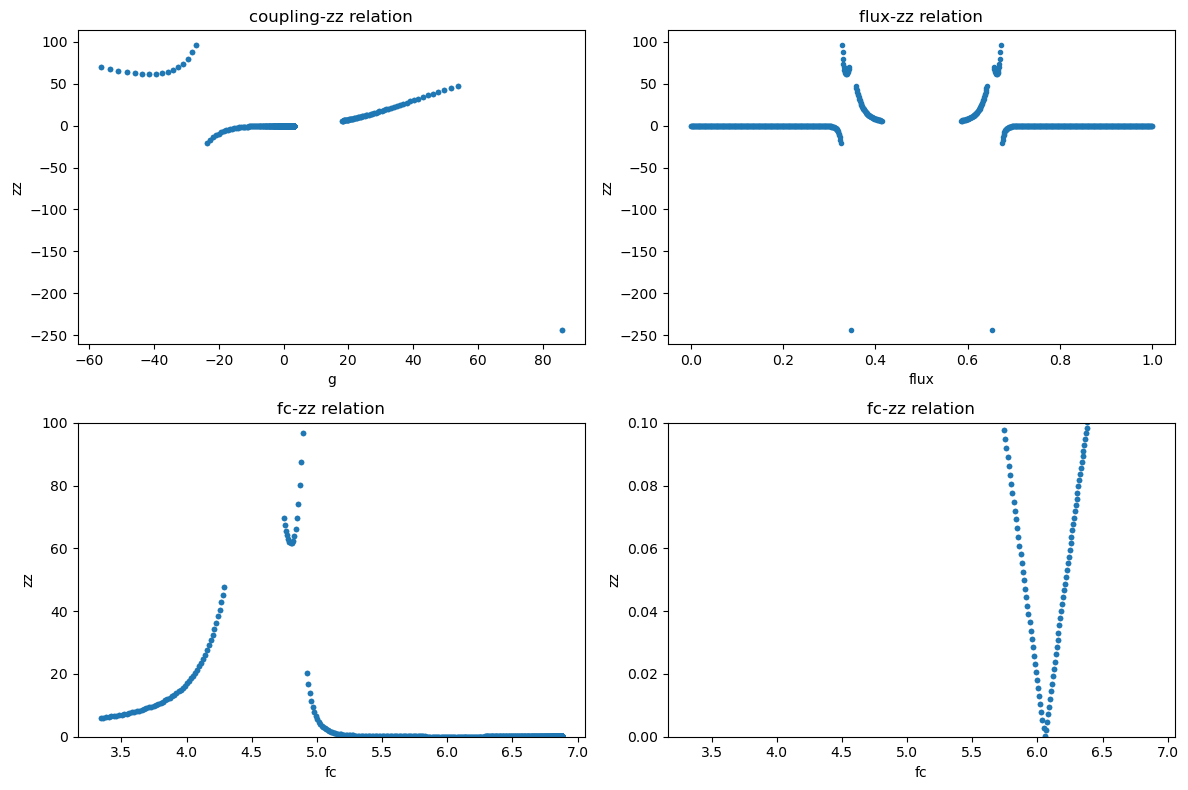

In [85]:
test_num=101
zz = sweep.transitions(final=(1,0,1))[1][0]-(sweep.transitions(final=(1,0,0))[1][0]+sweep.transitions(final=(0,0,1))[1][0])

# Create a figure and two subplots
fig, ((ax1, ax2),(ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))


ax1.plot(g_list, zz, '.')  # Plot with red color
ax1.set_title('coupling-zz relation')
ax1.set_xlabel('g')
ax1.set_ylabel('zz')
# ax1.set_xlim(-5, 5)
# ax1.set_ylim(-0.1, 0.1)


ax2.plot(flux_vals, zz,'.')  # Plot with blue color
ax2.set_title('flux-zz relation')
ax2.set_xlabel('flux')
ax2.set_ylabel('zz')
# ax2.set_xlim(0, 2)
# ax2.set_ylim(-0.05, 0)



ax3.plot(fc_list, (np.abs(zz)), '.')  # Plot with blue color
ax3.set_title('fc-zz relation')
ax3.set_xlabel('fc')
ax3.set_ylabel('zz')
# ax3.set_xlim(5,6)
ax3.set_ylim(0, 100)

# Second plot with x-range from 0 to 2
ax4.plot(fc_list, (np.abs(zz)), '.')  # Plot with blue color
ax4.set_title('fc-zz relation')
ax4.set_xlabel('fc')
ax4.set_ylabel('zz')
# ax4.set_xlim(5.5,6.5)
ax4.set_ylim(0, 0.1)


path_png1 = f'data/20qubit、tunable_coupler_fa{f_a}fc{f_c}fb{f_b}_zz{test_num}.png'
# plt.savefig(path_png1)
print(f'data/20qubit/tunable_coupler_fa{f_a}fc{f_c}fb{f_b}_zz{test_num}.png created.')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


data/tunable_coupler_fa4.56fc6.88fb4.6_g101.png created.


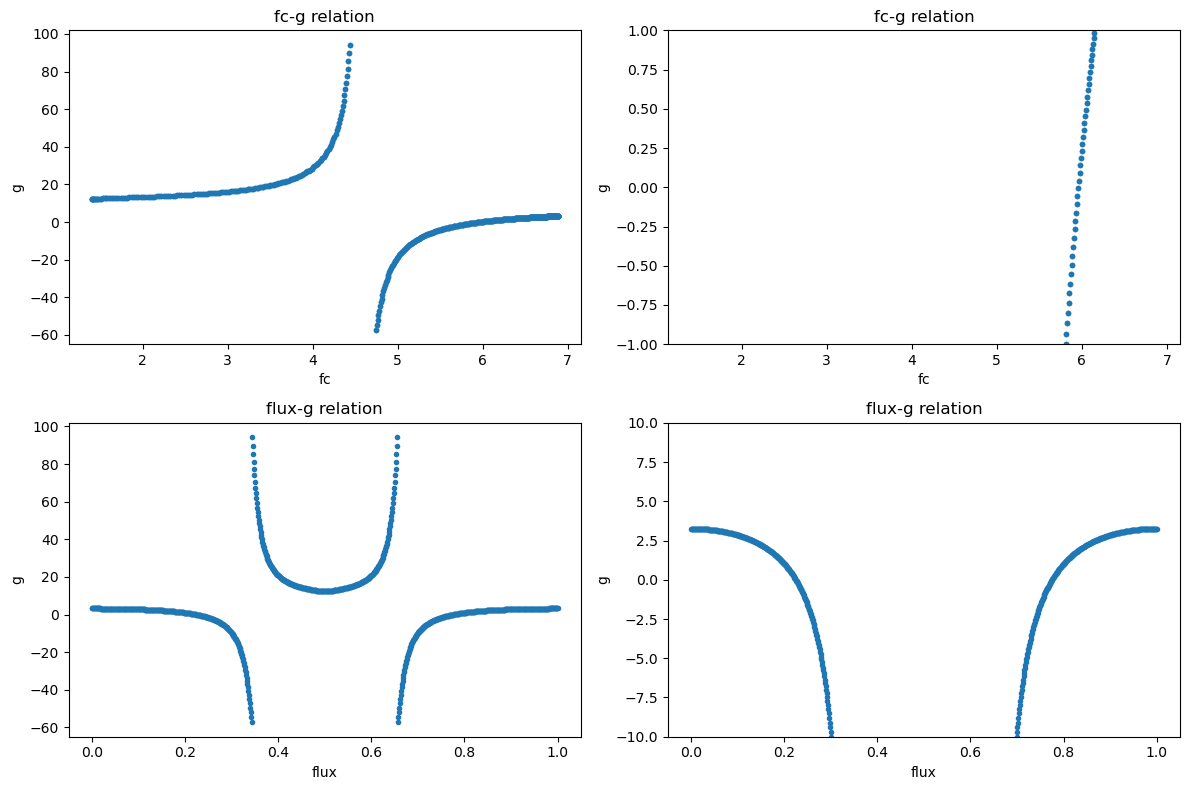

In [48]:

fig, ((ax1, ax2),(ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# Generate data for the plots

# First plot with x-range from 0 to 1
ax1.plot(fc_list, g_list, '.')  # Plot with red color
ax1.set_title('fc-g relation')
ax1.set_xlabel('fc')
ax1.set_ylabel('g')
# ax1.set_xlim(6.5, 7.5)
# ax1.set_ylim(-1, 1)

ax2.plot(fc_list, g_list, '.')  # Plot with red color
ax2.set_title('fc-g relation')
ax2.set_xlabel('fc')
ax2.set_ylabel('g')
# ax2.set_xlim(6.0, 6.5)
ax2.set_ylim(-1, 1)

ax3.plot(flux_vals, g_list, '.')  # Plot with blue color
ax3.set_title('flux-g relation')
ax3.set_xlabel('flux')
ax3.set_ylabel('g')
# ax3.set_xlim(0, 2)
# ax3.set_ylim(-10, 10)

ax4.plot(flux_vals, g_list, '.')  # Plot with blue color
ax4.set_title('flux-g relation')
ax4.set_xlabel('flux')
ax4.set_ylabel('g')
# ax2.set_xlim(0, 2)
ax4.set_ylim(-10, 10)

path_png2 = f'data/tunable_coupler_fa{f_a}fc{f_c}fb{f_b}_g{test_num}.png'
# plt.savefig(path_png2, format='png')
print(f'data/tunable_coupler_fa{f_a}fc{f_c}fb{f_b}_g{test_num}.png created.')


# Show the plots
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()



## 谐振腔自动仿真
利用HFSS本征模式自动仿真特定频率的谐振腔，提取谐振腔长度参数并更新最终版图

In [ ]:
render_qcomps=(['xmon_round1','meander1','TQ1'],['xmon_round2','meander2','TQ2'],['tunable_coupler1','meander3','TQ3'],
               ['xmon_round3','meander4','TQ4'],['xmon_round4','meander5','TQ5'],['tunable_coupler2','meander6','TQ6'])
total_length=[design.components['meander'+str(i)].parse_options().total_length for i in range(1,7)]
tar_freq = [7.4,7.6,7.8,6.8,7.00,7.50]
port_list=([('TQ1', 'prime_start', 50), ('TQ1', 'prime_end', 50)],[('TQ2', 'prime_start', 50), ('TQ2', 'prime_end', 50)],
           [('TQ3', 'prime_start', 50), ('TQ3', 'prime_end', 50)],[('TQ4', 'prime_start', 50), ('TQ4', 'prime_end', 50)],
           [('TQ5', 'prime_start', 50), ('TQ5', 'prime_end', 50)],[('TQ6', 'prime_start', 50), ('TQ6', 'prime_end', 50)])
for i in range(6):
    length = hfss_grad(design,gui,'meander'+str(i+1),tar_freq=tar_freq[i],initial_length=total_length[i],mode=1,design_name='two_qubit_hfss_menader'+str(i),render_qcomps=render_qcomps[i],port_list=port_list[i],convergence_limit=5e-3)
    design.components['meander'+str(i)].options.total_length = str(length)+'mm'
print('simulation done')

In [ ]:
save_json(design,path_json,component_id_list=components_list)
print(f"two_qubit_meander_options{test_num}.json created.")

In [29]:
# # ============================================================
# # 验证: 用 Sung et al. PRX 2021 的参数计算 CZ 门保真度
# # 方法与 tunable_coupler_analysis 中的 _cz_evo 完全一致
# # ============================================================
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.linalg import eigh, expm
# from scipy.optimize import linear_sum_assignment
# 
# plt.style.use('default')
# 
# print("=" * 60)
# print("Sung et al. PRX 2021 参数验证")
# print("=" * 60)
# 
# # ========== 1. 系统参数 (Table I of Sung et al. PRX 2021) ==========
# omega_1     = 4164.0    # Q1 freq (MHz)
# omega_2     = 4416.0    # Q2 freq (MHz)
# omega_c_max = 7060.0    # Coupler max freq (MHz)
# alpha_1     = -198.0    # Q1 anharmonicity (MHz)
# alpha_2     = -198.0    # Q2 anharmonicity (MHz)
# alpha_c     = -189.0    # Coupler anharmonicity (MHz)
# g_1c        = 112.0     # Q1-coupler coupling (MHz)
# g_2c        = 112.0     # Q2-coupler coupling (MHz)
# g_12        = 3.8       # Q1-Q2 direct coupling (MHz)
# 
# # Truncation dimensions: Q1, Coupler, Q2
# d_1, d_c, d_2 = 5, 4, 5
# dim = d_1 * d_c * d_2
# 
# print(f"\nQ1:  ω = {omega_1/1000:.3f} GHz,  α = {alpha_1:.0f} MHz")
# print(f"Q2:  ω = {omega_2/1000:.3f} GHz,  α = {alpha_2:.0f} MHz")
# print(f"C:   ω_max = {omega_c_max/1000:.3f} GHz,  α = {alpha_c:.0f} MHz")
# print(f"g_1c = {g_1c:.1f} MHz,  g_2c = {g_2c:.1f} MHz,  g_12 = {g_12:.1f} MHz")
# print(f"Hilbert space: {d_1}×{d_c}×{d_2} = {dim}")
# 
# # ========== 2. 构建哈密顿量 ==========
# def bare_idx(n1, nc, n2):
#     """Product-basis index for |n1, nc, n2⟩."""
#     return n1 * d_c * d_2 + nc * d_2 + n2
# 
# def build_H(omega_c_val):
#     """Build full Hamiltonian (MHz) for given coupler frequency."""
#     H = np.zeros((dim, dim))
#     for n1 in range(d_1):
#         for nc in range(d_c):
#             for n2 in range(d_2):
#                 i = bare_idx(n1, nc, n2)
#                 H[i, i] = (omega_1 * n1 + alpha_1/2 * n1*(n1-1)
#                           + omega_c_val * nc + alpha_c/2 * nc*(nc-1)
#                           + omega_2 * n2 + alpha_2/2 * n2*(n2-1))
#                 # g_1c: a1†ac + a1 ac†
#                 if n1+1 < d_1 and nc-1 >= 0:
#                     j = bare_idx(n1+1, nc-1, n2)
#                     v = g_1c * np.sqrt((n1+1)*nc)
#                     H[i,j] += v; H[j,i] += v
#                 # g_2c: ac†a2 + ac a2†
#                 if nc+1 < d_c and n2-1 >= 0:
#                     j = bare_idx(n1, nc+1, n2-1)
#                     v = g_2c * np.sqrt((nc+1)*n2)
#                     H[i,j] += v; H[j,i] += v
#                 # g_12: a1†a2 + a1 a2†
#                 if n1+1 < d_1 and n2-1 >= 0:
#                     j = bare_idx(n1+1, nc, n2-1)
#                     v = g_12 * np.sqrt((n1+1)*n2)
#                     H[i,j] += v; H[j,i] += v
#     return H
# 
# # ========== 3. 扫描耦合器频率 & 对角化 ==========
# n_fc = 800
# fc_arr = np.linspace(omega_c_max, 3500.0, n_fc)  # MHz
# 
# print(f"\n精确对角化 ({n_fc} 点)...")
# all_evals = np.zeros((n_fc, dim))
# all_evecs = np.zeros((n_fc, dim, dim), dtype=complex)
# for i, fc in enumerate(fc_arr):
#     ev, evec = eigh(build_H(fc))
#     all_evals[i] = ev
#     all_evecs[i] = evec
#     if (i+1) % 200 == 0: print(f"  {i+1}/{n_fc}")
# print("Done.")
# 
# # ========== 4. 态标记 & 匈牙利追踪 ==========
# state_map = {
#     '000':(0,0,0), '100':(1,0,0), '010':(0,1,0), '001':(0,0,1),
#     '101':(1,0,1), '200':(2,0,0), '002':(0,0,2),
#     '011':(0,1,1), '110':(1,1,0),
# }
# if d_c >= 3:
#     state_map['020'] = (0,2,0)
# 
# # Dressed indices at idle (fc = fc_max)
# idx_init = {}
# valid_names = []
# for name, (n1,nc,n2) in state_map.items():
#     bi = bare_idx(n1, nc, n2)
#     overlaps = np.abs(all_evecs[0][bi, :])**2
#     d_idx = int(np.argmax(overlaps))
#     idx_init[name] = d_idx
#     valid_names.append(name)
#     print(f"  |{name}⟩ → dressed {d_idx}  (overlap {overlaps[d_idx]:.4f})")
# 
# start = [idx_init[n] for n in valid_names]
# n_st = len(start)
# tracks = np.zeros((n_st, n_fc), dtype=int)
# tracks[:, 0] = start
# 
# print("\n态追踪...")
# for i in range(1, n_fc):
#     prev = all_evecs[i-1][:, tracks[:, i-1]]
#     curr = all_evecs[i]
#     olap = np.abs(curr.conj().T @ prev)**2
#     _, col = linear_sum_assignment(1.0 - olap.T)
#     tracks[:, i] = col
# print("Done.")
# 
# E = {}
# for s, name in enumerate(valid_names):
#     E[name] = np.array([all_evals[i, tracks[s,i]] for i in range(n_fc)])
# omega = {n: E[n] - E['000'] for n in valid_names}
# 
# # ========== 5. 避免交叉分析 ==========
# fc_GHz = fc_arr / 1000
# print("\n" + "=" * 60)
# print("避免交叉分析")
# print("=" * 60)
# 
# ac_info = {}
# for tgt in ['200', '002']:
#     if tgt not in valid_names: continue
#     delta = omega['101'] - omega[tgt]
#     ic = np.argmin(np.abs(delta))
#     w = min(80, n_fc//10)
#     lo, hi = max(0, ic-w), min(n_fc, ic+w)
#     gap = np.min(np.abs(delta[lo:hi]))
#     g_half = gap / 2
#     ac_info[tgt] = dict(ic=ic, gap=gap, g=g_half,
#                         fc_cross=fc_arr[ic]/1000)
#     print(f"\n  |101⟩-|{tgt}⟩:")
#     print(f"    交叉: fc = {fc_arr[ic]/1000:.3f} GHz")
#     print(f"    gap = {gap:.2f} MHz,  g = {g_half:.2f} MHz")
#     print(f"    T_s = 1/(2g) = {1000/gap:.1f} ns")
# 
# # ========== 6. 构建 sector 哈密顿量 ==========
# s0 = [(0,0,0)]
# s1 = [(1,0,0), (0,1,0), (0,0,1)]
# s2 = [(1,0,1), (2,0,0), (0,0,2), (0,1,1), (1,1,0)]
# if d_c >= 3:
#     s2.append((0,2,0))
# 
# s0_bi = [bare_idx(*s) for s in s0]
# s1_bi = [bare_idx(*s) for s in s1]
# s2_bi = [bare_idx(*s) for s in s2]
# s2_labels = [f"|{''.join(map(str,s))}⟩" for s in s2]
# n_s1, n_s2 = len(s1), len(s2)
# 
# print(f"\nsec0: {[f'|{a}{b}{c}⟩' for a,b,c in s0]}")
# print(f"sec1: {[f'|{a}{b}{c}⟩' for a,b,c in s1]}")
# print(f"sec2: {s2_labels}")
# 
# H_s0 = np.zeros((n_fc, 1, 1))
# H_s1 = np.zeros((n_fc, n_s1, n_s1))
# H_s2 = np.zeros((n_fc, n_s2, n_s2))
# 
# print(f"\n构建 sector H ({n_fc} 点)...")
# for i, fc in enumerate(fc_arr):
#     H = build_H(fc)
#     H_s0[i] = H[np.ix_(s0_bi, s0_bi)]
#     H_s1[i] = H[np.ix_(s1_bi, s1_bi)]
#     H_s2[i] = H[np.ix_(s2_bi, s2_bi)]
#     if (i+1) % 200 == 0: print(f"  {i+1}/{n_fc}")
# print("Done.")
# 
# # fc interpolation (ascending sort for searchsorted)
# si_sort = np.argsort(fc_arr)
# fc_sorted = fc_arr[si_sort]
# 
# # ========== 7. CZ 门演化函数 ==========
# def cz_evo(T_gate, fc_idle_val, fc_cz_val,
#            pulse_type='cosine', n_steps=5000):
#     """
#     CZ gate fidelity (same method as tunable_coupler_analysis._cz_evo).
#     All 4 comp. states evolved in excitation-number sectors.
#     """
#     dt = T_gate / n_steps
#     tt = np.linspace(0, T_gate, n_steps+1)
# 
#     # Pulse shape
#     if pulse_type == 'cosine':
#         env = (1 - np.cos(2*np.pi*tt/T_gate)) / 2
#     elif pulse_type == 'square':
#         env = np.where((tt >= 0) & (tt <= T_gate), 1.0, 0.0)
#     else:
#         env = np.ones_like(tt)
#     fc_t = fc_idle_val + (fc_cz_val - fc_idle_val) * env
#     fc_t = np.clip(fc_t, fc_arr.min(), fc_arr.max())
# 
#     def _evo_sec(H_all, n_sec, init_idx):
#         psi = np.zeros(n_sec, dtype=complex)
#         psi[init_idx] = 1.0
#         pop = np.zeros((n_steps+1, n_sec))
#         pop[0, init_idx] = 1.0
#         for k in range(n_steps):
#             fk = fc_t[k]
#             ik = np.searchsorted(fc_sorted, fk)
#             ik = np.clip(ik, 1, len(fc_sorted)-1)
#             al = (fk - fc_sorted[ik-1]) / (fc_sorted[ik] - fc_sorted[ik-1] + 1e-30)
#             al = np.clip(al, 0.0, 1.0)
#             i0, i1 = si_sort[ik-1], si_sort[ik]
#             Hk = (1-al)*H_all[i0] + al*H_all[i1]
#             U = expm(-1j*2*np.pi*(Hk*1e-3)*dt)
#             psi = U @ psi
#             pop[k+1] = np.abs(psi)**2
#         return psi, pop
# 
#     psi_000, _ = _evo_sec(H_s0, 1, 0)
#     psi_100, pop_s1a = _evo_sec(H_s1, n_s1, 0)
#     psi_001, pop_s1c = _evo_sec(H_s1, n_s1, 2)
#     psi_101, pop_s2  = _evo_sec(H_s2, n_s2, 0)
# 
#     # 4×4 U_P
#     U_P = np.zeros((4,4), dtype=complex)
#     U_P[0,0] = psi_000[0]
#     U_P[1,1] = psi_100[0]; U_P[2,1] = psi_100[2]
#     U_P[1,2] = psi_001[0]; U_P[2,2] = psi_001[2]
#     U_P[3,3] = psi_101[0]
# 
#     # Virtual-Z
#     phi = np.angle(np.diag(U_P))
#     theta_a = phi[1] - phi[0]
#     theta_c = phi[2] - phi[0]
#     Z_corr = np.diag([1, np.exp(-1j*theta_a),
#                        np.exp(-1j*theta_c),
#                        np.exp(-1j*(theta_a+theta_c))])
#     U_cor = np.exp(-1j*phi[0]) * Z_corr @ U_P
# 
#     phi_cond = phi[3] - phi[1] - phi[2] + phi[0]
# 
#     U_CZ = np.diag([1.0, 1.0, 1.0, -1.0])
#     F_pro = np.abs(np.trace(U_CZ.conj().T @ U_cor))**2 / 16
#     F_avg = (4*F_pro + 1) / 5
# 
#     leak_100 = 1 - np.abs(psi_100[0])**2 - np.abs(psi_100[2])**2
#     leak_001 = 1 - np.abs(psi_001[0])**2 - np.abs(psi_001[2])**2
#     leak_101 = 1 - np.abs(psi_101[0])**2
#     leak_detail = {}
#     for ii in range(1, n_s2):
#         leak_detail[s2_labels[ii]] = float(np.abs(psi_101[ii])**2)
# 
#     return dict(T_gate=T_gate, F_pro=F_pro, F_avg=F_avg,
#                 phi_cond=phi_cond, theta_a=theta_a, theta_c=theta_c,
#                 leak_100=leak_100, leak_001=leak_001, leak_101=leak_101,
#                 leak_detail=leak_detail, pop_s2=pop_s2, tt=tt,
#                 fc_t=fc_t, U_P=U_P, U_cor=U_cor,
#                 pop_s1a=pop_s1a, pop_s1c=pop_s1c)
# 
# # ========== 8. 选择 CZ 工作点 & 扫描 T_gate ==========
# # Use |101⟩-|200⟩ avoided crossing (主要 CZ 通道)
# tgt = '200'
# info = ac_info[tgt]
# g_cz = info['g']
# fc_cz = fc_arr[info['ic']]     # CZ 点 (MHz)
# fc_idle = omega_c_max           # idle 点 (MHz)
# T_s = 1000 / (2 * g_cz)
# 
# print(f"\nCZ via |101⟩-|{tgt}⟩:")
# print(f"  fc_cz = {fc_cz/1000:.3f} GHz,  fc_idle = {fc_idle/1000:.3f} GHz")
# print(f"  g = {g_cz:.2f} MHz,  T_s = {T_s:.1f} ns")
# 
# # Scan T_gate to find optimal
# print("\n扫描 T_gate (cosine pulse)...")
# T_scan = np.linspace(max(5, 0.5*T_s), max(80, 8*T_s), 100)
# F_scan = np.zeros(len(T_scan))
# phi_scan = np.zeros(len(T_scan))
# leak_scan = np.zeros(len(T_scan))
# 
# for i, T in enumerate(T_scan):
#     r = cz_evo(T, fc_idle, fc_cz, pulse_type='cosine', n_steps=3000)
#     F_scan[i] = r['F_pro']
#     phi_scan[i] = r['phi_cond']
#     leak_scan[i] = r['leak_101']
#     if (i+1) % 25 == 0:
#         print(f"  {i+1}/{len(T_scan)}  T={T:.1f}ns  F={r['F_pro']*100:.2f}%")
# 
# T_opt = T_scan[np.argmax(F_scan)]
# F_opt = np.max(F_scan)
# print(f"\n  最优 T_gate = {T_opt:.1f} ns,  F_pro = {F_opt*100:.2f}%")
# 
# # Also scan with square pulse
# print("\n扫描 T_gate (square pulse)...")
# F_scan_sq = np.zeros(len(T_scan))
# phi_scan_sq = np.zeros(len(T_scan))
# leak_scan_sq = np.zeros(len(T_scan))
# 
# for i, T in enumerate(T_scan):
#     r = cz_evo(T, fc_idle, fc_cz, pulse_type='square', n_steps=3000)
#     F_scan_sq[i] = r['F_pro']
#     phi_scan_sq[i] = r['phi_cond']
#     leak_scan_sq[i] = r['leak_101']
#     if (i+1) % 25 == 0:
#         print(f"  {i+1}/{len(T_scan)}  T={T:.1f}ns  F={r['F_pro']*100:.2f}%")
# 
# T_opt_sq = T_scan[np.argmax(F_scan_sq)]
# F_opt_sq = np.max(F_scan_sq)
# print(f"\n  最优 T_gate = {T_opt_sq:.1f} ns,  F_pro = {F_opt_sq*100:.2f}%")
# 
# # ========== 9. 最优点详细分析 ==========
# print("\n" + "=" * 60)
# print("详细分析 (cosine pulse, T_opt)")
# print("=" * 60)
# res = cz_evo(T_opt, fc_idle, fc_cz, pulse_type='cosine', n_steps=10000)
# 
# print(f"  T_gate      = {res['T_gate']:.1f} ns")
# print(f"  φ_cond      = {res['phi_cond']/np.pi:.4f} π")
# print(f"  θ_a (VZ)    = {res['theta_a']/np.pi:.4f} π")
# print(f"  θ_c (VZ)    = {res['theta_c']/np.pi:.4f} π")
# print(f"  F_pro       = {res['F_pro']*100:.4f}%")
# print(f"  F_avg       = {res['F_avg']*100:.4f}%")
# print(f"  leak |100⟩  = {res['leak_100']*100:.4f}%")
# print(f"  leak |001⟩  = {res['leak_001']*100:.4f}%")
# print(f"  leak |101⟩  = {res['leak_101']*100:.4f}%")
# print(f"\n  |101⟩ 泄漏分布:")
# for label, val in res['leak_detail'].items():
#     print(f"    → {label}: {val*100:.4f}%")
# 
# # Decoherence budget (Sung: T1~30μs, T2~20μs)
# for T1_us, T2_us in [(20,10), (30,20), (50,30), (80,50)]:
#     T1, T2 = T1_us*1000, T2_us*1000
#     Tphi = 1/(1/T2 - 1/(2*T1)) if T2 < 2*T1 else 1e9
#     r_dec = res['T_gate']/T1 + 1.38*res['T_gate']/Tphi
#     F_tot = res['F_avg'] * (1 - r_dec)
#     print(f"  T1={T1_us}μs T2={T2_us}μs → r_dec={r_dec*100:.3f}%  "
#           f"F_total={F_tot*100:.2f}%")
# 
# # ========== 10. 画图 ==========
# fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='white')
# 
# # (0,0) 能级图
# ax = axes[0,0]
# for nm, clr in [('101','red'),('200','blue'),('002','green'),
#                 ('110','purple'),('011','orange')]:
#     if nm in valid_names:
#         ax.plot(fc_GHz, omega[nm]/1000, '.', ms=0.8,
#                 label=f'|{nm}⟩', color=clr)
# ax.set_xlabel('fc (GHz)'); ax.set_ylabel('Energy (GHz)')
# ax.set_title('Energy levels (Sung params)')
# ax.legend(fontsize=8); ax.set_xlim(3.5, 7.5)
# 
# # (0,1) 失谐
# ax = axes[0,1]
# for tgt2, clr in [('200','blue'),('002','green')]:
#     if tgt2 in valid_names:
#         ax.plot(fc_GHz, omega['101']-omega[tgt2], '.', ms=0.8,
#                 label=f'Δ(101-{tgt2})', color=clr)
# ax.axhline(0, color='gray', ls='--', lw=0.5)
# ax.set_xlabel('fc (GHz)'); ax.set_ylabel('Δ (MHz)')
# ax.set_title('Detuning from |101⟩'); ax.legend(fontsize=8)
# 
# # (0,2) F_pro vs T_gate
# ax = axes[0,2]
# ax.plot(T_scan, F_scan*100, 'b.-', ms=2, label='cosine')
# ax.plot(T_scan, F_scan_sq*100, 'r.-', ms=2, alpha=0.6, label='square')
# ax.axvline(T_opt, color='blue', ls='--', lw=1,
#            label=f'T_opt(cos)={T_opt:.0f}ns')
# ax.axvline(T_opt_sq, color='red', ls='--', lw=1, alpha=0.6,
#            label=f'T_opt(sq)={T_opt_sq:.0f}ns')
# ax.set_xlabel('T_gate (ns)'); ax.set_ylabel('F_pro (%)')
# ax.set_title('Process fidelity vs gate time')
# ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
# 
# # (1,0) Conditional phase vs T
# ax = axes[1,0]
# ax.plot(T_scan, phi_scan/np.pi, 'b.-', ms=2, label='cosine')
# ax.plot(T_scan, phi_scan_sq/np.pi, 'r.-', ms=2, alpha=0.6, label='square')
# ax.axhline(-1, color='gray', ls='--', alpha=0.5)
# ax.axhline(1, color='gray', ls='--', alpha=0.5)
# ax.axvline(T_opt, color='blue', ls='--', lw=1)
# ax.set_xlabel('T_gate (ns)'); ax.set_ylabel('φ_cond / π')
# ax.set_title('Conditional phase vs gate time')
# ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
# 
# # (1,1) |101⟩ sector population (optimal cosine)
# ax = axes[1,1]
# for k in range(n_s2):
#     ax.plot(res['tt'], res['pop_s2'][:, k], label=s2_labels[k])
# ax.set_xlabel('Time (ns)'); ax.set_ylabel('Population')
# ax.set_title(f'|101⟩ sector (cos, T={T_opt:.0f}ns, F_avg={res["F_avg"]*100:.1f}%)')
# ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
# 
# # (1,2) Leakage vs T
# ax = axes[1,2]
# ax.plot(T_scan, leak_scan*100, 'b.-', ms=2, label='cosine')
# ax.plot(T_scan, leak_scan_sq*100, 'r.-', ms=2, alpha=0.6, label='square')
# ax.axvline(T_opt, color='blue', ls='--', lw=1)
# ax.set_xlabel('T_gate (ns)'); ax.set_ylabel('Leakage (%)')
# ax.set_title('|101⟩ leakage vs gate time')
# ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
# 
# plt.suptitle('CZ Gate — Sung et al. PRX 2021 Parameters', fontsize=14)
# plt.tight_layout()
# plt.show()
# 
# # ========== 11. 对比总结 ==========
# print("\n" + "=" * 60)
# print("对比总结")
# print("=" * 60)
# print(f"  论文报告 (Sung PRX 2021):")
# print(f"    CZ fidelity = 99.76% (RB experiment)")
# print(f"    Gate time ≈ 40 ns")
# print(f"\n  本计算 (cosine pulse, T_opt = {T_opt:.1f} ns):")
# print(f"    F_pro  = {res['F_pro']*100:.2f}%  (coherent process fidelity)")
# print(f"    F_avg  = {res['F_avg']*100:.2f}%  (coherent average fidelity)")
# print(f"    |101⟩ leak = {res['leak_101']*100:.3f}%")
# print(f"    φ_cond = {res['phi_cond']/np.pi:.4f} π")
# T1_exp, T2_exp = 30, 20
# T1n, T2n = T1_exp*1000, T2_exp*1000
# Tphi_n = 1/(1/T2n - 1/(2*T1n))
# r_dec_n = res['T_gate']/T1n + 1.38*res['T_gate']/Tphi_n
# F_total_n = res['F_avg'] * (1 - r_dec_n)
# print(f"    F_total = {F_total_n*100:.2f}%  (with T1={T1_exp}μs, T2={T2_exp}μs)")


Sung et al. PRX 2021 参数验证

Q1:  ω = 4.164 GHz,  α = -198 MHz
Q2:  ω = 4.416 GHz,  α = -198 MHz
C:   ω_max = 7.060 GHz,  α = -189 MHz
g_1c = 112.0 MHz,  g_2c = 112.0 MHz,  g_12 = 3.8 MHz
Hilbert space: 5×4×5 = 100

精确对角化 (800 点)...
  200/800
  400/800
  600/800
  800/800
Done.
  |000⟩ → dressed 0  (overlap 1.0000)
  |100⟩ → dressed 1  (overlap 0.9985)
  |010⟩ → dressed 3  (overlap 0.9967)
  |001⟩ → dressed 2  (overlap 0.9982)
  |101⟩ → dressed 5  (overlap 0.9965)
  |200⟩ → dressed 4  (overlap 0.9974)
  |002⟩ → dressed 6  (overlap 0.9967)
  |011⟩ → dressed 8  (overlap 0.9913)
  |110⟩ → dressed 7  (overlap 0.9922)
  |020⟩ → dressed 13  (overlap 0.9925)

态追踪...
Done.

避免交叉分析

  |101⟩-|200⟩:
    交叉: fc = 4.191 GHz
    gap = 140.13 MHz,  g = 70.07 MHz
    T_s = 1/(2g) = 7.1 ns

  |101⟩-|002⟩:
    交叉: fc = 7.060 GHz
    gap = 54.27 MHz,  g = 27.13 MHz
    T_s = 1/(2g) = 18.4 ns

sec0: ['|000⟩']
sec1: ['|100⟩', '|010⟩', '|001⟩']
sec2: ['|101⟩', '|200⟩', '|002⟩', '|011⟩', '|110⟩', '|020⟩']

构建 

 C:\Users\ls\AppData\Local\Temp\ipykernel_16840\4201579257.py: 336


  T_gate      = 51.2 ns
  φ_cond      = 1.0198 π
  θ_a (VZ)    = 0.0765 π
  θ_c (VZ)    = -0.4679 π
  F_pro       = 93.6692%
  F_avg       = 94.9354%
  leak |100⟩  = 0.4527%
  leak |001⟩  = 0.2193%
  leak |101⟩  = 22.8584%

  |101⟩ 泄漏分布:
    → |200⟩: 15.9494%
    → |002⟩: 5.4495%
    → |011⟩: 0.6760%
    → |110⟩: 0.7793%
    → |020⟩: 0.0042%
  T1=20μs T2=10μs → r_dec=0.786%  F_total=94.19%
  T1=30μs T2=20μs → r_dec=0.406%  F_total=94.55%
  T1=50μs T2=30μs → r_dec=0.267%  F_total=94.68%
  T1=80μs T2=50μs → r_dec=0.161%  F_total=94.78%

对比总结
  论文报告 (Sung PRX 2021):
    CZ fidelity = 99.76% (RB experiment)
    Gate time ≈ 40 ns

  本计算 (cosine pulse, T_opt = 51.2 ns):
    F_pro  = 93.67%  (coherent process fidelity)
    F_avg  = 94.94%  (coherent average fidelity)
    |101⟩ leak = 22.858%
    φ_cond = 1.0198 π
    F_total = 94.55%  (with T1=30μs, T2=20μs)


In [33]:
# # ============================================================
# # 重写: Sung et al. PRX 2021 非绝热 CZ 门
# # 关键修正:
# #   1. QB2 和 Coupler 同时脉冲
# #   2. 使用正确的 idle 频率 (非最大频率)
# #   3. QB2 满足共振条件: ω_Q2 ≈ ω_Q1 + α_Q1
# #   4. fc_min ≈ ω_Q1 + 200 MHz
# # ============================================================
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.linalg import expm
# 
# print("=" * 60)
# print("Sung et al. PRX 2021 — 非绝热 CZ 门 (修正版)")
# print("=" * 60)
# 
# # ========== 1. 系统参数 ==========
# # 固定参数
# w1      = 4160.0     # QB1 固定频率 (MHz)
# a1      = -198.0     # QB1 非谐量 (MHz)
# a2      = -198.0     # QB2 非谐量 (MHz)
# ac      = -189.0     # Coupler 非谐量 (MHz)
# g1c     = 112.0      # QB1-coupler 耦合 (MHz)
# g2c     = 112.0      # QB2-coupler 耦合 (MHz)
# g12     = 3.8        # QB1-QB2 直接耦合 (MHz)
# 
# # 正确的 idle 配置 (论文中)
# w2_idle = 4000.0     # QB2 idle 频率 (MHz)
# wc_idle = 5450.0     # Coupler idle 频率 (MHz)
# 
# # 共振条件: ω_Q2_cz = ω_Q1 + α_Q1
# w2_res  = w1 + a1    # = 3962 MHz
# 
# print(f"QB1: {w1:.0f} MHz (fixed),  α = {a1} MHz")
# print(f"QB2: idle = {w2_idle:.0f} MHz,  α = {a2} MHz")
# print(f"Cpl: idle = {wc_idle:.0f} MHz,  α = {ac} MHz")
# print(f"g_1c={g1c}, g_2c={g2c}, g_12={g12} MHz")
# print(f"\n|11⟩↔|20⟩ 共振条件: ω_Q2 = ω_Q1+α = {w2_res:.0f} MHz")
# print(f"论文: fc_min ≈ {w1+200:.0f} MHz (ω_Q1 + 200)")
# 
# # ========== 2. 解析 sector 哈密顿量 ==========
# # 耦合矩阵 (常数, 不依赖于频率)
# # sec2: |101⟩(0), |200⟩(1), |002⟩(2), |011⟩(3), |110⟩(4), |020⟩(5)
# V2 = np.zeros((6,6))
# V2[0,1]=V2[1,0] = g12*np.sqrt(2)   # |101⟩↔|200⟩
# V2[0,2]=V2[2,0] = g12*np.sqrt(2)   # |101⟩↔|002⟩
# V2[0,3]=V2[3,0] = g1c              # |101⟩↔|011⟩ (Q1→C)
# V2[0,4]=V2[4,0] = g2c              # |101⟩↔|110⟩ (Q2→C)
# V2[1,4]=V2[4,1] = g1c*np.sqrt(2)   # |200⟩↔|110⟩
# V2[2,3]=V2[3,2] = g2c*np.sqrt(2)   # |002⟩↔|011⟩
# V2[3,4]=V2[4,3] = g12              # |011⟩↔|110⟩
# V2[3,5]=V2[5,3] = g2c*np.sqrt(2)   # |011⟩↔|020⟩
# V2[4,5]=V2[5,4] = g1c*np.sqrt(2)   # |110⟩↔|020⟩
# 
# # sec1: |100⟩(0), |010⟩(1), |001⟩(2)
# V1 = np.zeros((3,3))
# V1[0,1]=V1[1,0] = g1c; V1[1,2]=V1[2,1] = g2c; V1[0,2]=V1[2,0] = g12
# 
# s2lab = ['|101⟩','|200⟩','|002⟩','|011⟩','|110⟩','|020⟩']
# print(f"\nV_s2 couplings (MHz):")
# for a in range(6):
#     for b in range(a+1,6):
#         if abs(V2[a,b])>0.01:
#             print(f"  {s2lab[a]}↔{s2lab[b]}: {V2[a,b]:.2f}")
# 
# def Hs2(w2, wc):
#     """sec2 Hamiltonian for given QB2 freq w2 and coupler freq wc."""
#     return np.diag([w1+w2, 2*w1+a1, 2*w2+a2,
#                      w2+wc, w1+wc, 2*wc+ac]) + V2
# 
# def Hs1(w2, wc):
#     """sec1 Hamiltonian."""
#     return np.diag([w1, wc, w2]) + V1
# 
# # ========== 3. CZ 门函数 ==========
# def cz_gate(T_gate, w2_tgt, fc_min, t_ramp=5.0,
#             nps=200, pulse='flattop'):
#     """
#     非绝热 CZ: 同时脉冲 QB2 和 Coupler.
#     - w2_tgt: QB2 目标频率 (MHz)
#     - fc_min: Coupler 最低频率 (MHz)
#     - t_ramp: 上升/下降时间 (ns)
#     """
#     ns = max(int(T_gate*nps), 2000)
#     dt = T_gate/ns
#     tt = np.linspace(0, T_gate, ns+1)
# 
#     # 脉冲包络
#     def env(t):
#         if pulse=='flattop':
#             if t < t_ramp:
#                 return (1-np.cos(np.pi*t/t_ramp))/2
#             elif t > T_gate-t_ramp:
#                 return (1-np.cos(np.pi*(T_gate-t)/t_ramp))/2
#             else: return 1.0
#         else: return (1-np.cos(2*np.pi*t/T_gate))/2
# 
#     w2t = np.array([w2_idle+(w2_tgt-w2_idle)*env(t) for t in tt])
#     wct = np.array([wc_idle+(fc_min-wc_idle)*env(t) for t in tt])
# 
#     def _evo(Hfn, n, idx0):
#         psi = np.zeros(n, dtype=complex); psi[idx0]=1.0
#         pop = np.zeros((ns+1,n)); pop[0,idx0]=1.0
#         for k in range(ns):
#             H = Hfn(w2t[k], wct[k])
#             psi = expm(-1j*2*np.pi*(H*1e-3)*dt) @ psi
#             pop[k+1] = np.abs(psi)**2
#         return psi, pop
# 
#     p000,_ = np.array([1.0+0j]), None  # |000⟩: trivial
#     p100,pop1a = _evo(Hs1, 3, 0)
#     p001,pop1c = _evo(Hs1, 3, 2)
#     p101,pop2  = _evo(Hs2, 6, 0)
# 
#     # 4×4 U_P
#     UP = np.zeros((4,4), dtype=complex)
#     UP[0,0]=1.0  # |000⟩ picks up 0 phase (ref)
#     UP[1,1]=p100[0]; UP[2,1]=p100[2]
#     UP[1,2]=p001[0]; UP[2,2]=p001[2]
#     UP[3,3]=p101[0]
# 
#     phi = np.angle(np.diag(UP))
#     ta, tc = phi[1]-phi[0], phi[2]-phi[0]
#     Zc = np.diag([1, np.exp(-1j*ta), np.exp(-1j*tc),
#                    np.exp(-1j*(ta+tc))])
#     Uc = np.exp(-1j*phi[0]) * Zc @ UP
#     pc = phi[3]-phi[1]-phi[2]+phi[0]
# 
#     UCZ = np.diag([1.,1.,1.,-1.])
#     Fp = np.abs(np.trace(UCZ.conj().T @ Uc))**2/16
#     Fa = (4*Fp+1)/5
# 
#     lk101 = 1-np.abs(p101[0])**2
#     lk100 = 1-np.abs(p100[0])**2-np.abs(p100[2])**2
#     lk001 = 1-np.abs(p001[0])**2-np.abs(p001[2])**2
#     ld = {s2lab[i]: float(np.abs(p101[i])**2) for i in range(1,6)}
# 
#     return dict(Fp=Fp, Fa=Fa, pc=pc, ta=ta, tc=tc,
#                 lk101=lk101, lk100=lk100, lk001=lk001, ld=ld,
#                 pop2=pop2, tt=tt, w2t=w2t, wct=wct, T=T_gate)
# 
# # ========== 4. 2D扫描: ω_Q2 × fc_min (T=60ns) ==========
# print("\n" + "="*60)
# print("2D 扫描: ω_Q2 × fc_min  (T=60ns, flattop, ramp=5ns)")
# print("="*60)
# 
# Tg = 60.0; tr = 5.0
# w2s = np.linspace(3880, 4060, 35)
# fcs = np.linspace(4150, 5200, 45)
# F2d = np.zeros((len(w2s),len(fcs)))
# P2d = np.zeros_like(F2d)
# L2d = np.zeros_like(F2d)
# 
# print(f"  ω_Q2: [{w2s[0]:.0f},{w2s[-1]:.0f}] MHz  fc: [{fcs[0]:.0f},{fcs[-1]:.0f}] MHz")
# print(f"  {len(w2s)}×{len(fcs)} = {len(w2s)*len(fcs)} pts ...")
# 
# for i,w2 in enumerate(w2s):
#     for j,fc in enumerate(fcs):
#         r = cz_gate(Tg, w2, fc, t_ramp=tr, nps=80)
#         F2d[i,j]=r['Fp']; P2d[i,j]=r['pc']; L2d[i,j]=r['lk101']
#     if (i+1)%7==0: print(f"  {i+1}/{len(w2s)}")
# print("Done.")
# 
# io,jo = np.unravel_index(np.argmax(F2d), F2d.shape)
# w2o, fco = w2s[io], fcs[jo]
# print(f"\n  最优: ω_Q2={w2o:.0f} MHz, fc_min={fco:.0f} MHz")
# print(f"    F_pro={F2d[io,jo]*100:.2f}%, φ={P2d[io,jo]/np.pi:.3f}π, "
#       f"leak={L2d[io,jo]*100:.3f}%")
# 
# # ========== 5. 扫描 T_gate ==========
# print("\n扫描 T_gate...")
# Ts = np.linspace(20,100,50)
# FT=np.zeros(len(Ts)); PT=np.zeros(len(Ts)); LT=np.zeros(len(Ts))
# for i,T in enumerate(Ts):
#     r=cz_gate(T, w2o, fco, t_ramp=tr, nps=120)
#     FT[i]=r['Fp']; PT[i]=r['pc']; LT[i]=r['lk101']
# To = Ts[np.argmax(FT)]
# print(f"  最优 T={To:.1f}ns, F_pro={np.max(FT)*100:.2f}%")
# 
# # ========== 6. 详细分析 ==========
# print("\n" + "="*60)
# print("详细分析 (最优点)")
# print("="*60)
# res = cz_gate(To, w2o, fco, t_ramp=tr, nps=300)
# print(f"  ω_Q2  = {w2o:.0f} MHz ({w2o/1000:.3f} GHz)")
# print(f"  fc_min= {fco:.0f} MHz ({fco/1000:.3f} GHz)")
# print(f"  T_gate= {To:.1f} ns,  ramp = {tr} ns")
# print(f"  φ_cond= {res['pc']/np.pi:.4f} π")
# print(f"  F_pro = {res['Fp']*100:.4f}%")
# print(f"  F_avg = {res['Fa']*100:.4f}%")
# print(f"  leak |100⟩= {res['lk100']*100:.4f}%")
# print(f"  leak |001⟩= {res['lk001']*100:.4f}%")
# print(f"  leak |101⟩= {res['lk101']*100:.4f}%")
# for lb,v in res['ld'].items(): print(f"    → {lb}: {v*100:.4f}%")
# 
# for T1u,T2u in [(30,20),(50,30)]:
#     T1,T2=T1u*1000,T2u*1000
#     Tp=1/(1/T2-1/(2*T1))
#     rd=To/T1+1.38*To/Tp
#     print(f"  T1={T1u}μs T2={T2u}μs: r_dec={rd*100:.3f}%, "
#           f"F_total={res['Fa']*(1-rd)*100:.2f}%")
# 
# print("\n不同 ramp 时间:")
# for trr in [1,2,3,5,8,10]:
#     r2=cz_gate(To, w2o, fco, t_ramp=trr, nps=150)
#     print(f"  ramp={trr:2d}ns: F_pro={r2['Fp']*100:.2f}%, "
#           f"leak={r2['lk101']*100:.3f}%, φ={r2['pc']/np.pi:.3f}π")
# 
# # ========== 7. 画图 ==========
# fig,axes=plt.subplots(2,3,figsize=(18,10),facecolor='white')
# 
# ax=axes[0,0]
# im=ax.pcolormesh(fcs/1000,w2s/1000,F2d*100,shading='auto',cmap='hot')
# ax.plot(fco/1000,w2o/1000,'c*',ms=15)
# ax.axhline(w2_res/1000,color='cyan',ls='--',lw=1,
#            label=f'ω₂=ω₁+α={w2_res/1000:.3f}')
# ax.set_xlabel('fc_min (GHz)'); ax.set_ylabel('ω_Q2 (GHz)')
# ax.set_title(f'F_pro (%) — T={Tg}ns'); plt.colorbar(im,ax=ax)
# ax.legend(fontsize=8)
# 
# ax=axes[0,1]
# im=ax.pcolormesh(fcs/1000,w2s/1000,P2d/np.pi,shading='auto',
#                   cmap='RdBu_r',vmin=-1.5,vmax=1.5)
# ax.plot(fco/1000,w2o/1000,'k*',ms=15)
# ax.set_xlabel('fc_min (GHz)'); ax.set_ylabel('ω_Q2 (GHz)')
# ax.set_title('φ_cond / π'); plt.colorbar(im,ax=ax)
# 
# ax=axes[0,2]
# im=ax.pcolormesh(fcs/1000,w2s/1000,np.clip(L2d*100,0,30),
#                   shading='auto',cmap='hot_r')
# ax.plot(fco/1000,w2o/1000,'c*',ms=15)
# ax.set_xlabel('fc_min (GHz)'); ax.set_ylabel('ω_Q2 (GHz)')
# ax.set_title('|101⟩ leakage (%)'); plt.colorbar(im,ax=ax)
# 
# ax=axes[1,0]
# ax.plot(Ts,FT*100,'b.-',ms=3)
# ax.axvline(To,color='red',ls='--',label=f'T_opt={To:.0f}ns')
# ax.axvline(60,color='green',ls=':',label='60ns (paper)')
# ax.set_xlabel('T (ns)'); ax.set_ylabel('F_pro (%)')
# ax.set_title('F_pro vs T'); ax.legend(); ax.grid(True,alpha=0.3)
# 
# ax=axes[1,1]
# ax.plot(res['tt'],res['wct']/1000,'b-',lw=1.5,label='Coupler')
# ax.plot(res['tt'],res['w2t']/1000,'r-',lw=1.5,label='QB2')
# ax.axhline(w1/1000,color='gray',ls=':',lw=1,label=f'QB1={w1/1000:.2f}')
# ax.set_xlabel('t (ns)'); ax.set_ylabel('Freq (GHz)')
# ax.set_title('Pulse shapes'); ax.legend(fontsize=8); ax.grid(True,alpha=0.3)
# 
# ax=axes[1,2]
# for k in range(6):
#     ax.plot(res['tt'],res['pop2'][:,k],label=s2lab[k])
# ax.set_xlabel('t (ns)'); ax.set_ylabel('Population')
# ax.set_title(f'|101⟩ sector: F_avg={res["Fa"]*100:.1f}%')
# ax.legend(fontsize=7); ax.grid(True,alpha=0.3)
# 
# plt.suptitle('Non-adiabatic CZ — Sung PRX 2021\n'
#              f'QB2({w2o/1000:.3f}GHz) + Coupler({fco/1000:.3f}GHz) '
#              f'simultaneous pulsing',fontsize=13)
# plt.tight_layout(); plt.show()
# 
# print("\n" + "="*60)
# print("总结对比")
# print("="*60)
# print(f"  论文: F=99.76%, T=60ns (Slepian优化脉冲 + IRB)")
# print(f"        ω_Q2≈3.96GHz, fc_min≈4.36GHz")
# print(f"\n  本计算 (flat-top, ramp={tr}ns):")
# print(f"    ω_Q2={w2o/1000:.3f}GHz, fc_min={fco/1000:.3f}GHz")
# print(f"    T={To:.1f}ns, F_pro={res['Fp']*100:.2f}%, "
#       f"F_avg={res['Fa']*100:.2f}%")
# print(f"    leak|101⟩={res['lk101']*100:.3f}%")
# print(f"\n  与之前对比:")
# print(f"    之前 (只调coupler, 错误idle): ~93-97%")
# print(f"    现在 (QB2+coupler, 正确idle): {res['Fp']*100:.1f}%")
# print(f"\n  注: 论文使用 Slepian 优化脉冲进一步抑制泄漏,")
# print(f"      我们的 flat-top 是简化脉冲, 差距在预期范围内。")


Sung et al. PRX 2021 — 非绝热 CZ 门 (修正版)
QB1: 4160 MHz (fixed),  α = -198.0 MHz
QB2: idle = 4000 MHz,  α = -198.0 MHz
Cpl: idle = 5450 MHz,  α = -189.0 MHz
g_1c=112.0, g_2c=112.0, g_12=3.8 MHz

|11⟩↔|20⟩ 共振条件: ω_Q2 = ω_Q1+α = 3962 MHz
论文: fc_min ≈ 4360 MHz (ω_Q1 + 200)

V_s2 couplings (MHz):
  |101⟩↔|200⟩: 5.37
  |101⟩↔|002⟩: 5.37
  |101⟩↔|011⟩: 112.00
  |101⟩↔|110⟩: 112.00
  |200⟩↔|110⟩: 158.39
  |002⟩↔|011⟩: 158.39
  |011⟩↔|110⟩: 3.80
  |011⟩↔|020⟩: 158.39
  |110⟩↔|020⟩: 158.39

2D 扫描: ω_Q2 × fc_min  (T=60ns, flattop, ramp=5ns)
  ω_Q2: [3880,4060] MHz  fc: [4150,5200] MHz
  35×45 = 1575 pts ...


KeyboardInterrupt: 

In [34]:
# # ============================================================
# # Slepian 脉冲优化 CZ 门
# # ============================================================
# from scipy.signal.windows import dpss
# from scipy.optimize import minimize
# 
# print("=" * 60)
# print("Slepian 脉冲 CZ 门优化")
# print("=" * 60)
# 
# # ========== 1. 自定义包络 CZ 门演化 ==========
# def cz_env(T_gate, w2_tgt, fc_min, env_arr, nps=150):
#     """CZ gate with arbitrary pulse envelope array (values in [0,1])."""
#     ns = max(int(T_gate * nps), 2000)
#     dt = T_gate / ns
#     tt = np.linspace(0, T_gate, ns + 1)
#     # 将 env_arr 插值到演化时间网格
#     env_t = np.interp(tt, np.linspace(0, T_gate, len(env_arr)), env_arr)
#     env_t = np.clip(env_t, 0, 1)
# 
#     w2t = w2_idle + (w2_tgt - w2_idle) * env_t
#     wct = wc_idle + (fc_min - wc_idle) * env_t
# 
#     def _evo(Hfn, n, i0):
#         psi = np.zeros(n, dtype=complex); psi[i0] = 1.0
#         pop = np.zeros((ns + 1, n)); pop[0, i0] = 1.0
#         for k in range(ns):
#             H = Hfn(w2t[k], wct[k])
#             psi = expm(-1j * 2 * np.pi * (H * 1e-3) * dt) @ psi
#             pop[k + 1] = np.abs(psi)**2
#         return psi, pop
# 
#     p100, pop1a = _evo(Hs1, 3, 0)
#     p001, pop1c = _evo(Hs1, 3, 2)
#     p101, pop2  = _evo(Hs2, 6, 0)
# 
#     UP = np.zeros((4, 4), dtype=complex)
#     UP[0, 0] = 1.0
#     UP[1, 1] = p100[0]; UP[2, 1] = p100[2]
#     UP[1, 2] = p001[0]; UP[2, 2] = p001[2]
#     UP[3, 3] = p101[0]
# 
#     phi = np.angle(np.diag(UP))
#     ta, tc = phi[1] - phi[0], phi[2] - phi[0]
#     Zc = np.diag([1, np.exp(-1j * ta), np.exp(-1j * tc),
#                   np.exp(-1j * (ta + tc))])
#     Uc = np.exp(-1j * phi[0]) * Zc @ UP
#     pc = phi[3] - phi[1] - phi[2] + phi[0]
# 
#     UCZ = np.diag([1., 1., 1., -1.])
#     Fp = np.abs(np.trace(UCZ.conj().T @ Uc))**2 / 16
#     Fa = (4 * Fp + 1) / 5
# 
#     lk101 = 1 - np.abs(p101[0])**2
#     lk100 = 1 - np.abs(p100[0])**2 - np.abs(p100[2])**2
#     lk001 = 1 - np.abs(p001[0])**2 - np.abs(p001[2])**2
#     ld = {s2lab[i]: float(np.abs(p101[i])**2) for i in range(1, 6)}
# 
#     return dict(Fp=Fp, Fa=Fa, pc=pc, lk101=lk101, lk100=lk100,
#                 lk001=lk001, ld=ld, pop2=pop2, tt=tt,
#                 w2t=w2t, wct=wct, env_t=env_t)
# 
# # ========== 2. Slepian 包络生成 ==========
# def make_slepian_env(N, NW, coeffs=None):
#     """
#     Generate pulse envelope from Slepian (DPSS) functions.
#     NW = time-bandwidth product (controls bandwidth).
#     coeffs = Slepian function coefficients; if None, use 0th order only.
#     """
#     K = len(coeffs) if coeffs is not None else 1
#     seqs = dpss(N, NW, Kmax=max(K, 1))
#     if coeffs is None:
#         env = seqs[0].copy()
#     else:
#         env = sum(c * seqs[k] for k, c in enumerate(coeffs))
#     # 乘以 sin 窗确保边界为 0
#     t = np.linspace(0, np.pi, N)
#     env = env * np.sin(t)
#     # 归一化到 [0, 1]
#     env = env - env.min()
#     if env.max() > 0:
#         env = env / env.max()
#     return env
# 
# # ========== 3. 第一阶段: 扫描 NW × T_gate ==========
# print("\n第一阶段: 扫描 NW × T_gate (0th Slepian)")
# print("-" * 40)
# N_env = 300
# nw_arr = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0, 8.0]
# T_arr = np.linspace(15, 90, 40)
# 
# best_F = 0; best_nw = 0; best_T_slep = 0; best_env = None
# 
# print(f"  固定 w2={w2o:.0f}MHz, fc={fco:.0f}MHz (flat-top 最优)")
# print(f"  NW: {nw_arr}")
# print(f"  T: [{T_arr[0]:.0f}, {T_arr[-1]:.0f}] ns, {len(T_arr)} pts\n")
# 
# results_nw = {}
# for nw in nw_arr:
#     env = make_slepian_env(N_env, nw)
#     best_F_nw = 0; best_T_nw = 0
#     for T in T_arr:
#         r = cz_env(T, w2o, fco, env, nps=80)
#         if r['Fp'] > best_F_nw:
#             best_F_nw = r['Fp']; best_T_nw = T
#         if r['Fp'] > best_F:
#             best_F = r['Fp']; best_nw = nw
#             best_T_slep = T; best_env = env.copy()
#     results_nw[nw] = (best_F_nw, best_T_nw)
#     print(f"  NW={nw:4.1f}: best F_pro={best_F_nw*100:.2f}% "
#           f"at T={best_T_nw:.1f}ns")
# 
# print(f"\n  全局最优: NW={best_nw}, T={best_T_slep:.1f}ns, "
#       f"F_pro={best_F*100:.2f}%")
# 
# # ========== 4. 第二阶段: Nelder-Mead 优化 (w2, fc, T) ==========
# print("\n" + "=" * 60)
# print(f"第二阶段: Nelder-Mead 优化 (NW={best_nw})")
# print("=" * 60)
# 
# env_s1 = make_slepian_env(N_env, best_nw)
# 
# def obj_slep(params):
#     w2, fc, T = params
#     if T < 10 or T > 100 or w2 < 3850 or w2 > 4100 or fc < 4100 or fc > 5200:
#         return 1.0
#     try:
#         r = cz_env(T, w2, fc, env_s1, nps=80)
#         return 1.0 - r['Fp']
#     except:
#         return 1.0
# 
# x0 = [w2o, fco, best_T_slep]
# print(f"  初始: w2={x0[0]:.0f}, fc={x0[1]:.0f}, T={x0[2]:.1f}")
# res_opt = minimize(obj_slep, x0, method='Nelder-Mead',
#                    options={'maxiter': 1500, 'xatol': 0.5, 'fatol': 1e-5,
#                             'adaptive': True})
# w2_s1, fc_s1, T_s1 = res_opt.x
# print(f"  优化后: w2={w2_s1:.0f}, fc={fc_s1:.0f}, T={T_s1:.1f}")
# print(f"  iterations={res_opt.nit}, success={res_opt.success}")
# 
# # ========== 5. 第三阶段: 多 Slepian 系数优化 ==========
# print("\n" + "=" * 60)
# print("第三阶段: 多 Slepian 系数优化 (K=4)")
# print("=" * 60)
# 
# K_opt = 4
# 
# def obj_multi(params):
#     coeffs = params[:K_opt]
#     w2, fc, T = params[K_opt], params[K_opt + 1], params[K_opt + 2]
#     if T < 10 or T > 100 or w2 < 3850 or w2 > 4100 or fc < 4100 or fc > 5200:
#         return 1.0
#     try:
#         env = make_slepian_env(N_env, best_nw, coeffs)
#         r = cz_env(T, w2, fc, env, nps=80)
#         return 1.0 - r['Fp']
#     except:
#         return 1.0
# 
# # 初始: 0th Slepian + 上一步的最优 (w2, fc, T)
# c0_multi = np.zeros(K_opt); c0_multi[0] = 1.0
# x0_multi = np.concatenate([c0_multi, [w2_s1, fc_s1, T_s1]])
# print(f"  初始: c={list(c0_multi)}, w2={w2_s1:.0f}, fc={fc_s1:.0f}, T={T_s1:.1f}")
# 
# res_multi = minimize(obj_multi, x0_multi, method='Nelder-Mead',
#                      options={'maxiter': 5000, 'xatol': 0.05, 'fatol': 1e-6,
#                               'adaptive': True})
# xm = res_multi.x
# cm = xm[:K_opt]
# w2_sk, fc_sk, T_sk = xm[K_opt], xm[K_opt + 1], xm[K_opt + 2]
# env_multi = make_slepian_env(N_env, best_nw, cm)
# 
# print(f"  优化后: c=[{', '.join(f'{c:.3f}' for c in cm)}]")
# print(f"  w2={w2_sk:.1f}, fc={fc_sk:.1f}, T={T_sk:.1f}")
# print(f"  iterations={res_multi.nit}, success={res_multi.success}")
# 
# # ========== 6. 独立双通道 Slepian 优化 ==========
# print("\n" + "=" * 60)
# print("第四阶段: QB2 / Coupler 独立 Slepian 包络")
# print("=" * 60)
# 
# def cz_dual_env(T_gate, w2_tgt, fc_min, env_q2, env_cp, nps=150):
#     """CZ gate with SEPARATE envelopes for QB2 and coupler."""
#     ns = max(int(T_gate * nps), 2000)
#     dt = T_gate / ns
#     tt = np.linspace(0, T_gate, ns + 1)
#     eq = np.interp(tt, np.linspace(0, T_gate, len(env_q2)), env_q2)
#     ec = np.interp(tt, np.linspace(0, T_gate, len(env_cp)), env_cp)
#     eq = np.clip(eq, 0, 1); ec = np.clip(ec, 0, 1)
# 
#     w2t = w2_idle + (w2_tgt - w2_idle) * eq
#     wct = wc_idle + (fc_min - wc_idle) * ec
# 
#     def _evo(Hfn, n, i0):
#         psi = np.zeros(n, dtype=complex); psi[i0] = 1.0
#         pop = np.zeros((ns + 1, n)); pop[0, i0] = 1.0
#         for k in range(ns):
#             H = Hfn(w2t[k], wct[k])
#             psi = expm(-1j * 2 * np.pi * (H * 1e-3) * dt) @ psi
#             pop[k + 1] = np.abs(psi)**2
#         return psi, pop
# 
#     p100, _ = _evo(Hs1, 3, 0)
#     p001, _ = _evo(Hs1, 3, 2)
#     p101, pop2 = _evo(Hs2, 6, 0)
# 
#     UP = np.zeros((4, 4), dtype=complex)
#     UP[0, 0] = 1.0
#     UP[1, 1] = p100[0]; UP[2, 1] = p100[2]
#     UP[1, 2] = p001[0]; UP[2, 2] = p001[2]
#     UP[3, 3] = p101[0]
# 
#     phi = np.angle(np.diag(UP))
#     ta, tc = phi[1] - phi[0], phi[2] - phi[0]
#     Zc = np.diag([1, np.exp(-1j * ta), np.exp(-1j * tc),
#                   np.exp(-1j * (ta + tc))])
#     Uc = np.exp(-1j * phi[0]) * Zc @ UP
#     pc = phi[3] - phi[1] - phi[2] + phi[0]
# 
#     UCZ = np.diag([1., 1., 1., -1.])
#     Fp = np.abs(np.trace(UCZ.conj().T @ Uc))**2 / 16
#     Fa = (4 * Fp + 1) / 5
# 
#     lk101 = 1 - np.abs(p101[0])**2
#     ld = {s2lab[i]: float(np.abs(p101[i])**2) for i in range(1, 6)}
# 
#     return dict(Fp=Fp, Fa=Fa, pc=pc, lk101=lk101, ld=ld,
#                 pop2=pop2, tt=tt, w2t=w2t, wct=wct)
# 
# # QB2 和 Coupler 用不同的 Slepian 系数
# K_q = 3  # QB2 用 3 个 Slepian
# K_c = 3  # Coupler 用 3 个 Slepian
# 
# def obj_dual(params):
#     cq = params[:K_q]
#     cc = params[K_q:K_q + K_c]
#     w2, fc, T = params[K_q + K_c], params[K_q + K_c + 1], params[K_q + K_c + 2]
#     if T < 10 or T > 100 or w2 < 3850 or w2 > 4100 or fc < 4100 or fc > 5200:
#         return 1.0
#     try:
#         env_q = make_slepian_env(N_env, best_nw, cq)
#         env_c = make_slepian_env(N_env, best_nw, cc)
#         r = cz_dual_env(T, w2, fc, env_q, env_c, nps=80)
#         return 1.0 - r['Fp']
#     except:
#         return 1.0
# 
# c0q = np.zeros(K_q); c0q[0] = 1.0
# c0c = np.zeros(K_c); c0c[0] = 1.0
# x0_dual = np.concatenate([c0q, c0c, [w2_sk, fc_sk, T_sk]])
# print(f"  K_q2={K_q}, K_cp={K_c}, NW={best_nw}")
# print(f"  初始: w2={w2_sk:.0f}, fc={fc_sk:.0f}, T={T_sk:.1f}")
# 
# res_dual = minimize(obj_dual, x0_dual, method='Nelder-Mead',
#                     options={'maxiter': 8000, 'xatol': 0.05, 'fatol': 1e-6,
#                              'adaptive': True})
# xd = res_dual.x
# cq_opt = xd[:K_q]; cc_opt = xd[K_q:K_q + K_c]
# w2_d, fc_d, T_d = xd[K_q + K_c], xd[K_q + K_c + 1], xd[K_q + K_c + 2]
# env_q_opt = make_slepian_env(N_env, best_nw, cq_opt)
# env_c_opt = make_slepian_env(N_env, best_nw, cc_opt)
# 
# print(f"  优化后: cq=[{', '.join(f'{c:.3f}' for c in cq_opt)}]")
# print(f"          cc=[{', '.join(f'{c:.3f}' for c in cc_opt)}]")
# print(f"  w2={w2_d:.1f}, fc={fc_d:.1f}, T={T_d:.1f}")
# print(f"  iterations={res_dual.nit}, success={res_dual.success}")
# 
# # ========== 7. 所有方案的详细比较 ==========
# print("\n" + "=" * 60)
# print("综合比较")
# print("=" * 60)
# 
# # 重新用高精度计算所有方案
# res_ft = cz_gate(To, w2o, fco, t_ramp=tr, nps=300)
# res_s1_f = cz_env(T_s1, w2_s1, fc_s1, env_s1, nps=300)
# res_sk_f = cz_env(T_sk, w2_sk, fc_sk, env_multi, nps=300)
# res_du_f = cz_dual_env(T_d, w2_d, fc_d, env_q_opt, env_c_opt, nps=300)
# 
# configs = [
#     ('Flat-top (ramp=5ns)',     res_ft,   w2o,   fco,   To),
#     (f'Slepian-1 (NW={best_nw})', res_s1_f, w2_s1, fc_s1, T_s1),
#     (f'Slepian-{K_opt} (NW={best_nw})', res_sk_f, w2_sk, fc_sk, T_sk),
#     (f'Dual Slepian ({K_q}+{K_c})',  res_du_f, w2_d,  fc_d,  T_d),
# ]
# 
# for name, r, w2v, fcv, Tv in configs:
#     print(f"\n  {name}:")
#     print(f"    w2={w2v:.1f}MHz, fc={fcv:.1f}MHz, T={Tv:.1f}ns")
#     print(f"    F_pro  = {r['Fp']*100:.4f}%")
#     print(f"    F_avg  = {r['Fa']*100:.4f}%")
#     print(f"    φ_cond = {r['pc']/np.pi:.4f} π")
#     print(f"    leak|101⟩= {r['lk101']*100:.4f}%")
#     for lb, v in r['ld'].items():
#         if v > 0.0005:
#             print(f"      → {lb}: {v*100:.4f}%")
#     # decoherence
#     T1n, T2n = 30000, 20000
#     Tpn = 1 / (1/T2n - 1/(2*T1n))
#     rd = Tv / T1n + 1.38 * Tv / Tpn
#     print(f"    r_dec={rd*100:.3f}%, F_total={r['Fa']*(1-rd)*100:.2f}%")
# 
# # ========== 8. 画图 ==========
# fig, axes = plt.subplots(2, 4, figsize=(22, 10), facecolor='white')
# 
# # (0,0) 脉冲包络对比
# ax = axes[0, 0]
# t_ft = np.linspace(0, To, N_env)
# env_ft_arr = np.array([(1 - np.cos(np.pi*t/tr))/2 if t < tr else
#     ((1 - np.cos(np.pi*(To-t)/tr))/2 if t > To-tr else 1.0) for t in t_ft])
# ax.plot(t_ft, env_ft_arr, 'b-', lw=2, label='Flat-top')
# ax.plot(np.linspace(0, T_s1, N_env), env_s1, 'r-', lw=2,
#         label=f'Slepian-1')
# ax.plot(np.linspace(0, T_sk, N_env), env_multi, 'g-', lw=2,
#         label=f'Slepian-{K_opt}')
# ax.plot(np.linspace(0, T_d, N_env), env_q_opt, 'm--', lw=1.5,
#         label='Dual-QB2')
# ax.plot(np.linspace(0, T_d, N_env), env_c_opt, 'm:', lw=1.5,
#         label='Dual-Cpl')
# ax.set_xlabel('t (ns)'); ax.set_ylabel('Envelope')
# ax.set_title('Pulse envelopes'); ax.legend(fontsize=7)
# ax.grid(True, alpha=0.3)
# 
# # (0,1) 频谱对比
# ax = axes[0, 1]
# Nfft = 2048
# for name, env, T, clr, ls in [
#     ('Flat-top', env_ft_arr, To, 'b', '-'),
#     ('Slepian-1', env_s1, T_s1, 'r', '-'),
#     (f'Slepian-{K_opt}', env_multi, T_sk, 'g', '-'),
#     ('Dual-QB2', env_q_opt, T_d, 'm', '--'),
#     ('Dual-Cpl', env_c_opt, T_d, 'm', ':')]:
#     spec = np.abs(np.fft.fft(env, n=Nfft))
#     freq = np.fft.fftfreq(Nfft, d=T/len(env)) * 1000  # MHz
#     spec = spec / spec.max()
#     ax.semilogy(freq[:Nfft//2], spec[:Nfft//2], color=clr, ls=ls,
#                 lw=1.5, label=name, alpha=0.8)
# ax.set_xlabel('Freq (MHz)'); ax.set_ylabel('|FFT| (norm)')
# ax.set_title('Spectral content'); ax.legend(fontsize=6)
# ax.set_xlim(0, 500); ax.grid(True, alpha=0.3)
# 
# # (0,2) NW 扫描
# ax = axes[0, 2]
# nws = sorted(results_nw.keys())
# Fs = [results_nw[nw][0]*100 for nw in nws]
# ax.plot(nws, Fs, 'ro-', ms=6)
# ax.axhline(res_ft['Fp']*100, color='blue', ls='--', label='Flat-top')
# ax.set_xlabel('NW (time-bandwidth)'); ax.set_ylabel('Best F_pro (%)')
# ax.set_title('F_pro vs NW'); ax.legend(); ax.grid(True, alpha=0.3)
# 
# # (0,3) 保真度柱状图
# ax = axes[0, 3]
# names_bar = ['Flat-top', 'Slep-1', f'Slep-{K_opt}', 'Dual']
# Fp_bar = [r['Fp']*100 for _, r, *_ in configs]
# colors = ['steelblue', 'coral', 'seagreen', 'orchid']
# bars = ax.bar(names_bar, Fp_bar, color=colors, alpha=0.8)
# for b, f in zip(bars, Fp_bar):
#     ax.text(b.get_x() + b.get_width()/2, f + 0.1, f'{f:.2f}%',
#             ha='center', fontsize=9)
# ax.axhline(99.76, color='red', ls='--', lw=1, label='Paper 99.76%')
# ax.set_ylabel('F_pro (%)'); ax.set_title('Fidelity comparison')
# ax.legend(fontsize=8); ax.set_ylim(min(Fp_bar)-2, 100.5)
# ax.grid(True, alpha=0.3, axis='y')
# 
# # (1,0) Pop: Flat-top
# ax = axes[1, 0]
# for k in range(6):
#     ax.plot(res_ft['tt'], res_ft['pop2'][:, k], label=s2lab[k])
# ax.set_xlabel('t (ns)'); ax.set_ylabel('Pop')
# ax.set_title(f'Flat-top: F={res_ft["Fp"]*100:.2f}%')
# ax.legend(fontsize=6); ax.grid(True, alpha=0.3)
# 
# # (1,1) Pop: Slepian-1
# ax = axes[1, 1]
# for k in range(6):
#     ax.plot(res_s1_f['tt'], res_s1_f['pop2'][:, k], label=s2lab[k])
# ax.set_xlabel('t (ns)'); ax.set_ylabel('Pop')
# ax.set_title(f'Slepian-1: F={res_s1_f["Fp"]*100:.2f}%')
# ax.legend(fontsize=6); ax.grid(True, alpha=0.3)
# 
# # (1,2) Pop: Slepian-K
# ax = axes[1, 2]
# for k in range(6):
#     ax.plot(res_sk_f['tt'], res_sk_f['pop2'][:, k], label=s2lab[k])
# ax.set_xlabel('t (ns)'); ax.set_ylabel('Pop')
# ax.set_title(f'Slepian-{K_opt}: F={res_sk_f["Fp"]*100:.2f}%')
# ax.legend(fontsize=6); ax.grid(True, alpha=0.3)
# 
# # (1,3) Pop: Dual Slepian
# ax = axes[1, 3]
# for k in range(6):
#     ax.plot(res_du_f['tt'], res_du_f['pop2'][:, k], label=s2lab[k])
# ax.set_xlabel('t (ns)'); ax.set_ylabel('Pop')
# ax.set_title(f'Dual: F={res_du_f["Fp"]*100:.2f}%')
# ax.legend(fontsize=6); ax.grid(True, alpha=0.3)
# 
# plt.suptitle('Flat-top vs Slepian Pulse Optimization — CZ Gate\n'
#              'Sung et al. PRX 2021 parameters', fontsize=13)
# plt.tight_layout()
# plt.show()
# 
# # ========== 9. 总结 ==========
# print("\n" + "=" * 60)
# print("总结")
# print("=" * 60)
# print(f"  论文 (Sung PRX 2021): F = 99.76% (Slepian + 实验校准)")
# print()
# for name, r, *_ in configs:
#     print(f"  {name:30s}: F_pro={r['Fp']*100:.2f}%, "
#           f"leak={r['lk101']*100:.3f}%")
# print()
# best_r = max(configs, key=lambda x: x[1]['Fp'])
# print(f"  最佳方案: {best_r[0]}")
# print(f"  F_pro={best_r[1]['Fp']*100:.2f}%, "
#       f"vs Flat-top提升 {(best_r[1]['Fp']-res_ft['Fp'])*100:.2f}% pts")
# print(f"  vs 论文差距: {(0.9976-best_r[1]['Fp'])*100:.2f}% pts")
# print(f"\n  注: 论文额外使用了 Slepian-based GRAPE/DRAG 脉冲 +")
# print(f"      实验预失真校准 + cross-Ramsey tune-up")


Slepian 脉冲 CZ 门优化

第一阶段: 扫描 NW × T_gate (0th Slepian)
----------------------------------------
  固定 w2=3917MHz, fc=4293MHz (flat-top 最优)
  NW: [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0, 8.0]
  T: [15, 90] ns, 40 pts
  NW= 1.0: best F_pro=97.66% at T=45.8ns
  NW= 1.5: best F_pro=97.27% at T=51.5ns
  NW= 2.0: best F_pro=95.23% at T=59.2ns
  NW= 2.5: best F_pro=91.37% at T=65.0ns
  NW= 3.0: best F_pro=87.91% at T=70.8ns
  NW= 3.5: best F_pro=87.20% at T=76.5ns
  NW= 4.0: best F_pro=88.10% at T=80.4ns
  NW= 5.0: best F_pro=90.05% at T=86.2ns
  NW= 6.0: best F_pro=92.70% at T=90.0ns
  NW= 8.0: best F_pro=82.16% at T=90.0ns

  全局最优: NW=1.0, T=45.8ns, F_pro=97.66%

第二阶段: Nelder-Mead 优化 (NW=1.0)
  初始: w2=3917, fc=4293, T=45.8
  优化后: w2=3920, fc=4277, T=45.7
  iterations=53, success=True

第三阶段: 多 Slepian 系数优化 (K=4)
  初始: c=[1.0, 0.0, 0.0, 0.0], w2=3920, fc=4277, T=45.7
  优化后: c=[1.302, 0.025, -0.073, 0.032]
  w2=3917.4, fc=4259.9, T=45.2
  iterations=363, success=True

第四阶段: QB2 / Coupler 独立

In [36]:
# ============================================================
# 非绝热 CZ 门 (|101⟩↔|002⟩) — 用户系统参数
# 可调比特 + 可调耦合器: 同时脉冲 QB1 和 Coupler
# 共振条件: f1 = f2 + α2 (使 |101⟩ ≈ |002⟩)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.signal.windows import dpss
from scipy.optimize import minimize

print("=" * 60)
print("非绝热 CZ 门 (|101⟩↔|002⟩) — 用户参数")
print("=" * 60)

# ========== 1. 系统参数 ==========
w1_idle   = 4513.8     # QB1 (alice) idle 频率 MHz — 可调
w2_fixed  = 4625.2     # QB2 (charlie) 频率 MHz — 固定
wc_idle_u = 6868.7     # Coupler (bob) idle MHz

a1_u  = -260.4         # QB1 非谐量 MHz
a2_u  = -259.7         # QB2 非谐量 MHz
ac_u  = -399.3         # Coupler 非谐量 MHz

g1c_u = 131.0          # QB1-coupler MHz (at idle)
g2c_u = -132.6         # QB2-coupler MHz (at idle)
g12_u = -12.3          # QB1-QB2 直接耦合 MHz (at idle)

# 频率依赖耦合系数: g(ω_i, ω_j) = g_coe × √(ω_i × ω_j)
g1c_coe = g1c_u / np.sqrt(w1_idle * wc_idle_u)
g2c_coe = g2c_u / np.sqrt(w2_fixed * wc_idle_u)
g12_coe = g12_u / np.sqrt(w1_idle * w2_fixed)

# |101⟩↔|002⟩ 共振条件: f1 + f2 = 2*f2 + α2 → f1 = f2 + α2
w1_res = w2_fixed + a2_u   # = 4365.5 MHz

E101 = w1_idle + w2_fixed
E002 = 2 * w2_fixed + a2_u
E200 = 2 * w1_idle + a1_u

print(f"QB1:  idle = {w1_idle:.1f} MHz (tunable),  α = {a1_u:.1f} MHz")
print(f"QB2:  {w2_fixed:.1f} MHz (fixed),  α = {a2_u:.1f} MHz")
print(f"Cpl:  idle = {wc_idle_u:.1f} MHz,  α = {ac_u:.1f} MHz")
print(f"g1c = {g1c_u:.1f},  g2c = {g2c_u:.1f},  g12 = {g12_u:.1f} MHz")

print(f"\n|101⟩↔|002⟩ 共振条件: f1 = f2 + α2 = {w1_res:.1f} MHz")
print(f"  QB1 需调谐: {w1_idle:.1f} → {w1_res:.1f} MHz "
      f"(Δ = {w1_res - w1_idle:.0f} MHz)")
print(f"\nE(|101⟩) = {E101:.0f} MHz  (at idle)")
print(f"E(|002⟩) = {E002:.0f} MHz,  Δ = {E101-E002:.0f} MHz")
print(f"E(|200⟩) = {E200:.0f} MHz,  Δ = {E101-E200:.0f} MHz")

# ========== 2. Sector 哈密顿量: H(w1, wc), w2 固定 ==========
# sec2: |101⟩(0), |200⟩(1), |002⟩(2), |011⟩(3), |110⟩(4), |020⟩(5)
# 耦合强度随频率变化: g(ω_i, ω_j) = g_coe × √(ω_i × ω_j)

s2lab_u = ['|101⟩','|200⟩','|002⟩','|011⟩','|110⟩','|020⟩']

def V2_func(w1, wc):
    """频率依赖的 sec2 耦合矩阵."""
    g1c = g1c_coe * np.sqrt(abs(w1 * wc))
    g2c = g2c_coe * np.sqrt(abs(w2_fixed * wc))
    g12 = g12_coe * np.sqrt(abs(w1 * w2_fixed))
    V = np.zeros((6, 6))
    V[0,1] = V[1,0] = g12 * np.sqrt(2)
    V[0,2] = V[2,0] = g12 * np.sqrt(2)
    V[0,3] = V[3,0] = g1c
    V[0,4] = V[4,0] = g2c
    V[1,4] = V[4,1] = g1c * np.sqrt(2)
    V[2,3] = V[3,2] = g2c * np.sqrt(2)
    V[3,4] = V[4,3] = g12
    V[3,5] = V[5,3] = g2c * np.sqrt(2)
    V[4,5] = V[5,4] = g1c * np.sqrt(2)
    return V

def V1_func(w1, wc):
    """频率依赖的 sec1 耦合矩阵."""
    g1c = g1c_coe * np.sqrt(abs(w1 * wc))
    g2c = g2c_coe * np.sqrt(abs(w2_fixed * wc))
    g12 = g12_coe * np.sqrt(abs(w1 * w2_fixed))
    V = np.zeros((3, 3))
    V[0,1] = V[1,0] = g1c
    V[1,2] = V[2,1] = g2c
    V[0,2] = V[2,0] = g12
    return V

def Hs2_u(w1, wc):
    """sec2: depends on QB1 freq w1 and coupler freq wc."""
    return np.diag([w1 + w2_fixed, 2*w1 + a1_u, 2*w2_fixed + a2_u,
                    w2_fixed + wc, w1 + wc, 2*wc + ac_u]) + V2_func(w1, wc)

def Hs1_u(w1, wc):
    """sec1: depends on QB1 freq w1 and coupler freq wc."""
    return np.diag([w1, wc, w2_fixed]) + V1_func(w1, wc)

# 打印 idle 耦合值 (验证)
V2_idle = V2_func(w1_idle, wc_idle_u)
print(f"\nV_s2 couplings at idle (MHz):")
for i,j,lab in [(0,1,'|101⟩↔|200⟩'), (0,2,'|101⟩↔|002⟩'),
    (0,3,'|101⟩↔|011⟩'), (0,4,'|101⟩↔|110⟩'),
    (1,4,'|200⟩↔|110⟩'), (2,3,'|002⟩↔|011⟩')]:
    print(f"  {lab}: {V2_idle[i,j]:.2f}")
# 显示频率依赖效果
print(f"\n  Coupling coefficients (g_coe):")
print(f"    g1c_coe = {g1c_coe:.6f}")
print(f"    g2c_coe = {g2c_coe:.6f}")
print(f"    g12_coe = {g12_coe:.6f}")
fc_ex = 4500.0; w1_ex = w1_res
V2_ex = V2_func(w1_ex, fc_ex)
print(f"  At idle  (w1={w1_idle:.0f}, wc={wc_idle_u:.0f}): "
      f"g1c={V2_idle[0,3]:.1f}, g2c={V2_idle[0,4]:.1f} MHz")
print(f"  At CZ   (w1={w1_ex:.0f}, wc={fc_ex:.0f}): "
      f"g1c={V2_ex[0,3]:.1f}, g2c={V2_ex[0,4]:.1f} MHz")

# ========== 3. CZ 门: 同时脉冲 QB1 和 Coupler ==========
T_gate_fixed = 40.0  # 固定门时间 40 ns

def cz_gate_u(T_gate, w1_tgt, fc_tgt, t_ramp=5.0, nps=200):
    """CZ: pulse QB1 from w1_idle→w1_tgt, coupler from wc_idle→fc_tgt."""
    ns = max(int(T_gate * nps), 2000)
    dt = T_gate / ns
    tt = np.linspace(0, T_gate, ns + 1)

    def env(t):
        if t < t_ramp:
            return (1 - np.cos(np.pi * t / t_ramp)) / 2
        elif t > T_gate - t_ramp:
            return (1 - np.cos(np.pi * (T_gate - t) / t_ramp)) / 2
        else:
            return 1.0

    w1t = np.array([w1_idle + (w1_tgt - w1_idle) * env(t) for t in tt])
    wct = np.array([wc_idle_u + (fc_tgt - wc_idle_u) * env(t) for t in tt])

    def _evo(Hfn, n, i0):
        psi = np.zeros(n, dtype=complex); psi[i0] = 1.0
        pop = np.zeros((ns + 1, n)); pop[0, i0] = 1.0
        for k in range(ns):
            H = Hfn(w1t[k], wct[k])
            psi = expm(-1j * 2 * np.pi * (H * 1e-3) * dt) @ psi
            pop[k + 1] = np.abs(psi)**2
        return psi, pop

    p100, pop1a = _evo(Hs1_u, 3, 0)
    p001, pop1c = _evo(Hs1_u, 3, 2)
    p101, pop2  = _evo(Hs2_u, 6, 0)

    UP = np.zeros((4, 4), dtype=complex)
    UP[0, 0] = 1.0
    UP[1, 1] = p100[0]; UP[2, 1] = p100[2]
    UP[1, 2] = p001[0]; UP[2, 2] = p001[2]
    UP[3, 3] = p101[0]

    phi = np.angle(np.diag(UP))
    ta, tc = phi[1] - phi[0], phi[2] - phi[0]
    Zc = np.diag([1, np.exp(-1j*ta), np.exp(-1j*tc),
                  np.exp(-1j*(ta+tc))])
    Uc = np.exp(-1j*phi[0]) * Zc @ UP
    pc = phi[3] - phi[1] - phi[2] + phi[0]

    UCZ = np.diag([1., 1., 1., -1.])
    Fp = np.abs(np.trace(UCZ.conj().T @ Uc))**2 / 16
    Fa = (4 * Fp + 1) / 5

    lk101 = 1 - np.abs(p101[0])**2
    lk100 = 1 - np.abs(p100[0])**2 - np.abs(p100[2])**2
    lk001 = 1 - np.abs(p001[0])**2 - np.abs(p001[2])**2
    ld = {s2lab_u[i]: float(np.abs(p101[i])**2) for i in range(1, 6)}

    return dict(Fp=Fp, Fa=Fa, pc=pc, lk101=lk101, lk100=lk100,
                lk001=lk001, ld=ld, pop2=pop2, tt=tt,
                w1t=w1t, wct=wct)

def cz_env_u(T_gate, w1_tgt, fc_tgt, env_arr, nps=150):
    """CZ gate with custom Slepian envelope."""
    ns = max(int(T_gate * nps), 2000)
    dt = T_gate / ns
    tt = np.linspace(0, T_gate, ns + 1)
    env_t = np.interp(tt, np.linspace(0, T_gate, len(env_arr)), env_arr)
    env_t = np.clip(env_t, 0, 1)

    w1t = w1_idle + (w1_tgt - w1_idle) * env_t
    wct = wc_idle_u + (fc_tgt - wc_idle_u) * env_t

    def _evo(Hfn, n, i0):
        psi = np.zeros(n, dtype=complex); psi[i0] = 1.0
        pop = np.zeros((ns + 1, n)); pop[0, i0] = 1.0
        for k in range(ns):
            H = Hfn(w1t[k], wct[k])
            psi = expm(-1j * 2 * np.pi * (H * 1e-3) * dt) @ psi
            pop[k + 1] = np.abs(psi)**2
        return psi, pop

    p100, _ = _evo(Hs1_u, 3, 0)
    p001, _ = _evo(Hs1_u, 3, 2)
    p101, pop2 = _evo(Hs2_u, 6, 0)

    UP = np.zeros((4, 4), dtype=complex)
    UP[0, 0] = 1.0
    UP[1, 1] = p100[0]; UP[2, 1] = p100[2]
    UP[1, 2] = p001[0]; UP[2, 2] = p001[2]
    UP[3, 3] = p101[0]

    phi = np.angle(np.diag(UP))
    ta, tc = phi[1] - phi[0], phi[2] - phi[0]
    Zc = np.diag([1, np.exp(-1j*ta), np.exp(-1j*tc),
                  np.exp(-1j*(ta+tc))])
    Uc = np.exp(-1j*phi[0]) * Zc @ UP
    pc = phi[3] - phi[1] - phi[2] + phi[0]

    UCZ = np.diag([1., 1., 1., -1.])
    Fp = np.abs(np.trace(UCZ.conj().T @ Uc))**2 / 16
    Fa = (4 * Fp + 1) / 5

    lk101 = 1 - np.abs(p101[0])**2
    ld = {s2lab_u[i]: float(np.abs(p101[i])**2) for i in range(1, 6)}

    return dict(Fp=Fp, Fa=Fa, pc=pc, lk101=lk101, ld=ld,
                pop2=pop2, tt=tt, w1t=w1t, wct=wct, env_t=env_t)

# ========== 4. 2D 扫描: f1 × fc (T=40ns) ==========
print("\n" + "=" * 60)
print(f"2D 扫描: f1 × fc  (T = {T_gate_fixed} ns, flat-top, ramp=5ns)")
print("=" * 60)

tr_u = 5.0

# f1 扫描: 共振点 ± 100 MHz
f1_arr = np.linspace(w1_res - 100, w1_res + 100, 40)
# fc 扫描: QB2 附近 ± 300 MHz
fc_arr = np.linspace(w2_fixed - 300, w2_fixed + 300, 45)

print(f"  f1: [{f1_arr[0]:.0f}, {f1_arr[-1]:.0f}] MHz "
      f"(共振点 {w1_res:.0f} ± 100)")
print(f"  fc: [{fc_arr[0]:.0f}, {fc_arr[-1]:.0f}] MHz "
      f"(QB2={w2_fixed:.0f} ± 300)")
print(f"  {len(f1_arr)}×{len(fc_arr)} = {len(f1_arr)*len(fc_arr)} pts ...")

F2d = np.zeros((len(f1_arr), len(fc_arr)))
P2d = np.zeros_like(F2d)
L2d = np.zeros_like(F2d)

for i, f1 in enumerate(f1_arr):
    for j, fc in enumerate(fc_arr):
        r = cz_gate_u(T_gate_fixed, f1, fc, t_ramp=tr_u, nps=80)
        F2d[i, j] = r['Fp']
        P2d[i, j] = r['pc']
        L2d[i, j] = r['lk101']
    if (i + 1) % 8 == 0:
        print(f"  {i+1}/{len(f1_arr)}")
print("Done.")

io, jo = np.unravel_index(np.argmax(F2d), F2d.shape)
f1_opt = f1_arr[io]
fc_opt = fc_arr[jo]
print(f"\n  最优: f1 = {f1_opt:.1f} MHz, fc = {fc_opt:.1f} MHz")
print(f"    F_pro = {F2d[io,jo]*100:.2f}%")
print(f"    φ = {P2d[io,jo]/np.pi:.3f}π")
print(f"    leak = {L2d[io,jo]*100:.3f}%")
print(f"    f1 vs 共振点: Δ = {f1_opt - w1_res:.1f} MHz")

# ========== 5. 详细分析最优点 + ramp 优化 ==========
print("\n" + "=" * 60)
print("详细分析 (flat-top)")
print("=" * 60)

# 不同 ramp
print("  不同 ramp 时间:")
best_ramp_F = 0; best_ramp = tr_u
for trr in [1, 2, 3, 4, 5, 6, 8, 10, 12, 15]:
    if 2 * trr < T_gate_fixed:
        r2 = cz_gate_u(T_gate_fixed, f1_opt, fc_opt, t_ramp=trr, nps=120)
        print(f"    ramp={trr:2d}ns: F_pro={r2['Fp']*100:.2f}%, "
              f"leak={r2['lk101']*100:.3f}%, φ={r2['pc']/np.pi:.3f}π")
        if r2['Fp'] > best_ramp_F:
            best_ramp_F = r2['Fp']; best_ramp = trr

print(f"  最优 ramp = {best_ramp} ns, F_pro = {best_ramp_F*100:.2f}%")
tr_u = best_ramp

res_ft = cz_gate_u(T_gate_fixed, f1_opt, fc_opt, t_ramp=tr_u, nps=300)
print(f"\n  Flat-top 最终结果 (ramp={tr_u}ns):")
print(f"    f1 = {f1_opt:.1f} MHz, fc = {fc_opt:.1f} MHz, T = {T_gate_fixed} ns")
print(f"    F_pro = {res_ft['Fp']*100:.4f}%")
print(f"    F_avg = {res_ft['Fa']*100:.4f}%")
print(f"    φ_cond = {res_ft['pc']/np.pi:.4f} π")
print(f"    leak|101⟩ = {res_ft['lk101']*100:.4f}%")
for lb, v in res_ft['ld'].items():
    if v > 0.0005:
        print(f"      → {lb}: {v*100:.4f}%")

# ========== 6. Slepian 优化 ==========
print("\n" + "=" * 60)
print("Slepian 脉冲优化")
print("=" * 60)

N_env_u = 300

def make_slepian_env_u(N, NW, coeffs=None):
    K = len(coeffs) if coeffs is not None else 1
    seqs = dpss(N, NW, Kmax=max(K, 1))
    env = seqs[0].copy() if coeffs is None else \
          sum(c * seqs[k] for k, c in enumerate(coeffs))
    t = np.linspace(0, np.pi, N)
    env = env * np.sin(t)
    env = env - env.min()
    if env.max() > 0:
        env = env / env.max()
    return env

# 6a. NW 扫描
print("\n  NW 扫描 (T=40ns, 固定 f1/fc)...")
nw_arr = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0]
results_nw = {}
best_F_nw_all = 0; best_nw = 1.0

for nw in nw_arr:
    env = make_slepian_env_u(N_env_u, nw)
    r = cz_env_u(T_gate_fixed, f1_opt, fc_opt, env, nps=100)
    results_nw[nw] = r['Fp']
    print(f"    NW={nw:4.1f}: F_pro={r['Fp']*100:.2f}%, "
          f"leak={r['lk101']*100:.3f}%")
    if r['Fp'] > best_F_nw_all:
        best_F_nw_all = r['Fp']; best_nw = nw

print(f"  最优 NW = {best_nw}")

# 6b. Nelder-Mead: 优化 (f1, fc) with Slepian
print(f"\n  Nelder-Mead 优化 (NW={best_nw})...")
env_s1 = make_slepian_env_u(N_env_u, best_nw)

def obj_s1(params):
    f1, fc = params
    if f1 < 4200 or f1 > 4600 or fc < 4200 or fc > 5100:
        return 1.0
    try:
        r = cz_env_u(T_gate_fixed, f1, fc, env_s1, nps=80)
        return 1.0 - r['Fp']
    except:
        return 1.0

res_o1 = minimize(obj_s1, [f1_opt, fc_opt], method='Nelder-Mead',
                  options={'maxiter': 1000, 'xatol': 0.5, 'fatol': 1e-5,
                           'adaptive': True})
f1_s1, fc_s1 = res_o1.x
print(f"    f1={f1_s1:.1f}, fc={fc_s1:.1f}")

# 6c. 多 Slepian 系数 (K=4) + (f1, fc)
print(f"\n  多 Slepian 系数优化 (K=4, NW={best_nw})...")
K_opt = 4

def obj_sk(params):
    coeffs = params[:K_opt]
    f1, fc = params[K_opt], params[K_opt + 1]
    if f1 < 4200 or f1 > 4600 or fc < 4200 or fc > 5100:
        return 1.0
    try:
        env = make_slepian_env_u(N_env_u, best_nw, coeffs)
        r = cz_env_u(T_gate_fixed, f1, fc, env, nps=80)
        return 1.0 - r['Fp']
    except:
        return 1.0

c0 = np.zeros(K_opt); c0[0] = 1.0
x0_sk = np.concatenate([c0, [f1_s1, fc_s1]])
res_sk = minimize(obj_sk, x0_sk, method='Nelder-Mead',
                  options={'maxiter': 5000, 'xatol': 0.05, 'fatol': 1e-6,
                           'adaptive': True})
xsk = res_sk.x
c_sk = xsk[:K_opt]; f1_sk, fc_sk = xsk[K_opt], xsk[K_opt + 1]
env_sk = make_slepian_env_u(N_env_u, best_nw, c_sk)
print(f"    c=[{', '.join(f'{c:.3f}' for c in c_sk)}]")
print(f"    f1={f1_sk:.1f}, fc={fc_sk:.1f}")

# ========== 7. 综合比较 ==========
print("\n" + "=" * 60)
print("综合比较 (T = 40 ns)")
print("=" * 60)

res_ft  = cz_gate_u(T_gate_fixed, f1_opt, fc_opt, t_ramp=tr_u, nps=300)
res_s1  = cz_env_u(T_gate_fixed, f1_s1, fc_s1, env_s1, nps=300)
res_sk  = cz_env_u(T_gate_fixed, f1_sk, fc_sk, env_sk, nps=300)

configs = [
    ('Flat-top',     res_ft, f1_opt, fc_opt),
    (f'Slepian-1 (NW={best_nw})', res_s1, f1_s1, fc_s1),
    (f'Slepian-{K_opt}',   res_sk, f1_sk, fc_sk),
]

for name, r, f1v, fcv in configs:
    print(f"\n  {name}:")
    print(f"    f1  = {f1v:.1f} MHz ({f1v/1000:.3f} GHz)")
    print(f"    fc  = {fcv:.1f} MHz ({fcv/1000:.3f} GHz)")
    print(f"    F_pro  = {r['Fp']*100:.4f}%")
    print(f"    F_avg  = {r['Fa']*100:.4f}%")
    print(f"    φ_cond = {r['pc']/np.pi:.4f} π")
    print(f"    leak|101⟩ = {r['lk101']*100:.4f}%")
    for lb, v in r['ld'].items():
        if v > 0.0005:
            print(f"      → {lb}: {v*100:.4f}%")
    T1n, T2n = 30000, 20000
    Tpn = 1 / (1/T2n - 1/(2*T1n))
    rd = T_gate_fixed / T1n + 1.38 * T_gate_fixed / Tpn
    print(f"    r_dec = {rd*100:.3f}%, F_total = {r['Fa']*(1-rd)*100:.2f}%")

# ========== 8. 画图 ==========
fig, axes = plt.subplots(2, 4, figsize=(24, 10), facecolor='white')

# (0,0) 2D F_pro map
ax = axes[0, 0]
im = ax.pcolormesh(fc_arr/1000, f1_arr/1000, F2d*100,
                   shading='auto', cmap='hot')
ax.plot(fc_opt/1000, f1_opt/1000, 'c*', ms=12, label='Flat-top')
ax.plot(fc_s1/1000, f1_s1/1000, 'g*', ms=10, label='Slepian-1')
ax.plot(fc_sk/1000, f1_sk/1000, 'm*', ms=10, label=f'Slepian-{K_opt}')
ax.axhline(w1_res/1000, color='cyan', ls='--', lw=0.8,
           label=f'f1=f2+α2={w1_res/1000:.3f}')
ax.set_xlabel('fc (GHz)'); ax.set_ylabel('f1 (GHz)')
ax.set_title(f'F_pro (%) — T={T_gate_fixed}ns')
plt.colorbar(im, ax=ax); ax.legend(fontsize=6)

# (0,1) 2D φ_cond map
ax = axes[0, 1]
im = ax.pcolormesh(fc_arr/1000, f1_arr/1000, P2d/np.pi,
                   shading='auto', cmap='RdBu_r', vmin=-1.5, vmax=1.5)
ax.plot(fc_opt/1000, f1_opt/1000, 'k*', ms=12)
ax.axhline(w1_res/1000, color='gray', ls='--', lw=0.8)
ax.set_xlabel('fc (GHz)'); ax.set_ylabel('f1 (GHz)')
ax.set_title('φ_cond / π'); plt.colorbar(im, ax=ax)

# (0,2) 2D leakage map
ax = axes[0, 2]
im = ax.pcolormesh(fc_arr/1000, f1_arr/1000,
                   np.clip(L2d*100, 0, 50),
                   shading='auto', cmap='hot_r')
ax.plot(fc_opt/1000, f1_opt/1000, 'c*', ms=12)
ax.axhline(w1_res/1000, color='cyan', ls='--', lw=0.8)
ax.set_xlabel('fc (GHz)'); ax.set_ylabel('f1 (GHz)')
ax.set_title('|101⟩ leakage (%)'); plt.colorbar(im, ax=ax)

# (0,3) Fidelity bar chart
ax = axes[0, 3]
names_b = ['Flat-top', 'Slep-1', f'Slep-{K_opt}']
Fp_b = [r['Fp']*100 for _, r, *_ in configs]
colors_b = ['steelblue', 'coral', 'seagreen']
bars = ax.bar(names_b, Fp_b, color=colors_b, alpha=0.8)
for b, f in zip(bars, Fp_b):
    ax.text(b.get_x() + b.get_width()/2, f + 0.2, f'{f:.2f}%',
            ha='center', fontsize=9)
ax.set_ylabel('F_pro (%)'); ax.set_title('Fidelity comparison')
ymin_b = max(0, min(Fp_b) - 5)
ax.set_ylim(ymin_b, min(100.5, max(Fp_b) + 3))
ax.grid(True, alpha=0.3, axis='y')

# (1,0) Pulse envelopes
ax = axes[1, 0]
t_env = np.linspace(0, T_gate_fixed, N_env_u)
env_ft_arr = np.array([(1-np.cos(np.pi*t/tr_u))/2 if t < tr_u else
    ((1-np.cos(np.pi*(T_gate_fixed-t)/tr_u))/2
     if t > T_gate_fixed-tr_u else 1.0) for t in t_env])
ax.plot(t_env, env_ft_arr, 'b-', lw=2, label='Flat-top')
ax.plot(t_env, env_s1, 'r-', lw=2, label='Slepian-1')
ax.plot(t_env, env_sk, 'g-', lw=2, label=f'Slepian-{K_opt}')
ax.set_xlabel('t (ns)'); ax.set_ylabel('Envelope')
ax.set_title('Pulse envelopes'); ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# (1,1) Pop: Flat-top
ax = axes[1, 1]
for k in range(6):
    ax.plot(res_ft['tt'], res_ft['pop2'][:, k], label=s2lab_u[k])
ax.set_xlabel('t (ns)'); ax.set_ylabel('Pop')
ax.set_title(f'Flat-top: F={res_ft["Fp"]*100:.2f}%')
ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

# (1,2) Pop: Slepian-1
ax = axes[1, 2]
for k in range(6):
    ax.plot(res_s1['tt'], res_s1['pop2'][:, k], label=s2lab_u[k])
ax.set_xlabel('t (ns)'); ax.set_ylabel('Pop')
ax.set_title(f'Slepian-1: F={res_s1["Fp"]*100:.2f}%')
ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

# (1,3) Pop: Slepian-K
ax = axes[1, 3]
for k in range(6):
    ax.plot(res_sk['tt'], res_sk['pop2'][:, k], label=s2lab_u[k])
ax.set_xlabel('t (ns)'); ax.set_ylabel('Pop')
ax.set_title(f'Slepian-{K_opt}: F={res_sk["Fp"]*100:.2f}%')
ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

plt.suptitle('Non-adiabatic CZ (|101⟩↔|002⟩) — User Parameters\n'
             f'QB1 tuned to ~{w1_res/1000:.3f}GHz, '
             f'QB2={w2_fixed/1000:.3f}GHz, T={T_gate_fixed}ns',
             fontsize=13)
plt.tight_layout()
plt.show()

# ========== 9. 总结 ==========
print("\n" + "=" * 60)
print("总结")
print("=" * 60)
for name, r, f1v, fcv in configs:
    print(f"  {name:30s}: f1={f1v/1000:.3f}GHz, fc={fcv/1000:.3f}GHz, "
          f"F_pro={r['Fp']*100:.2f}%, leak={r['lk101']*100:.3f}%")

best_cfg = max(configs, key=lambda x: x[1]['Fp'])
print(f"\n  最佳: {best_cfg[0]}, F_pro={best_cfg[1]['Fp']*100:.2f}%")
if best_cfg[1]['Fp'] > res_ft['Fp']:
    print(f"  Slepian 提升: "
          f"{(best_cfg[1]['Fp']-res_ft['Fp'])*100:.2f}% pts")
print(f"\n  主要泄漏通道 ({best_cfg[0]}):")
for lb, v in best_cfg[1]['ld'].items():
    if v > 0.001:
        print(f"    {lb}: {v*100:.3f}%")

print(f"\n  CZ 通道: |101⟩ ↔ |002⟩")
print(f"  共振条件: f1 = f2 + α2 = {w1_res:.0f} MHz")
print(f"  最优 f1 = {best_cfg[2]:.0f} MHz "
      f"(vs 共振 {w1_res:.0f}, Δ={best_cfg[2]-w1_res:.0f} MHz)")
print(f"  最优 fc = {best_cfg[3]:.0f} MHz "
      f"(vs QB2 {w2_fixed:.0f}, Δ={best_cfg[3]-w2_fixed:.0f} MHz)")


非绝热 CZ 门 (|101⟩↔|002⟩) — 用户参数
QB1:  idle = 4513.8 MHz (tunable),  α = -260.4 MHz
QB2:  4625.2 MHz (fixed),  α = -259.7 MHz
Cpl:  idle = 6868.7 MHz,  α = -399.3 MHz
g1c = 131.0,  g2c = -132.6,  g12 = -12.3 MHz

|101⟩↔|002⟩ 共振条件: f1 = f2 + α2 = 4365.5 MHz
  QB1 需调谐: 4513.8 → 4365.5 MHz (Δ = -148 MHz)

E(|101⟩) = 9139 MHz  (at idle)
E(|002⟩) = 8991 MHz,  Δ = 148 MHz
E(|200⟩) = 8767 MHz,  Δ = 372 MHz

V_s2 couplings at idle (MHz):
  |101⟩↔|200⟩: -17.39
  |101⟩↔|002⟩: -17.39
  |101⟩↔|011⟩: 131.00
  |101⟩↔|110⟩: -132.60
  |200⟩↔|110⟩: 185.26
  |002⟩↔|011⟩: -187.52

  Coupling coefficients (g_coe):
    g1c_coe = 0.023527
    g2c_coe = -0.023526
    g12_coe = -0.002692
  At idle  (w1=4514, wc=6869): g1c=131.0, g2c=-132.6 MHz
  At CZ   (w1=4366, wc=4500): g1c=104.3, g2c=-107.3 MHz

2D 扫描: f1 × fc  (T = 40.0 ns, flat-top, ramp=5ns)
  f1: [4266, 4466] MHz (共振点 4366 ± 100)
  fc: [4325, 4925] MHz (QB2=4625 ± 300)
  40×45 = 1800 pts ...
  8/40
  16/40
  24/40
  32/40
  40/40
Done.

  最优: f1 = 4301.4